Using data exported by classify IS events, I analyze mainly the insertions and deletions. Mainly in R. I use Julia for running the sliding window analysis.

## Overview 
1. Load data
    1. Our study
    2. Previous studies
2. Identify newly inserted IS based on MDS42 coordinates
3. Analyze hotspots with sliding window appproach 
    1. Total
    2. Simple
    3. Essential gene
4. Analyze the deletions using depth data
    1. Deleted ranges
    2. Identity of deleted genes
5. Analysis and figures
    1. IS insertion sites
    2. Hotspot
    3. binomial test of terminus, IS devoid region (STAT of hotspot in specific locus)
    4. Deletion regions vs essential genes (FIG: DELETION locus and ESS G20)
    5. Deletion size distributions
6. Analyze SyRI output for inversions
7. Analysis and figures
    1. Linear regression of Lee 2016 NAR (STAT: lm of Foster Data)
    2. Plotting it against current study (Fig lm with foster and curr. study)
    3. pre-MA IS count vs post-MA IS count, significance in figure (STAT: IS CN and Ins events)
    4. Plot IS increase numbers or insertion numbers related plots
    5. Corresponding ANOVA Increase vs pre-MA and recA (### Type III Anova used in the study)
    6. Plot IS position in circles (Fig: IS positions in Anc.)
8. Summarise the number of events 

# Settings

In [1]:
#import Pkg; Pkg.activate(".");
using RCall
using Random
using DataFrames, DataFramesMeta
using Revise
using CSV
using StatsBase
using Statistics
using Arrow
using HypothesisTests
using MultipleTesting
combine = DataFramesMeta.combine

combine (generic function with 6 methods)

In [2]:
base_name = "multiple_runs14"
run_date = "20250204"
figure_export_dir = "./exp/$(base_name)/figs/Compare_with_previous_studies"
data_export_dir = "./exp/$(base_name)/data/ins_del_analysis"
base_dir = "exp/$(base_name)"
rdata_dir = "rdata/$(run_date)_ins_del_analysis.RData"
misc_dir = "../misc"
base_dir_event_classification = joinpath(base_dir, "export/classify_IS_events")
file_prefix = "$(run_date)_"

mkpath(figure_export_dir)
mkpath(data_export_dir)
mkpath("rdata")
mkpath(misc_dir)

@rput figure_export_dir
@rput data_export_dir
@rput base_dir
@rput rdata_dir
@rput misc_dir
@rput base_dir_event_classification
@rput file_prefix
R"""
Sys.setlocale("LC_COLLATE","C") # order by dictionary order
library(tidyverse)
library(cowplot)
library(latex2exp)
library(stats)
library(scales)
library(lemon)
library(gghalves)
library(ggbeeswarm)
library(ggpointdensity)
library(viridis)
library(forcats)
library(MASS)
library(sfsmisc)
library(ggnewscale)
library(ggrastr)
library(car)
library(arrow)
library(fitdistrplus)
library(performance)
library(lme4)
cbp <- c("#999999", "#E69F00", "#56B4E9", "#009E73", 
                       "#F0E442", "#0072B2", "#D55E00", "#CC79A7")
select <- dplyr::select
filter <- dplyr::filter
lag <- dplyr::lag
""";

┌ Warning: RCall.jl: ── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
│ ✔ dplyr     1.1.3     ✔ readr     2.1.4
│ ✔ forcats   1.0.0     ✔ stringr   1.5.0
│ ✔ ggplot2   3.4.3     ✔ tibble    3.2.1
│ ✔ lubridate 1.9.2     ✔ tidyr     1.3.0
│ ✔ purrr     1.0.2     
│ ── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
│ ✖ dplyr::filter() masks stats::filter()
│ ✖ dplyr::lag()    masks stats::lag()
│ ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: 
│ Attaching package: ‘cowplot’
│ 
│ The following object is masked from ‘package:lubridate’:
│ 
│     stamp
│ 
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: 
│ Attaching package: ‘scales’
│ 
│ The following object is masked from ‘package:purrr’:
│ 
│     discard
│ 
│ The following object is masked from ‘package:readr’:
│ 
│     co

## Load data from current experiment

In [3]:
# now import our data
genome_stats_df = CSV.read(joinpath(base_dir_event_classification, "genome_stats_merged.csv"), DataFrame)
genome_stats_df |> first

Row,IS_Detect_ID,ParentLine,SubLine,gen,file_name,Anc,RecA,Prefix,sample_name_raw,Contig_Date,Complete,gen_id,File,genome_size,is_cnt,is_length,ins_pos_cnt_raw,ins_pos_cnt,new_cnt,lost_end_cnt,simple_insertion_cnt,ins_pos_cnt_raw_anc,ins_pos_cnt_anc,new_cnt_anc,lost_end_cnt_anc,simple_insertion_cnt_anc,ins_pos_cnt_raw_mds,ins_pos_cnt_mds,new_cnt_mds,lost_end_cnt_mds,simple_insertion_cnt_mds
,String15,Int64,Int64,String7,String,String3,Int64,String7,String15,String15,Bool,Int64,String,Int64,Int64,Int64,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Int64,Int64,Int64,Int64,Int64
1,L01_Anc,1,1,FACS,20231004/L01_Anc_m1.fasta,R01,1,L01-1,L01_Anc,20220418,true,1,../fasta/20231004/L01_Anc_m1.fasta,4003851,10,38786,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,13,12,12,0,5


In [4]:
R"""
is_in_mds42_df <- read_csv(file.path(base_dir, "export", "classify_IS_events_MDS", "IS_positions_in_ref_genome.csv"))
"""

┌ Warning: RCall.jl: Rows: 5033 Columns: 12
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr (5): flank, genome, position_status, sv, Line
│ dbl (5): pos_id, pos, cluster_id, insert_id, Gen
│ lgl (2): IS_strand, flankMatchDir
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 5,033 × 12
   pos_id IS_strand flank     pos genome cluster_id insert_id flankMatchDir
    <dbl> <lgl>     <chr>   <dbl> <chr>       <dbl>     <dbl> <lgl>        
 1      0 FALSE     f     1272610 Ref             5         4 FALSE        
 2      0 FALSE     r     1275701 Ref             6         5 TRUE         
 3      0 FALSE     r      476936 Query           2         1 TRUE         
 4      0 FALSE     f      476923 Query           2         1 FALSE        
 5      1 FALSE     r      554076 Query           4         2 TRUE         
 6      1 FALSE     f      554063 Query           4         2 FALSE        
 7      2 TRUE      f     1181600 Query           3         3 TRUE         
 8      2 FALSE     r     1488330 Query          13         6 TRUE         
 9      3 FALSE     f     1275699 Query           6         5 FALSE        
10      3 FALSE     r     1272611 Query           5         4 TRUE         
# ℹ 5,023 more rows
# ℹ 4 more variables: positio

# Load data from previous studies
## Loading Consuegra T1 

In [5]:
R"""
data_string <- "
Population	Clone	IS1	IS2a	IS3	IS4	IS30	IS150	IS186	IS600a	IS911a	New insertions
Ancestor	REL606	28	1	5	1	1	5	5	1	2	
Ara+1	11392	30 (2; 0)	-	4 (0; 1)	1 (0; 0)	1 (0; 0)	40 (35; 0)	6 (1; 0)	-	-	38
Ara+1	11393	32 (4; 0)	-	4 (0; 1)	1 (0; 0)	1 (0; 0)	40 (35; 0)	8 (3; 0)	-	-	41b
Ara+2	11342	31 (4; 1)	-	5 (0; 0)	1 (0; 0)	1 (0; 0)	8 (3; 0)	9 (4; 0)	-	-	10b
Ara+2	11343	31 (4; 1)	-	5 (0; 0)	1 (0; 0)	1 (0; 0)	8 (3; 0)	9 (4; 0)	-	-	10b
Ara+3	10953	28 (0; 0)	-	4 (0; 1)	2 (1; 0)	1 (0; 0)	5 (0; 0)	7 (2; 0)	-	-	3
Ara+3	10954	30 (2; 0)	-	5 (0; 0)	1 (0; 0)	1 (0; 0)	6 (1; 0)	7 (2; 0)	-	-	5
Ara+4	11348	28 (1; 1)	-	5 (0; 0)	3 (2; 0)	0 (0; 1)	7 (2; 0)	5 (0; 0)	-	-	5
Ara+4	11349	29 (2; 1)	-	5 (0; 0)	3 (2; 0)	1 (0; 0)	7 (2; 0)	6 (1; 0)	-	-	7
Ara+5	11367	31 (3; 0)	-	5 (0; 0)	1 (0; 0)	1 (0; 0)	15 (10; 0)	8 (3; 0)	-	-	16
Ara+5	11368	31 (3; 0)	-	5 (0; 0)	1 (0; 0)	1 (0; 0)	15 (10; 0)	8 (3; 0)	-	-	16
Ara+6	11370	27 (0; 1)	-	5 (0; 0)	1 (0; 0)	1 (0; 0)	6 (1; 0)	5 (1; 1)	-	-	2
Ara+6	11371	32 (4; 0)	-	5 (0; 0)	1 (0; 0)	1 (0; 0)	6 (1; 0)	6 (1; 0)	-	-	6
Ara–1	11330	30 (2; 0)	-	5 (0; 0)	1 (0; 0)	1 (0; 0)	12 (7; 0)	7 (2; 0)	-	-	11
Ara–1	11331	30 (2; 0)	-	5 (0; 0)	1 (0; 0)	1 (0; 0)	12 (7; 0)	7 (2; 0)	-	-	11
Ara–2	11335 S	29 (2; 1)	-	8 (3; 0)	1 (0; 0)	1 (0; 0)	21 (16; 0)	7 (2; 0)	-	-	23
Ara–2	11333 L	31 (5; 2)	-	5 (0; 0)	2 (1; 0)	1 (0; 0)	5 (0; 0)	4 (0; 1)	-	-	6
Ara–3	11364	25 (3; 6)	-	3 (1; 3)	0 (0; 1)	1 (0; 0)	25 (21; 1)	12 (7; 0)	-	-	30b
Ara–3	11365	25 (2; 5)	-	3 (1; 3)	1 (0; 0)	1 (0; 0)	25 (21; 1)	12 (7; 0)	-	-	29b
Ara–4	11336	26 (1; 3)	-	4 (0; 1)	1 (0; 0)	1 (0; 0)	5 (0; 0)	5 (1; 1)	-	-	2
Ara–4	11337	27 (2; 3)	-	4 (0; 1)	1 (0; 0)	1 (0; 0)	5 (0; 0)	5 (1; 1)	-	-	3
Ara–5	11339	31 (4; 1)	-	4 (0; 1)	1 (0; 0)	1 (0; 0)	19 (14; 0)	10 (5; 0)	-	-	23
Ara–5	11340	31 (4; 1)	-	4 (0; 1)	2 (1; 0)	1 (0; 0)	19 (14; 0)	10 (5; 0)	-	-	24
Ara–6	11389	30 (2; 0)	-	7 (2; 0)	2 (1; 0)	1 (0;0)	23 (18; 0)	7 (2; 0)	-	-	25
Ara–6	11390	33 (5; 0)	-	6 (1; 0)	2 (1; 0)	1 (0; 0)	12 (7; 0)	8 (3; 0)	-	-	17
"

# Replace '-' with '0 (0; 0)'
data_string <- str_replace_all(data_string, "-\t", "0 (0; 0)\t")
data_string <- str_replace_all(data_string, "-\n", "0 (0; 0)\n")

data <- read.delim(text = data_string, stringsAsFactors = FALSE)

# Process data
data_processed <- data %>%
  mutate(across(starts_with("IS"), list(
    number = ~str_extract(., "\\d+"),
    gain = ~str_extract(., "(?<=\\()\\d+"),
    loss = ~str_extract(., "(?<=;) \\d+(?=\\))")
  ))) %>%
  # starts with IS but does not end with number, gain, or loss
  select(Population, Clone, matches("^IS.*(number|gain|loss)")) %>%
  pivot_longer(-c(Population, Clone), names_to = c(".value", "type"), names_sep = "_") %>%
  pivot_longer(-c(Population, Clone, type), names_to = "IS") %>%
  mutate(value = as.numeric(value))%>%
  mutate(value = ifelse(is.na(value), 0, value)) %>%
  pivot_wider(names_from = type, values_from = value)

LTEE50000 <- data_processed %>% group_by(Population, Clone) %>% 
	summarise(Total = sum(number), Insertion = sum(gain), Loss = sum(loss)) %>% 
	mutate(Generations = 50000)

# add data of gen 1 as 0 ,0,0  for all population, clone pairs
LTEE50000 <- LTEE50000 %>% 
	bind_rows(cbind(LTEE50000%>%select(Population, Clone),
		data.frame(Total = 0, Insertion = 0, Loss = 0, Generations = 1)))

LTEE50000 %>% tail
"""

┌ Warning: RCall.jl: `summarise()` has grouped output by 'Population'. You can override using the
│ `.groups` argument.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 6 × 6
# Groups:   Population [3]
  Population Clone Total Insertion  Loss Generations
  <chr>      <chr> <dbl>     <dbl> <dbl>       <dbl>
1 Ara–4      11336     0         0     0           1
2 Ara–4      11337     0         0     0           1
3 Ara–5      11339     0         0     0           1
4 Ara–5      11340     0         0     0           1
5 Ara–6      11389     0         0     0           1
6 Ara–6      11390     0         0     0           1


## Load Consuegra F3ab

In [6]:
R"""
data_str <- "
generations	0	500	1000	1500	2000	5000	10000	15000	20000	30000	40000	50000
Ara+1	0	1.5	1	1	5	14	21.5	27	33	46	63.5	56.5
Ara+2	0	0	1	1.5	3	4.5	8	10	11	15	16	17.5
Ara+4	0	0	0.5	0.5	1.5	1	1	2	5	4.5	7.5	8
Ara+5	0	0.5	1	1.5	2	9	5	11.5	8	16	20	20.5
Ara‒5	0	1	1	1.5	2.5	5	12.5	11	15	33.5	23.5	30.5
Ara‒6 	0	1	1	1	1	1	7.5	8.5	12.5	18.5	24.5	27
Ara+3*	0	0.5	1.5	1.5	3	2	4.5	2.5	2	5.5	4	6.5
Ara+6*	0	0.5	0.5	0.5	1	1	2.5	5	4.5	6	8	9
Ara‒1*	0	1	1	1.5	1.5	2.5	3.5	7	7.5	6	9.5	9.5
Ara‒2*	0	1	0	1	1	1.5	2.5	4.5	6	5	13	16.5
Ara‒3* 	0	1.5	2	2.5	6	8	12.5	13.5	20	18.5	43.5	46.5
Ara‒4* 	0	0	0.5	1	1	2	2	3.5	3	6	7	9.5
"
c.f.3ab <- read_delim(data_str, delim = "\t", col_names = TRUE) %>%
 mutate(generations = str_replace(generations, "\\*", "")) %>%
 pivot_longer(-generations, names_to = "Generations", values_to = "Event_CNT") %>%
 mutate(Generations = as.integer(Generations)) %>%
 rename(Population = generations)
print(c.f.3ab)
"""

# A tibble: 144 × 3
   Population Generations Event_CNT
   <chr>            <int>     <dbl>
 1 Ara+1                0       0  
 2 Ara+1              500       1.5
 3 Ara+1             1000       1  
 4 Ara+1             1500       1  
 5 Ara+1             2000       5  
 6 Ara+1             5000      14  
 7 Ara+1            10000      21.5
 8 Ara+1            15000      27  
 9 Ara+1            20000      33  
10 Ara+1            30000      46  
# ℹ 134 more rows


┌ Warning: RCall.jl: Rows: 12 Columns: 13
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: "\t"
│ chr  (1): generations
│ dbl (12): 0, 500, 1000, 1500, 2000, 5000, 10000, 15000, 20000, 30000, 40000,...
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 144 × 3
   Population Generations Event_CNT
   <chr>            <int>     <dbl>
 1 Ara+1                0       0  
 2 Ara+1              500       1.5
 3 Ara+1             1000       1  
 4 Ara+1             1500       1  
 5 Ara+1             2000       5  
 6 Ara+1             5000      14  
 7 Ara+1            10000      21.5
 8 Ara+1            15000      27  
 9 Ara+1            20000      33  
10 Ara+1            30000      46  
# ℹ 134 more rows


## Loading Lee T2

In [7]:
R"""
library(janitor)
data_str <- "Strain	Disrupted_pathway	Description	Lines	Generations	Insertion_num	Insertion_rate	Recombination_num	Recombination_rate
PFM2		WT @3Kgen	38	3080	21	1.79	1	0.85
PFM2		WT @6K gen	21	6356	39	2.92	2	1.59
PFM2		WT on min. medium	44	6166	83	3.1	8	2.99
PFM5	MMR	mutL	34	375	10	7.84	1	7.84
PFM101	TLS	umuDC dinB	39	6078	95	4.03	12	5.09
PFM133	TLS	umuDC dinB polB	43	6204	108	4.07	12	4.52
PFM35	NER + TCR	uvr A	23	6350	63	4.37	7	4.85
PFM40	ALK	alkA tag. A	37	6225	81	3.56	16	7.04
PFM88	ALK	ada ogt	47	6269	113	3.88	16	5.5
PFM180	BER	xthA nfo	40	3155	37	2.95	12	9.58
PFM61	OXDR	mutT	25	599	6	4.62	0	0
PFM6	OXDR	mut Y	25	1972	14	2.96	2	4.23
PFM22	BER	nth nei	50	920	6	1.43	0	0
PFM91	BER	nfi	29	6308	65	3.6	5	2.77
PFM94	OXDR	mut Y mutM	25	1916	17	3.7	4	8.71
Total			520	4186	758	3.5	98	4.5

"

fosterMA <- read_delim(data_str, delim = "\t", col_names = TRUE) %>%
  clean_names()%>%
  #select rows after lines and change to numeric
  mutate_at(vars(lines:recombination_rate), as.numeric)
"""

┌ Warning: RCall.jl: 
│ Attaching package: ‘janitor’
│ 
│ The following objects are masked from ‘package:stats’:
│ 
│     chisq.test, fisher.test
│ 
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Rows: 16 Columns: 9
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: "\t"
│ chr (3): Strain, Disrupted_pathway, Description
│ dbl (6): Lines, Generations, Insertion_num, Insertion_rate, Recombination_nu...
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 16 × 9
   strain disrupted_pathway description       lines generations insertion_num
   <chr>  <chr>             <chr>             <dbl>       <dbl>         <dbl>
 1 PFM2   <NA>              WT @3Kgen            38        3080            21
 2 PFM2   <NA>              WT @6K gen           21        6356            39
 3 PFM2   <NA>              WT on min. medium    44        6166            83
 4 PFM5   MMR               mutL                 34         375            10
 5 PFM101 TLS               umuDC dinB           39        6078            95
 6 PFM133 TLS               umuDC dinB polB      43        6204           108
 7 PFM35  NER + TCR         uvr A                23        6350            63
 8 PFM40  ALK               alkA tag. A          37        6225            81
 9 PFM88  ALK               ada ogt              47        6269           113
10 PFM180 BER               xthA nfo             40        3155            37
11 PFM61  OXDR              m

In [8]:
R""" # note that the foster definition of insertion is is basically related event
LTEE_ <- LTEE50000 %>% filter(Population != "Ancestor") %>%
	mutate(Insertion = Insertion- Loss) %>%
	select(Population, Generations, Insertion) %>%
	mutate(Source = "LTEE")
Foster_ <- fosterMA %>% filter(strain != "Total") %>%
	mutate(Population = description, Generations = generations, Insertion = (insertion_num)/lines) %>%
	select(Population, Generations, Insertion)
# add dummy data for ancestor for every row (for what?)
Foster_ <- Foster_ %>% 
	bind_rows(cbind(Foster_%>%select(Population, Generations),
		data.frame(Insertion = 0))) %>%
	mutate(Source = "Foster")
Foster_ %>% data.frame
"""

RObject{VecSxp}
          Population Generations Insertion Source
1          WT @3Kgen        3080 0.5526316 Foster
2         WT @6K gen        6356 1.8571429 Foster
3  WT on min. medium        6166 1.8863636 Foster
4               mutL         375 0.2941176 Foster
5         umuDC dinB        6078 2.4358974 Foster
6    umuDC dinB polB        6204 2.5116279 Foster
7              uvr A        6350 2.7391304 Foster
8        alkA tag. A        6225 2.1891892 Foster
9            ada ogt        6269 2.4042553 Foster
10          xthA nfo        3155 0.9250000 Foster
11              mutT         599 0.2400000 Foster
12             mut Y        1972 0.5600000 Foster
13           nth nei         920 0.1200000 Foster
14               nfi        6308 2.2413793 Foster
15        mut Y mutM        1916 0.6800000 Foster
16         WT @3Kgen        3080 0.0000000 Foster
17        WT @6K gen        6356 0.0000000 Foster
18 WT on min. medium        6166 0.0000000 Foster
19              mutL         375 0

## LTEE data curated by Barrick lab

In [9]:
R"""
LTEE.df <- read_csv("../misc/count.LTEE.masked.csv")
"""

┌ Warning: RCall.jl: Rows: 303 Columns: 136
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr   (6): file, sample, treatment, population, clone, MUTATOR_STATUS
│ dbl (130): time, total, base_substitution, small_indel, large_deletion, larg...
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 303 × 136
   file             sample treatment population  time clone MUTATOR_STATUS total
   <chr>            <chr>  <chr>     <chr>      <dbl> <chr> <chr>          <dbl>
 1 Ara+1_500gen_76… Ara+1… LTEE      Ara+1        500 A     non-mutator        4
 2 Ara+1_500gen_76… Ara+1… LTEE      Ara+1        500 B     non-mutator        3
 3 Ara+1_1000gen_9… Ara+1… LTEE      Ara+1       1000 A     non-mutator        4
 4 Ara+1_1000gen_9… Ara+1… LTEE      Ara+1       1000 B     non-mutator        2
 5 Ara+1_1500gen_1… Ara+1… LTEE      Ara+1       1500 A     non-mutator        7
 6 Ara+1_1500gen_1… Ara+1… LTEE      Ara+1       1500 B     non-mutator        6
 7 Ara+1_2000gen_1… Ara+1… LTEE      Ara+1       2000 A     non-mutator        8
 8 Ara+1_2000gen_1… Ara+1… LTEE      Ara+1       2000 B     non-mutator        9
 9 Ara+1_5000gen_2… Ara+1… LTEE      Ara+1       5000 A     IS-mutator        23
10 Ara+1_5000gen_2… Ara+1… LTEE      Ara+1       5000 B     IS-mutator 

## Hawkey 2020 Plos Gen
S1 Table. Features of selected reference genomes.
https://doi.org/10.1371/journal.pgen.1008931.s024

In [10]:
R"""
hawkey2020pgen.ts1 <- "
genome	accession	chromosome size(bp)	intact CDS	pseudogenes	Total IS count	IS per 100kbp	Total bp in IS	%bp in IS	IS1 copies	IS2 copies	IS4 copies	IS600 copies	IS911 copies	Other IS, total copies	Other IS present	%IS1	Total copies of 5 common IS	%IS accounted for by the 5 common IS	Median IS1 count in population	Median IS2 count in population	Median IS4 count in population	Median IS600 count in population	Median IS911 count in population
E. coli O104:H4 str. C227-11	CP011331	5292862	5125	133	36	0.685815264	43635	0.824412199	10	0	0	1	0	25	IS100kyp, IS1203, IS26, IS421, IS609, IS621, ISEc8, ISEc23, ISEc38, ISEc4, ISKpn26	28%	11	31%	0	0	0	0	0
E. coli O157:H7 str. EDL933	NZ_CP008957	5547323	5547	272	30	0.545886888	51679	0.931602504	2	0	0	0	0	28	IS1203, IS609, IS682, ISEc1, ISEc8	7%	2	7%	1	0	0	0	0
E. coli O25b:H4-ST131	HG941718	5109767	4981	69	11	0.216211711	22161	0.433698836	2	0	1	0	0	8	ISEc12, ISEc23, ISEc38, IS609	18%	3	27%	4	0	1	0	0
S. boydii Sb227	NC_007613	4574284	5139	215	348	8.280304487	371540	8.122364068	160	33	16	20	26	93	IS1203, IS629, ISEc8, ISEc20, ISSso1, ISSso4, ISSso6	46%	255	73%	NA	NA	NA	NA	NA
S. dysenteriae Sd197	NC_007606	4369232	4270	293	373	9.255449922	339174	7.762783025	272	25	10	54	12	0	ISEc8	73%	373	100%	117	22	9	40	9
S. flexneri 2a str. 301	AE005674	4607202	4436	255	229	5.253446685	248159	5.386327754	105	29	18	35	16	26	IS1203, IS150, IS609, ISEc17, ISEhe3, ISSfl3, ISSfl4	46%	203	89%	85	28	19	32	11
S. sonnei 53G	NC_016882	4988504	4967	199	331	7.165577001	369197	7.400956279	165	23	32	52	5	54	IS21, IS609, IS630, ISEc20, ISSo1, ISSo4, ISSso6	50%	277	84%	141	29	28	39	5
E. coli EIEC ST6 str. NCTC10959	NCTC10959	4621727	4721	150	218	4.993476412	256031	5.539725735	70	28	6	11	1	102	IS100kyp, IS150, IS186B, IS21, IS3411, IS609, IS630, IS679, IS682, ISCro1, ISEc1, ISEc20, ISEc23, ISEc38, ISEc47, ISEc60, ISSfl3, ISSfl4, ISSso1, ISSso6	32%	116	53%	64	16	10	4	5
E. coli EIEC ST99 str. CFSAN029787	CP011416	4947515	5103	115	93	1.9277524	123244	2.491028324	5	7	4	11	2	64	IS100kyp, IS1203, IS150, IS21, IS26, IS609, IS629, IS630, IS682, ISCro1, ISEc1, ISEc20, ISEc23, IS43, ISEc47, ISEc60, ISSfl3, ISSfl4, ISSfl7, ISSso1, ISSo6	5%	29	31%	2	6	0	7	0
E. coli EIEC ST270 str. 8-3-Ti3	CP050865	4899869	4864	175	309	6.76111958	329620	6.727118623	166	3	16	23	0	101	IS100kyp, IS1203, IS150, IS21, IS3411, IS609, IS629, IS630, ISEc1, ISEc20, ISEc22, ISEc60, ISSfl4, ISSfl7, ISSso1, ISSso6	54%	208	67%	81	2	12	16	1

"

hawkey2020pgen <- read_delim(hawkey2020pgen.ts1, delim = "\t", col_names = TRUE)  %>%
clean_names()
"""

┌ Warning: RCall.jl: Rows: 10 Columns: 24
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: "\t"
│ chr  (5): genome, accession, Other IS present, %IS1, %IS accounted for by th...
│ dbl (19): chromosome size(bp), intact CDS, pseudogenes, Total IS count, IS p...
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 10 × 24
   genome     accession chromosome_size_bp intact_cds pseudogenes total_is_count
   <chr>      <chr>                  <dbl>      <dbl>       <dbl>          <dbl>
 1 E. coli O… CP011331             5292862       5125         133             36
 2 E. coli O… NZ_CP008…            5547323       5547         272             30
 3 E. coli O… HG941718             5109767       4981          69             11
 4 S. boydii… NC_007613            4574284       5139         215            348
 5 S. dysent… NC_007606            4369232       4270         293            373
 6 S. flexne… AE005674             4607202       4436         255            229
 7 S. sonnei… NC_016882            4988504       4967         199            331
 8 E. coli E… NCTC10959            4621727       4721         150            218
 9 E. coli E… CP011416             4947515       5103         115             93
10 E. coli E… CP050865             4899869       4864         175        

In [11]:
figure_name = file_prefix * "is_cn_increase"
@rput figure_name
@rput figure_export_dir
@rput genome_stats_df
R"""
MA_generations <- c(1, 23*8, 23*20)

# calculate is_cnt change from data with same Prefix but with -1 gen_id, for gen_id 1 assume that gen_id -1 is 1 as no data for gen_id 0
library(tidyverse)

genome_stats_df.iscn<- genome_stats_df %>%
	arrange(Prefix, gen_id) %>%
	group_by(Prefix) %>%
	mutate(is_cnt_change = is_cnt - lag(is_cnt, default = first(is_cnt))) %>%
	mutate(Insertion = cumsum(is_cnt_change)) %>%
	ungroup() %>%
	mutate(Generations = map_int(gen_id, ~ MA_generations[.x]),
		Population = Prefix,
		Source = ifelse(RecA, "MA.RecA", "MA.recA")) %>%
		select(Population, Insertion, Generations, Source)

""";

## STAT: IS copy number

In [12]:
R"""
tmp.cn <- genome_stats_df.iscn %>% filter(Generations == 460) %>% pull(Insertion) %>% sum
print(paste("Total IS count at 540 generations:", tmp.cn, "mean:", tmp.cn/44))
""";

[1] "Total IS count at 540 generations: 515 mean: 11.7045454545455"


# Generate Datsets
## IS positions
I check which ISs are new.

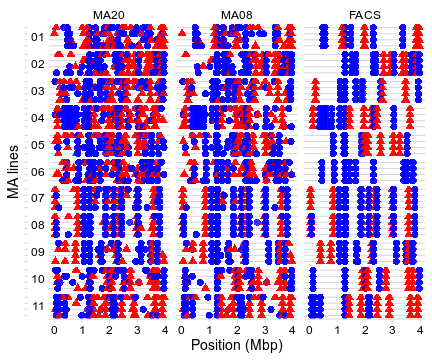

RObject{VecSxp}


In [13]:
R"""
shift_positions <- function(pos, shift, genome_size){
	pos <- pos + shift
  pos <- ifelse(pos < 1, pos + genome_size, pos)
  pos <- ifelse(pos > genome_size, pos - genome_size, pos)
  return(pos)
}

generations <- c("FACS", "MA08", "MA20")

is_in_mds42_df %>%
separate(Line, c("Parent", "Subline"), sep = "-", remove = FALSE) %>%
# remove first letter
mutate(Parent = str_sub(Parent, 2)) %>%
mutate(Subline = ifelse(is.na(Subline), "1", Subline)) %>%
#mutate(medianpos = shift_positions(medianpos, -3359187, 3976195)) %>%
rename("Gen_id" = Gen) %>%
# reverse the levels
mutate(Gen = map_chr(Gen_id, ~generations[.x])) %>%
mutate(Gen = as.factor(Gen)) %>%
mutate(Gen = fct_relevel(Gen, rev(levels(Gen)))) %>%
ggplot(aes(x = pos/1e6, y = Subline, color = IS_strand, shape = IS_strand)) +
geom_point(size = 3, alpha = 0.8) +
scale_color_manual(values = c("blue", "red")) +
theme_minimal_hgrid() + 
facet_grid(Parent~Gen, switch = "y") +
theme(axis.text.y=element_blank(), legend.position = "none",
  panel.spacing.y = unit(.1, "lines"), strip.text.y.left = element_text(angle=0)) +
labs(x = "Position (Mbp)", y = "MA lines") 
"""

In [14]:
# Check whether there are matched ISs in previous generations
R"""
is_in_mds42.df <- is_in_mds42_df %>%
	separate(Line, c("Parent", "Subline"), sep = "-", remove = FALSE) %>%
	# remove first letter
	mutate(Parent = str_sub(Parent, 2)) %>%
	mutate(Subline = as.integer(Subline)) %>%
	#mutate(Subline = ifelse(is.na(Subline), "1", Subline)) %>%
	rename("Gen_id" = Gen) %>%
	mutate(Gen = map_chr(Gen_id, ~generations[.x])) %>%
	filter(genome == "Query")

is_in_df.prev <- is_in_mds42.df %>%
filter(Gen_id < length(generations)) %>%
mutate(Gen = map_chr(Gen_id, ~generations[.x+1]))

is_in_df.facs <- is_in_mds42.df %>% filter(Gen_id == 1)
is_in_df.facs <- is_in_df.facs %>% slice(rep(1:n(), 3)) %>% mutate(Gen_id = rep(c(1,2,3), each = n()/3)) %>%
mutate(Gen = map_chr(Gen_id, ~generations[.x])) 

# detect the matched ISs in the previous sequencing round  -> matched_row.prev
is_in_mds42.df.prevgen <- is_in_mds42.df %>%
	mutate(matched_row.prev = pmap(list(Parent, Subline, Gen, pos),
	function(Parent, Subline, Gen, pos){
		matched_row <- unname(which(is_in_df.prev$Parent == Parent & 
		is_in_df.prev$Subline == Subline & 
		is_in_df.prev$Gen == Gen &
		abs(is_in_df.prev$pos - pos) <= 20))
		return(matched_row[1])
	}) %>% unlist() %>% as.integer()) 

# detect the matched ISs in the FACS sequencing round -> matched_row.facs
is_in_mds42.df.prevgen <- is_in_mds42.df.prevgen %>%
		mutate(matched_row.facs = pmap(list(Parent, Subline, Gen, pos),
		function(Parent, Subline, Gen, pos){
			matched_row <- unname(which(is_in_df.facs$Parent == Parent & 
			is_in_df.facs$Subline == Subline & 
			is_in_df.facs$Gen == Gen &
			abs(is_in_df.facs$pos - pos) <= 20))
			return(matched_row[1])
		}) %>% unlist() %>% as.integer())
is_in_mds42.df.prevgen %>% select(Parent, Gen, Subline, pos, matched_row.prev, matched_row.facs) %>% head %>% print
is_in_mds42.df.prevgen %>% select(Parent, Gen, Subline, pos, matched_row.prev, matched_row.facs) %>% tail %>% print

#write_csv(is_in_mds42.df.prevgen, file.path("../misc", "is_in_mds42.df.prevgen.csv"))
write_csv(is_in_mds42.df.prevgen, file.path(base_dir, "export", "classify_IS_events_MDS", "is_in_mds42.df.prevgen.csv"))
""";

# A tibble: 6 × 6
  Parent Gen   Subline     pos matched_row.prev matched_row.facs
  <chr>  <chr>   <int>   <dbl>            <int>            <int>
1 01     FACS        1  476936               NA                1
2 01     FACS        1  476923               NA                1
3 01     FACS        1  554076               NA                3
4 01     FACS        1  554063               NA                3
5 01     FACS        1 1181600               NA                5
6 01     FACS        1 1488330               NA                6
# A tibble: 6 × 6
  Parent Gen   Subline     pos matched_row.prev matched_row.facs
  <chr>  <chr>   <int>   <dbl>            <int>            <int>
1 11     MA20        4  162182             2656             3112
2 11     MA20        4 3727985               NA               NA
3 11     MA20        4 3890676             2693             3131
4 11     MA20        4 3898750             2694             3132
5 11     MA20        4 3954602               NA       

## Hotspot analysis
Find hotspots of insertions by sliding window.

I included 4-1 but the HDRs in 4-1 would not affect this result as the insert locus is based on the coordinates of MDS42.
Here, the analysis is only about insertions and even if there are insertions in the 4-1 reflecting deviations, that is nevertheless a real insertion.

# A tibble: 3 × 2
  Type    Count
  <chr>   <int>
1 Complex   622
2 Simple    740
3 Total    1362


┌ Warning: RCall.jl: `summarise()` has grouped output by 'Line', 'Gen'. You can override using the
│ `.groups` argument.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning: Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
│ ℹ Please use `linewidth` instead.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


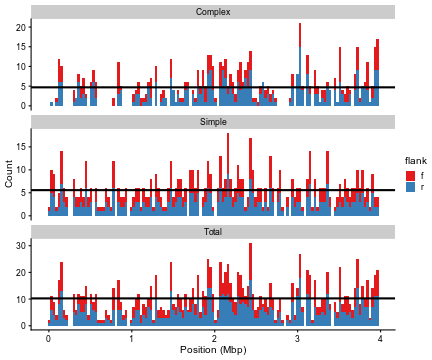

RObject{VecSxp}


In [15]:
# First breifly get the picture by plotting the histogram
R"""
scale_x_ = 1/1e6
ref_genome_size = 3980425
bin_width_ = 30000
total_is_cnt.df = is_in_mds42.df.prevgen %>%
	filter(Gen != "FACS") %>%
	filter(is.na(matched_row.prev))  %>%
	summarise(Total = n(), Simple = sum(sv == "simple_insertion"))%>%
	mutate(Complex = Total - Simple) %>%
	mutate(Total.2 = Total) %>%
	pivot_longer(-Total.2, names_to = "Type", values_to = "Count") %>%
	mutate(Count.exp = Count * bin_width_/ref_genome_size)

## Note that this sum has double counts of two ends, especially after simple insertions.
print(total_is_cnt.df %>% group_by(Type) %>% summarise(Count = sum(Count)))

## Get only new insertions
tmp.df <- is_in_mds42.df.prevgen %>%
filter(Gen != "FACS") %>%
filter(is.na(matched_row.prev)) %>%
mutate(Type = ifelse(sv == "simple_insertion", "Simple", "Complex"))

is_in_mds42.df.prevgen.clean <- tmp.df

new_is_pos_in_mds42_df <- is_in_mds42.df.prevgen.clean %>% group_by(Line, Gen, insert_id) %>%
	summarise(pos = mean(pos), Type = ifelse(all(Type == "Simple"), "Simple", "Complex"))

tmp.df %>% rbind(tmp.df %>% mutate(Type = "Total")) %>%
ggplot(aes(x = pos * scale_x_, fill = flank)) +
geom_histogram(binwidth = bin_width_ * scale_x_, position = "stack") +
geom_hline(data = total_is_cnt.df, aes(yintercept = Count.exp), size = 1) +
scale_fill_brewer(palette = "Set1") +
facet_wrap(~Type, scales = "free_y", ncol = 1) +
labs(x = "Position (Mbp)", y = "Count") +
ylim(0, NA) +
theme_half_open(10)
"""

### Sliding window analysis

In [16]:
# Sliding window function
function sliding_window_analysis(pos::Vector{Int}, genome_size, bin_size::Int = 100000, step_size::Int = 1000, 
                                alpha::Float64 = 0.05, binom_test::Bool = true)

    mutations = DataFrame(position=pos)

    genome_start = 1
    genome_end = genome_size

    # Handle circular genome
    mutations_extended = vcat(mutations, 
                              DataFrame(position=mutations.position .+ genome_end), 
                              DataFrame(position=mutations.position .- genome_end))
    #print(mutations_extended[1 .< mutations_extended.position .< 1e5, :])

    # Define sliding windows
    starts = collect(genome_start:step_size:genome_size)
    ends = starts .+ bin_size .- 1
	windows = DataFrame("start"=>starts, "end"=>ends)

    # Count mutations in each window
    windows.mutation_count = [sum((mutations_extended.position .>= s) .& (mutations_extended.position .<= e)) 
                              for (s, e) in zip(windows.start, windows.end)]

    # Mutations per bp
    windows.mutations_per_bp = windows.mutation_count ./ bin_size

    mutation_rate = size(mutations, 1) / (genome_size - genome_start + 1)

    if binom_test
        # Perform binomial tests
        windows.p_value = [pvalue(BinomialTest(n, bin_size, mutation_rate)) for n in windows.mutation_count]
        windows.adjusted_p_value = adjust(windows.p_value, BenjaminiHochberg())
        windows.significant = windows.adjusted_p_value .< alpha
        windows.test_side = ifelse.(windows.mutation_count .> bin_size * mutation_rate, "high", "low")

        # Print top significant results
        #println(first(sort(windows[windows.significant, :], :adjusted_p_value), min(5, sum(windows.significant))))
    end

    return (windows, mutation_rate)
end

sliding_window_analysis (generic function with 5 methods)

In [17]:
@rget new_is_pos_in_mds42_df 
first(new_is_pos_in_mds42_df, 2)

Row,Line,Gen,insert_id,pos,Type
,String,String,Float64,Float64,String
1,L01-1,MA08,2.0,549440.0,Complex
2,L01-1,MA08,3.0,554375.0,Complex


In [18]:
@rget ref_genome_size
windows_total, total_ins_rate = sliding_window_analysis(round.(Int, new_is_pos_in_mds42_df.pos),
	ref_genome_size);
print("Rate: $(total_ins_rate), Significant windows: $(sum(windows_total.significant))")
first(windows_total, 2)

Rate: 0.00023138232726404844, Significant windows: 1058

Row,start,end,mutation_count,mutations_per_bp,p_value,adjusted_p_value,significant,test_side
,Float64,Float64,Int64,Float64,Float64,Float64,Bool,String
1,1.0,100000.0,14,0.00014,0.0584491,0.154027,false,low
2,1001.0,101000.0,14,0.00014,0.0584491,0.154027,false,low


In [19]:
# aggregate windows with same significance to simplify the plot
function window_to_window_cnt(windows::DataFrame, ref_genome_size::Int)
	windows.start = Int.(windows.start)
	windows.end = Int.(windows.end)
	window_cnt = DataFrame(Locus = 1:Int(maximum(windows.end)), high_nonsig=0, low_nonsig=0, high_sig=0, low_sig=0)

	for i in 1:nrow(windows)
		curr_symbol = :abc
		if windows[i,:significant]
			if windows[i,:test_side ] == "high"
				curr_symbol = :high_sig
			else
				curr_symbol = :low_sig
			end
		else
			if windows[i,:test_side ] == "high"
				curr_symbol = :high_nonsig
			else
				curr_symbol = :low_nonsig
			end
		end
		window_cnt[windows[i,:start]:windows[i,:end], curr_symbol] .+= 1
	end

	# merge bins that are over the genome size to the beginning
	over_range_num = maximum(window_cnt.Locus) - ref_genome_size
	value_symbols = [:high_nonsig, :low_nonsig, :high_sig, :low_sig]
	window_cnt[1:over_range_num, value_symbols] .+= window_cnt[(ref_genome_size+1):maximum(window_cnt.Locus), value_symbols]
	tmpdf = window_cnt[2:(ref_genome_size+1), :] .- window_cnt[1:ref_genome_size, :]
	window_cnt = window_cnt[1:ref_genome_size, :]
	window_cnt[!, :groups] = cumsum(abs.(tmpdf.high_sig) .> 0 .|| abs.(tmpdf.low_sig) .> 0)

	window_cnt = @chain window_cnt  begin
		groupby(:groups) 
		@combine begin
			:start = minimum(:Locus)
			:end = maximum(:Locus)
			:high_sig = first(:high_sig)
			:low_sig = first(:low_sig)
		end
	end

	return window_cnt
end

window_cnt_total = window_to_window_cnt(windows_total, Int(ref_genome_size))

@rput window_cnt_total
println("Genome size: $(ref_genome_size), Total windows: $(nrow(windows_total)), Total count windows: $(nrow(window_cnt_total))")
println("High sig counts")
R"window_cnt_total %>% pull(high_sig) %>% summary %>% print"
println("Low sig counts")
R"window_cnt_total %>% pull(low_sig) %>% summary %>% print";

Genome size: 3.980425e6, Total windows: 3981, Total count windows: 1676
High sig counts
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    0.00    0.00   17.97   32.00  100.00 
Low sig counts
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    0.00    5.00   23.25   45.00  100.00 


### The same analysis for simple insertion

In [20]:
windows_simple, simple_ins_rate = sliding_window_analysis(round.(Int,
	new_is_pos_in_mds42_df[new_is_pos_in_mds42_df.Type .== "Simple", :pos]),
	ref_genome_size);

window_cnt_simple = window_to_window_cnt(windows_simple, Int(ref_genome_size))

@rput window_cnt_simple
println("Genome size: $(ref_genome_size), Total windows: $(nrow(windows_simple)), Total count windows: $(nrow(window_cnt_simple))")
println("High sig counts")
R"window_cnt_simple %>% pull(high_sig) %>% summary %>% print"
println("Low sig counts")
R"window_cnt_simple %>% pull(low_sig) %>% summary %>% print";

Genome size: 3.980425e6, Total windows: 3981, Total count windows: 1
High sig counts
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0       0       0       0       0       0 
Low sig counts
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0       0       0       0       0       0 


#### STAT: Minimal P value of the sliding window analysis with BH correction

In [21]:
println("Total: Minimal p-value: $(minimum(windows_total.p_value)), Minimal adjusted p-value: $(minimum(windows_total.adjusted_p_value))")
println("Simple: Minimal p-value: $(minimum(windows_simple.p_value)), Minimal adjusted p-value: $(minimum(windows_simple.adjusted_p_value))")

Total: Minimal p-value: 1.0553631445164706e-8, Minimal adjusted p-value: 1.3037644876444378e-5
Simple: Minimal p-value: 0.0024609798875002966, Minimal adjusted p-value: 0.6172845311980694


## Sliding window of insertion and essentiality
### Before revision
Essential gene rich regions might have low IS insertions. Here, I test this.

In [22]:
R"""
gene_list <- read_csv("../misc/gene_df_ess_mds42_based_on_PEC.csv")
ref_genome_size = 3980425

essential_locus_plot_df <-
gene_list %>%
filter(Essential == TRUE | Essential_PEC == TRUE) %>%
mutate(fill = "C", alpha =1) %>%
mutate(start= start_ori_shift, end = end_ori_shift) %>%
select(start, end, fill, alpha, Essential, Essential_PEC)

essential_locus_plot_df <- rbind(
	essential_locus_plot_df %>% mutate(type = "G08"), 
	essential_locus_plot_df %>% mutate(type = "G20")) %>%
	rbind(data.frame(start = 0, end = ref_genome_size, fill = "A", alpha=0.3, type = c("G08", "G20"), Essential = FALSE, Essential_PEC = FALSE)) 
essential_locus_plot_df %>% head(3)
"""

┌ Warning: RCall.jl: Rows: 3754 Columns: 15
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr (3): gene, bnumber, ECK_id
│ dbl (8): start, end, strand, length, Insertion Index Score, Log Likelihood R...
│ lgl (4): Essential, Non-essential, Unclear, Essential_PEC
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 3 × 7
   start    end fill  alpha Essential Essential_PEC type 
   <dbl>  <dbl> <chr> <dbl> <lgl>     <lgl>         <chr>
1 636879 637142 C         1 TRUE      FALSE         G08  
2 637471 638412 C         1 TRUE      TRUE          G08  
3 638455 641271 C         1 TRUE      TRUE          G08  


In [23]:
@rget gene_list
first(gene_list[(x-> ifelse(ismissing(x), false,x)).(gene_list.Essential_PEC),:], 10)

windows_total_ess = copy(windows_total)
windows_total_ess[!, :ess_cnt] .= 0
for (i, row) in enumerate(eachrow(windows_total_ess))
	tmp_ = @chain gene_list begin
		@subset(:Essential_PEC .== true)
		@subset((row.start .<= :start_ori_shift .<= row.end) .| (row.start .<= :end_ori_shift .<= row.end) .| (row.start - ref_genome_size .<= :start_ori_shift .<= row.end - ref_genome_size) .| (row.start - ref_genome_size .<= :end_ori_shift .<= row.end - ref_genome_size))
	end
	windows_total_ess[i, :ess_cnt] = nrow(tmp_)
	if i == 1#nrow(windows_total_ess)
		print(tmp_)
	end
end
@rput windows_total_ess
size(windows_total_ess) |> println
first(windows_total_ess, 3)

7×15 DataFrame
 Row │ gene    start      end        strand   length   bnumber  ECK_id   Insertion Index Score  Log Likelihood Ratio  Essential  Non-essential  Unclear  start_ori_shift  end_ori_shift  Essential_PEC 
     │ String  Float64    Float64    Float64  Float64  String   String   Float64?               Float64?              Bool?      Bool?          Bool?    Float64          Float64        Bool?         
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ trpT    3.3804e6   3.38048e6      1.0     76.0  b3761    ECK3755       missing                  missing          missing        missing  missing          21214.0        21289.0           true
   2 │ rho     3.39986e6  3.40112e6      1.0   1260.0  b3783    ECK3775             0.00476191             -20.8434        true          false    false          40674.0        41933.0   

Row,start,end,mutation_count,mutations_per_bp,p_value,adjusted_p_value,significant,test_side,ess_cnt
,Int64,Int64,Int64,Float64,Float64,Float64,Bool,String,Int64
1,1,100000,14,0.00014,0.0584491,0.154027,false,low,7
2,1001,101000,14,0.00014,0.0584491,0.154027,false,low,7
3,2001,102000,14,0.00014,0.0584491,0.154027,false,low,7


In [24]:
R"""
windows_total_ess.nooverlap <- windows_total_ess %>% filter(end %% 100000 == 0) 
lm.res <- lm(
	windows_total_ess.nooverlap%>%pull(mutation_count) ~ windows_total_ess.nooverlap%>%pull(ess_cnt))
print(length(windows_total_ess.nooverlap%>%pull(mutation_count)))
print(summary(lm.res))
sqrt(summary(lm.res)$r.squared)
"""

[1] 40

Call:
lm(formula = windows_total_ess.nooverlap %>% pull(mutation_count) ~ 
    windows_total_ess.nooverlap %>% pull(ess_cnt))

Residuals:
     Min       1Q   Median       3Q      Max 
-18.5243  -7.1566   0.6045   6.6448  20.9907 

Coefficients:
                                              Estimate Std. Error t value
(Intercept)                                    26.1640     2.5216  10.376
windows_total_ess.nooverlap %>% pull(ess_cnt)  -0.4044     0.2425  -1.668
                                              Pr(>|t|)    
(Intercept)                                   1.21e-12 ***
windows_total_ess.nooverlap %>% pull(ess_cnt)    0.104    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 10.72 on 38 degrees of freedom
Multiple R-squared:  0.06822,	Adjusted R-squared:  0.0437 
F-statistic: 2.782 on 1 and 38 DF,  p-value: 0.1036



RObject{RealSxp}
[1] 0.2611823


### lm (ins vs ess)
regression between essentiality and IS insertion in windows

## FIG: ess gene vs Ins

┌ Warning: RCall.jl: `geom_smooth()` using formula = 'y ~ x'
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: `geom_smooth()` using formula = 'y ~ x'
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: `geom_smooth()` using formula = 'y ~ x'
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


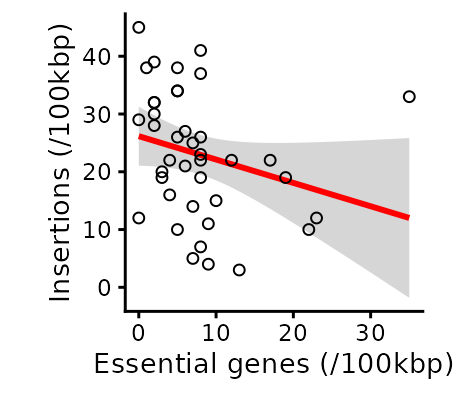

In [25]:
figure_name = file_prefix * "ess-cnt_vs_mutation_cnt_lm"
@rput figure_name
R"""
p <- windows_total_ess.nooverlap %>%
ggplot(aes(x = ess_cnt, y = mutation_count)) +
geom_smooth(method = "lm", color = "red") +
geom_point(shape = 1)+
theme_half_open(10) +
theme(aspect.ratio = 1) +
labs(x = "Essential genes (/100kbp)", y = "Insertions (/100kbp)")

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=60, height=50, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=60, height=50, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=60, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

# Deletion analysis
Use data of ASM20.
Previous analysis using asm5 option of minimap2 contained false positives of deletions.
I changed the option to asm20 to allow more mismatches. This is the result.

In [26]:
min_del_threshold = 100
@rput min_del_threshold
R"""
depth_interval_df <- read_csv(file.path(base_dir, "export", "classify_IS_events_MDS", "depth_interval.asm20.csv"))

generations2 <- c("MDS42_IS1", "FACS", "G08", "G20")
print("SVs with length < min_del_threshold")
print(depth_interval_df %>% filter(length < min_del_threshold) %>% distinct(line, length, .keep_all = TRUE)%>% data.frame %>% select(-start, -end) %>% head)
depth_interval_df <- depth_interval_df %>% 
	filter(length >= min_del_threshold) %>%
	mutate(gen_id = as.integer(gen_id)) %>%
	mutate(Gen = map_chr(gen_id, ~generations2[.x +1])) %>%
	separate(line, c("Parent", "Subline"), sep = "-", remove = FALSE) %>%
	mutate(Subline = as.integer(Subline))
depth_interval_df %>% head
"""

[1] "SVs with length < min_del_threshold"
  group depth length start_fix end_fix is_start is_end  line gen_id
1     6     0     82   3870531 3870612       -1     -1 L01-1      1
2     6     0     82   3870531 3870612       -1     -1 L01-2      1
3    10     0     93   2296071 2296163       15     16 L01-2      2
4    13     0     91   2296071 2296161       19     20 L01-2      3
5     6     0     82   3870531 3870612       -1     -1 L01-3      1
6     6     0     82   3870531 3870612       -1     -1 L01-4      1


┌ Warning: RCall.jl: Rows: 2219 Columns: 11
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr  (1): line
│ dbl (10): group, start, end, depth, length, start_fix, end_fix, is_start, is...
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 6 × 14
  group   start     end depth  length start_fix end_fix is_start is_end line 
  <dbl>   <dbl>   <dbl> <dbl>   <dbl>     <dbl>   <dbl>    <dbl>  <dbl> <chr>
1     1       1 1485236     1 1485236         1 1488328       -1      6 L01-1
2     2 1485237 1485904     0     668   1488329 1488996        6      7 L01-1
3     3 1485905 1968467     1  482563   1488997 1971559        7      8 L01-1
4     4 1968468 1977701     0    9234   1971560 1980793        8      9 L01-1
5     5 1977702 3867438     1 1889737   1980794 3870530        9     -1 L01-1
6     7 3867521 3939927     1   72407   3870613 3943019       -1     13 L01-1
# ℹ 4 more variables: Parent <chr>, Subline <int>, gen_id <int>, Gen <chr>


## STAT: Total deleted region

In [27]:
@rget depth_interval_df
ref_genome_size = 3980425

# get the cumulative deleted regions based on the depth_intervals
function get_deletion_intervals(depth_interval_df, ref_genome_size, type_str)

	non_deleted_seq = ones(Int, ref_genome_size)

	for row in eachrow(depth_interval_df)
		if row.depth == 0
			non_deleted_seq[Int(row.start_fix):Int(row.end_fix)] .= 0
		end
	end
	total_remain = sum(non_deleted_seq)
	total_del = ref_genome_size - total_remain
	#total_del, total_remain, total_del / ref_genome_size
	println("TYPE:", type_str, " DEL: ", total_del, " REMAIN: ", total_remain, " DEL/REF: ", total_del / ref_genome_size)

	# create_intervals
	deletion_df_ = DataFrame(x=1:ref_genome_size, y = ifelse.(non_deleted_seq .== [1,non_deleted_seq[1:(ref_genome_size-1)]...], 0, 1), z = non_deleted_seq)
	deletion_df_.y = cumsum(deletion_df_.y)
	deletion_df_ = deletion_df_ |> x -> groupby(x, [:y]) |> x-> combine(x, :x => minimum => :start, :x => maximum => :end, nrow => :length, :z => first => :remain)
	deletion_df_[!, :type] .= type_str
	return deletion_df_
end

depth_df = DataFrame()
#depth_interval_df = depth_interval_df[.!((depth_interval_df.line .== "L11-4") .& (depth_interval_df.gen_id .== 2)),:]
depth_df= vcat(depth_df, get_deletion_intervals(depth_interval_df, ref_genome_size, "TOTAL"))
depth_df= vcat(depth_df, get_deletion_intervals(depth_interval_df[depth_interval_df.Gen .!= "FACS",:], ref_genome_size, "MA"))
depth_df = vcat(depth_df, get_deletion_intervals(depth_interval_df[depth_interval_df.Gen .== "G08",:], ref_genome_size, "G08"))
depth_df = vcat(depth_df, get_deletion_intervals(depth_interval_df[depth_interval_df.Gen .== "G20",:], ref_genome_size, "G20"))
depth_df |> x -> first(x, 10)

TYPE:TOTAL DEL: 1334029 REMAIN: 2646396 DEL/REF: 0.33514737747853557
TYPE:MA DEL: 1334029 REMAIN: 2646396 DEL/REF: 0.33514737747853557
TYPE:G08 DEL: 875301 REMAIN: 3105124 DEL/REF: 0.21990139243924958
TYPE:G20 DEL: 1327167 REMAIN: 2653258 DEL/REF: 0.33342344096421866


Row,y,start,end,length,remain,type
,Int64,Int64,Int64,Int64,Int64,String
1,0,1,76764,76764,1,TOTAL
2,1,76765,90733,13969,0,TOTAL
3,2,90734,105808,15075,1,TOTAL
4,3,105809,106019,211,0,TOTAL
5,4,106020,116145,10126,1,TOTAL
6,5,116146,120897,4752,0,TOTAL
7,6,120898,137383,16486,1,TOTAL
8,7,137384,162380,24997,0,TOTAL
9,8,162381,296547,134167,1,TOTAL


### DAT: total_deletion_intervals.csv

In [28]:
#depth_df
# change y->id, 
comment_header = "# type: `TOTAL` (All deletions), `MA` (Deletions during MA, this can be larger than the some of the latter two as some deletions in G08 are lost in G20 due to high heterogeneity), `G08` (Deletion up to the 8 th passage), `G20`: (Deletion up to the 20 th passage )"
open(joinpath(data_export_dir, file_prefix * "total_deletion_intervals.csv"), "w") do io
	write(io, comment_header * "\n")
	CSV.write(io, depth_df |> df -> rename(df, :y => :id), append=true, writeheader=true)
end

IOStream(<file ./exp/multiple_runs14/data/ins_del_analysis/20250204_total_deletion_intervals.csv>)

In [29]:
# count how many times sequences were deleted
function get_deletion_intervals(depth_interval_df, ref_genome_size, type_str)

	non_deleted_seq = ones(Int, ref_genome_size)

	for row in eachrow(depth_interval_df)
		if row.depth == 0
			non_deleted_seq[Int(row.start_fix):Int(row.end_fix)] .= 0
		end
	end
	total_remain = sum(non_deleted_seq)
	total_del = ref_genome_size - total_remain
	#total_del, total_remain, total_del / ref_genome_size
	println("TYPE:", type_str, " DEL: ", total_del, " REMAIN: ", total_remain, " DEL/REF: ", total_del / ref_genome_size)

	# create_intervals
	deletion_df_ = DataFrame(x=1:ref_genome_size, y = ifelse.(non_deleted_seq .== [1,non_deleted_seq[1:(ref_genome_size-1)]...], 0, 1), z = non_deleted_seq)
	deletion_df_.y = cumsum(deletion_df_.y)
	deletion_df_ = deletion_df_ |> x -> groupby(x, [:y]) |> x-> combine(x, :x => minimum => :start, :x => maximum => :end, nrow => :length, :z => first => :remain)
	deletion_df_[!, :type] .= type_str
	return deletion_df_
end

get_deletion_intervals (generic function with 1 method)

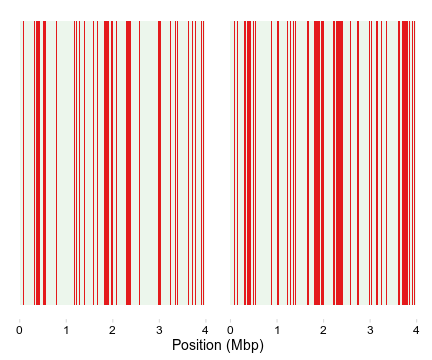

RObject{VecSxp}


In [30]:
@rput depth_df
R"""
library(RColorBrewer)
cols_ <- brewer.pal(3, "Set1")[c(1,3,2)]

p2.asm20 <- depth_df %>% 
filter(type %in% c("G08", "G20")) %>%
mutate(fill = ifelse(remain == 0, "A", "C")) %>%
mutate(alpha = ifelse(remain == 1, 0.3, 1)) %>%
ggplot() + 
geom_rect(aes(xmin = start/1e6, xmax = end/1e6, ymin = 0, ymax = 1, fill = fill, alpha = alpha)) +
#scale_fill_brewer(palette = "Set1", values = c(1,3)) +
scale_fill_manual(values = cols_) +
facet_grid(~type) + 
theme_minimal_hgrid() +
labs(x = "Position (Mbp)") + 
theme(axis.text.y=element_blank(), legend.position = "none",
strip.text.y.left = element_text(angle=0), axis.ticks.y = element_blank(),
panel.grid.major.y = element_blank(), panel.grid.minor.y = element_blank(),
axis.line=element_blank(), strip.background = element_blank(), strip.text.x = element_blank())
"""

### Get pos of ess. genes

In [31]:
R"""
gene_list <- read_csv(file.path(misc_dir, "gene_df_ess_mds42_based_on_PEC.csv"))
ref_genome_size = 3980425

essential_locus_plot_df <-
gene_list %>%
filter(Essential == TRUE | Essential_PEC == TRUE) %>%
mutate(fill = "C", alpha =1) %>%
mutate(start= start_ori_shift, end = end_ori_shift) %>%
select(start, end, fill, alpha, Essential, Essential_PEC)

essential_locus_plot_df <- rbind(
	essential_locus_plot_df %>% mutate(type = "G08"), 
	essential_locus_plot_df %>% mutate(type = "G20")) %>%
rbind(data.frame(start = 0, end = ref_genome_size, fill = "A", alpha=0.3, type = c("G08", "G20"), Essential = FALSE, Essential_PEC = FALSE)) 
"""

┌ Warning: RCall.jl: Rows: 3754 Columns: 15
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr (3): gene, bnumber, ECK_id
│ dbl (8): start, end, strand, length, Insertion Index Score, Log Likelihood R...
│ lgl (4): Essential, Non-essential, Unclear, Essential_PEC
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 744 × 7
    start    end fill  alpha Essential Essential_PEC type 
    <dbl>  <dbl> <chr> <dbl> <lgl>     <lgl>         <chr>
 1 636879 637142 C         1 TRUE      FALSE         G08  
 2 637471 638412 C         1 TRUE      TRUE          G08  
 3 638455 641271 C         1 TRUE      TRUE          G08  
 4 641271 641765 C         1 TRUE      TRUE          G08  
 5 642341 643291 C         1 TRUE      TRUE          G08  
 6 644438 645259 C         1 TRUE      TRUE          G08  
 7 665887 666366 C         1 TRUE      TRUE          G08  
 8 670819 673173 C         1 TRUE      TRUE          G08  
 9 707096 707461 C         1 TRUE      TRUE          G08  
10 707477 709243 C         1 TRUE      TRUE          G08  
# ℹ 734 more rows


In [32]:
R"""
essential_locus_plot_df %>% filter(!is.na(Essential)) %>% pull(Essential) %>% sum %>% (function(x) x/2) %>% print
essential_locus_plot_df %>% pull(Essential_PEC) %>% sum %>% (function(x) x/2) %>% print
"""

[1] 336
[1] 302


RObject{RealSxp}
[1] 302


### Get all deleted genes

In [33]:
@rget gene_list;

In [34]:
int_ = depth_interval_df[2,:]
del_genes_ = gene_list[(gene_list.end .> int_.start_fix) .& (gene_list.start .< int_.end_fix),:]

Row,gene,start,end,strand,length,bnumber,ECK_id,Insertion Index Score,Log Likelihood Ratio,Essential,Non-essential,Unclear,start_ori_shift,end_ori_shift,Essential_PEC
,String,Float64,Float64,Float64,Float64,String,String,Float64?,Float64?,Bool?,Bool?,Bool?,Float64,Float64,Bool?
1,thrS,1.48646e6,1.48838e6,-1.0,1929.0,b1719,ECK1717,0.00207361,-26.502,true,false,false,2.10769e6,2.10962e6,true
2,arpB,1.48891e6,1.48938e6,1.0,474.0,b1720,ECK1718,0.174027,12.9929,false,true,false,2.11015e6,2.11062e6,false
3,arpB,1.48895e6,1.49085e6,1.0,1900.0,b4494,ECK1718,0.174027,12.9929,false,true,false,2.11019e6,2.11209e6,false


In [35]:
deleted_genes_df = DataFrame()
for int_ in eachrow(depth_interval_df[depth_interval_df.depth .== 0,:])
	del_genes_ = gene_list[(gene_list.end_ori_shift .> int_.start_fix) .& (gene_list.start_ori_shift .< int_.end_fix),:]
	new_dat_ = crossjoin(DataFrame(int_), select(del_genes_, Not([:start, :end, :length])), makeunique=true)
	deleted_genes_df = vcat(deleted_genes_df, new_dat_)
end
first(deleted_genes_df, 10)

Row,group,start,end,depth,length,start_fix,end_fix,is_start,is_end,line,Parent,Subline,gen_id,Gen,gene,strand,bnumber,ECK_id,Insertion Index Score,Log Likelihood Ratio,Essential,Non-essential,Unclear,start_ori_shift,end_ori_shift,Essential_PEC
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,String,Int64,Int64,String,String,Float64,String,String,Float64?,Float64?,Bool?,Bool?,Bool?,Float64,Float64,Bool?
1,2.0,1.48524e6,1.4859e6,0.0,668.0,1.48833e6,1.489e6,6.0,7.0,L01-1,L01,1,1,FACS,ycbS,1.0,b0940,ECK0931,0.251057,19.9825,false,true,false,1.48742e6,1.49002e6,false
2,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,dmsD,1.0,b1591,ECK1586,0.104065,5.445,false,true,false,1.97156e6,1.97217e6,false
3,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,clcB,1.0,b1592,ECK1587,0.122514,7.61804,false,true,false,1.97237e6,1.97362e6,false
4,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,ynfK,-1.0,b1593,ECK1588,0.130747,8.53625,false,true,false,1.97358e6,1.97427e6,false
5,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,dgsA,-1.0,b1594,ECK1589,0.11466,6.71431,false,true,false,1.9744e6,1.97562e6,false
6,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,ynfL,-1.0,b1595,ECK1590,0.136465,9.15831,false,true,false,1.97575e6,1.97664e6,false
7,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,ynfM,1.0,b1596,ECK1591,0.167464,12.3496,false,true,false,1.97675e6,1.978e6,false
8,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,asr,1.0,b1597,ECK1592,0.200647,15.5122,false,true,false,1.97843e6,1.97874e6,false
9,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,ydgD,1.0,b1598,ECK1593,0.149635,10.5483,false,true,false,1.97901e6,1.97983e6,false


In [36]:
deleted_genes_df[deleted_genes_df.gen_id .== 1,:] |> x -> first(x, 5)

Row,group,start,end,depth,length,start_fix,end_fix,is_start,is_end,line,Parent,Subline,gen_id,Gen,gene,strand,bnumber,ECK_id,Insertion Index Score,Log Likelihood Ratio,Essential,Non-essential,Unclear,start_ori_shift,end_ori_shift,Essential_PEC
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,String,Int64,Int64,String,String,Float64,String,String,Float64?,Float64?,Bool?,Bool?,Bool?,Float64,Float64,Bool?
1,2.0,1.48524e6,1.4859e6,0.0,668.0,1.48833e6,1.489e6,6.0,7.0,L01-1,L01,1,1,FACS,ycbS,1.0,b0940,ECK0931,0.251057,19.9825,false,true,false,1.48742e6,1.49002e6,false
2,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,dmsD,1.0,b1591,ECK1586,0.104065,5.445,false,true,false,1.97156e6,1.97217e6,false
3,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,clcB,1.0,b1592,ECK1587,0.122514,7.61804,false,true,false,1.97237e6,1.97362e6,false
4,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,ynfK,-1.0,b1593,ECK1588,0.130747,8.53625,false,true,false,1.97358e6,1.97427e6,false
5,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,dgsA,-1.0,b1594,ECK1589,0.11466,6.71431,false,true,false,1.9744e6,1.97562e6,false


In [37]:
#deleted_genes_df[(x -> startswith(x, "rec")).(deleted_genes_df.gene) .& ,:]
@chain deleted_genes_df begin
	@rsubset :gene .== "hns"
end

Row,group,start,end,depth,length,start_fix,end_fix,is_start,is_end,line,Parent,Subline,gen_id,Gen,gene,strand,bnumber,ECK_id,Insertion Index Score,Log Likelihood Ratio,Essential,Non-essential,Unclear,start_ori_shift,end_ori_shift,Essential_PEC
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,String,Int64,Int64,String,String,Float64,String,String,Float64?,Float64?,Bool?,Bool?,Bool?,Float64,Float64,Bool?


In [38]:
#deleted_genes_df[(x -> startswith(x, "rec")).(deleted_genes_df.gene) .& ,:]
@chain deleted_genes_df begin
	@rsubset (x -> startswith(x, "rec")).(:gene) .& (:gene .!= "recA")
end

Row,group,start,end,depth,length,start_fix,end_fix,is_start,is_end,line,Parent,Subline,gen_id,Gen,gene,strand,bnumber,ECK_id,Insertion Index Score,Log Likelihood Ratio,Essential,Non-essential,Unclear,start_ori_shift,end_ori_shift,Essential_PEC
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,String,Int64,Int64,String,String,Float64,String,String,Float64?,Float64?,Bool?,Bool?,Bool?,Float64,Float64,Bool?
1,2.0,76765.0,90733.0,0.0,13969.0,76765.0,90733.0,1.0,2.0,L06-2,L06,2,2,G08,recQ,1.0,b3822,ECK3816,0.253005,20.1491,false,true,false,80121.0,81950.0,false
2,2.0,76765.0,90733.0,0.0,13969.0,76765.0,90733.0,1.0,2.0,L06-2,L06,2,3,G20,recQ,1.0,b3822,ECK3816,0.253005,20.1491,false,true,false,80121.0,81950.0,false


## Deleted gene analysis

In [39]:
rec_genes = ["endA", "exoX", "hsdR", "mcrB", "mcrC", "nfi", "recB", "recC", "recD", "recE", "recJ", "rnt", "sbcB", "sbcC", "sbcD", "tatD", "uvrB", "uvrC", "xseA", "xseB", "ybhP", "fimB", "fimE", "fis", "ihfA", "ihfB", "pepA", "radA", "rarA", "recA", "recB", "recC", "recD", "recF", "recN", "recO", "recQ", "recR", "recX", "ruvA", "ruvB", "ruvC", "ssb", "xerC", "xerD", "ada", "alkA", "alkB", "cas1", "cho", "dam", "dinD", "dinF", "dinG", "dinI", "exoX", "gph", "lexA", "ligA", "mfd", "mug", "mutH", "mutL", "mutM", "mutS", "mutY", "nei", "nfo", "nth", "phr", "polB", "radA", "recA", "recB", "recC", "recE", "recF", "recN", "recO", "recQ", "recR", "recX", "rusA", "ruvA", "ruvB", "ruvC", "sbmC", "tag", "umuC", "umuD", "ung", "uvrA", "uvrB", "uvrC", "uvrD", "vsr", "xseB", "xthA", "ybaZ", "ybcN", "yebG", "yegP", "yoaA", "argP", "cspD", "dam", "diaA", "dinB", "dnaA", "dnaB", "dnaC", "dnaE", "dnaG", "dnaN", "dnaQ", "dnaT", "dnaX", "gyrA", "gyrB", "hda", "holA", "holB", "holC", "holD", "holE", "mioC", "parC", "parE", "polA", "polB", "priA", "priB", "priC", "rarA", "rdgC", "recG", "recQ", "rep", "rnhA", "rob", "sbmC", "seqA", "topA", "topB", "tus", "umuC", "umuD"]
deleted_genes_df_rec = @chain deleted_genes_df begin
	@rsubset (x -> (x in rec_genes)).(:gene) .& (:gene !== "recA")
	groupby([:gene,:start_ori_shift])
	# unique length
	@combine(:cnt = length(unique(:line)), :lines =  string(.*(:line, "-", string.(:Gen))), :parentcnt = length(unique(:Parent)))
end

Row,gene,start_ori_shift,cnt,lines,parentcnt
,String,Float64,Int64,String,Int64
1,vsr,2.29273e6,2,"[""L02-1-G20"", ""L06-3-G08"", ""L06-3-G20""]",2
2,tag,3.77747e6,3,"[""L02-1-G20"", ""L02-3-G08"", ""L02-3-G20"", ""L06-4-G20""]",2
3,phr,1.22348e6,3,"[""L02-3-G08"", ""L02-3-G20"", ""L06-2-G20"", ""L11-1-G20""]",3
4,nei,1.22991e6,3,"[""L02-3-G08"", ""L02-3-G20"", ""L06-2-G20"", ""L11-1-G20""]",3
5,umuD,1.66166e6,2,"[""L02-3-G08"", ""L02-3-G20"", ""L03-3-G08"", ""L03-3-G20""]",2
6,sbcB,2.33075e6,1,"[""L02-4-G08"", ""L02-4-G20""]",1
7,alkA,2.35837e6,4,"[""L02-4-G08"", ""L02-4-G20"", ""L08-1-G08"", ""L08-1-G20"", ""L08-2-G08"", ""L08-2-G20"", ""L08-3-G08"", ""L08-3-G20""]",2
8,umuC,1.66208e6,1,"[""L03-3-G08"", ""L03-3-G20""]",1
9,fis,3.50459e6,1,"[""L05-1-G08"", ""L05-1-G20""]",1


In [40]:
(@chain deleted_genes_df begin
	@rsubset (:line == "L07-4") & (:gen_id == 3) & !(startswith(:gene, "y"))
	@select :gene
end).gene |> string 

"[\"allC\", \"ansP\", \"ugd\", \"gnd\", \"ackA\", \"pta\", \"folX\", \"hisP\", \"hisM\", \"recA\", \"cysN\", \"cysD\", \"iap\", \"cysH\", \"pitA\", \"uspA\", \"prlC\", \"gor\", \"arsR\", \"arsB\", \"arsC\", \"slp\", \"hdeB\", \"hdeA\", \"hdeD\", \"gadE\", \"mdtE\", \"mdtF\", \"gadW\", \"gadY\", \"gadX\"]"

### Identify frequently deleted genes

In [41]:
# frequently deleted genes
deleted_genes_df_freq = @chain deleted_genes_df begin
	groupby([:gene, :start_ori_shift, :line, :Parent])
	@combine(:min_gen = minimum.(:gen_id))
	@rsubset :min_gen !== 1
	groupby([:gene, :start_ori_shift])
	@combine(:cnt = length(unique(:line)), :lines =  string(.*(:line, "-", string.(:min_gen))), :parentcnt = length(unique(:Parent)))
	@orderby(-:parentcnt)
end
print(first(deleted_genes_df_freq, 100))

100×5 DataFrame
 Row │ gene    start_ori_shift  cnt    lines                              parentcnt 
     │ String  Float64          Int64  String                             Int64     
─────┼──────────────────────────────────────────────────────────────────────────────
   1 │ hdeB          3.72034e6     19  ["L01-2-3", "L02-1-3", "L03-3-3"…          9
   2 │ slp           3.71834e6     19  ["L01-2-3", "L02-1-3", "L02-2-3"…          8
   3 │ yhiF          3.71906e6     19  ["L01-2-3", "L02-1-3", "L02-2-3"…          8
   4 │ yhiD          3.71963e6     19  ["L01-2-3", "L02-1-3", "L02-2-3"…          8
   5 │ hdeA          3.72078e6     18  ["L01-2-3", "L02-1-3", "L03-3-3"…          8
   6 │ hdeD          3.72137e6     18  ["L01-2-3", "L02-1-3", "L03-3-3"…          8
   7 │ ydcN          1.8442e6      13  ["L01-1-3", "L02-1-2", "L02-1-3"…          7
   8 │ ydcP          1.84481e6     13  ["L01-1-3", "L02-1-2", "L02-1-3"…          7
   9 │ yncJ          1.84686e6     13  ["L01-1-3", "L02-1

In [42]:
deleted_genes_df_freq[1,:lines]

"[\"L01-2-3\", \"L02-1-3\", \"L03-3-3\", \"L04-4-3\", \"L06-1-2\", \"L06-1-3\", \"L06-2-2\", \"L06-2-3\", \"L06-3-2\", \"L06-3-3\", \"L06-4-2\", \"L06-4-3\", \"L07-3-2\", \"L07-3-3\", \"L07-4-3\", \"L09-1-2\", \"L09-1-3\", \"L09-2-2\", \"L09-2-3\", \"L09-3-2\", \"L09-3-3\", \"L09-4-2\", \"L09-4-3\", \"L10-1-2\", \"L10-1-3\", \"L10-2-2\", \"L10-2-3\", \"L10-3-2\", \"L10-3-3\", \"L10-4-2\", \"L10-4-3\", \"L11-1-3\"]"

In [43]:
# frequently deleted genes
deleted_genes_df_freq = @chain deleted_genes_df begin
	#@rsubset (x -> (x in rec_genes)).(:gene) .& (:gene !== "recA")
	groupby([:gene, :start_ori_shift])
	# unique length
	@combine(:cnt = length(unique(:line)), :lines =  string(.*(:line, "-", :Gen )), :parentcnt = length(unique(:Parent)))
	@orderby(-:parentcnt)
end
print(first(deleted_genes_df_freq, 50))

50×5 DataFrame
 Row │ gene    start_ori_shift  cnt    lines                              parentcnt 
     │ String  Float64          Int64  String                             Int64     
─────┼──────────────────────────────────────────────────────────────────────────────
   1 │ hdeB          3.72034e6     19  ["L01-2-G20", "L02-1-G20", "L03-…          9
   2 │ slp           3.71834e6     19  ["L01-2-G20", "L02-1-G20", "L02-…          8
   3 │ yhiF          3.71906e6     19  ["L01-2-G20", "L02-1-G20", "L02-…          8
   4 │ yhiD          3.71963e6     19  ["L01-2-G20", "L02-1-G20", "L02-…          8
   5 │ hdeA          3.72078e6     18  ["L01-2-G20", "L02-1-G20", "L03-…          8
   6 │ hdeD          3.72137e6     18  ["L01-2-G20", "L02-1-G20", "L03-…          8
   7 │ ydcN          1.8442e6      13  ["L01-1-G20", "L02-1-G08", "L02-…          7
   8 │ ydcP          1.84481e6     13  ["L01-1-G20", "L02-1-G08", "L02-…          7
   9 │ yncJ          1.84686e6     13  ["L01-1-G20", "L02-

In [44]:
first_deleted_genes = @chain deleted_genes_df begin
	@rsubset :gen_id .== 1
	@select :gene :line
end

Row,gene,line
,String,String
1,ycbS,L01-1
2,dmsD,L01-1
3,clcB,L01-1
4,ynfK,L01-1
5,dgsA,L01-1
6,ynfL,L01-1
7,ynfM,L01-1
8,asr,L01-1
9,ydgD,L01-1


In [45]:
# frequently deleted genes exclude those that are deleted in the first generation
first_deleted_genes = @chain deleted_genes_df begin
	@rsubset :gen_id .== 1
	@select :gene :line
end
first_deleted_genes[!,:deleted_from_first_gen] .= true 
tmp_df = leftjoin(deleted_genes_df, first_deleted_genes, on = [:gene, :line])
deleted_genes_df_freq = @chain tmp_df begin
	@rsubset (ismissing.(:deleted_from_first_gen)) .& (:gen_id .!= 1)
	@transform :ids = :line .* "-" .* :Gen
	groupby([:gene, :line, :Parent])
	@combine(:pos = first(:start_ori_shift), :first = first(:gen_id), :first_id = first(:ids), :line_ids = (.*(map(x-> x*", ", :ids)...)))
	groupby([:gene, :pos])
	@combine(:cnt = length(unique(:line)), :lines =  (.*(map(x-> x*", ", :line_ids)...)), :parentcnt = length(unique(:Parent)), :first_ids = (.*(map(x-> x*", ", :first_id)...)))
	@orderby(-:cnt)
end
print(first(deleted_genes_df_freq, 20))

20×6 DataFrame
 Row │ gene    pos        cnt    lines                              parentcnt  first_ids                         
     │ String  Float64    Int64  String                             Int64      String                            
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ ygcB    3.02056e6     11  L02-2-G08, L02-2-G20, , L03-3-G2…          6  L02-2-G08, L03-3-G20, L04-1-G08,…
   2 │ cysH    3.02358e6     10  L02-2-G08, L02-2-G20, , L04-1-G0…          5  L02-2-G08, L04-1-G08, L04-2-G20,…
   3 │ yieL    3.95409e6      9  L02-1-G08, L02-1-G20, , L02-2-G0…          4  L02-1-G08, L02-2-G08, L02-3-G20,…
   4 │ bglH    3.95529e6      9  L02-1-G20, , L02-2-G08, L02-2-G2…          4  L02-1-G20, L02-2-G08, L02-3-G20,…
   5 │ ygcL    3.01863e6      9  L03-3-G20, , L04-1-G08, , L05-2-…          5  L03-3-G20, L04-1-G08, L05-2-G20,…
   6 │ ygcW    3.03549e6      8  L02-2-G08, L02-2-G20, , L03-3-G2…          6 

Why does ygcB, which is between cysH and ygcL have more deletions?
It seems that In borders are found in 2-2, 3-3, and 4-1 around that region.

In [46]:
for i in 1:3
	println(deleted_genes_df_freq[i,:gene])
	println(deleted_genes_df_freq[i,:first_ids])
end
# ygcB: +2-2, 3-3, 4-1; cysH: +2-2, + 4-1; ygcL: +3-3

ygcB
L02-2-G08, L03-3-G20, L04-1-G08, L04-2-G20, L05-2-G20, L05-3-G20, L05-4-G08, L07-4-G08, L08-1-G08, L08-2-G20, L08-4-G08, 
cysH
L02-2-G08, L04-1-G08, L04-2-G20, L05-2-G20, L05-3-G20, L05-4-G08, L07-4-G08, L08-1-G08, L08-2-G20, L08-4-G08, 
yieL
L02-1-G08, L02-2-G08, L02-3-G20, L02-4-G20, L09-1-G20, L10-1-G20, L10-2-G08, L10-3-G20, L11-4-G20, 


In [47]:
tmp = ""
for match in eachmatch(r"L\d{2}-\d-G\d{2}", deleted_genes_df_freq[deleted_genes_df_freq.gene .== "ygcB",:].first_ids[1])
	tmp *= match.match
	tmp	*= ","
end
tmp

"L02-2-G08,L03-3-G20,L04-1-G08,L04-2-G20,L05-2-G20,L05-3-G20,L05-4-G08,L07-4-G08,L08-1-G08,L08-2-G20,L08-4-G08,"

In [48]:
tmp = ""
for match in eachmatch(r"L\d{2}-\d-G\d{2}", deleted_genes_df_freq[deleted_genes_df_freq.gene .== "ygcB",:].lines[1])
	tmp *= match.match
	tmp	*= ","
end
tmp

"L02-2-G08,L02-2-G20,L03-3-G20,L04-1-G08,L04-2-G20,L05-2-G20,L05-3-G20,L05-4-G08,L05-4-G20,L07-4-G08,L07-4-G20,L08-1-G08,L08-1-G20,L08-2-G20,L08-4-G08,L08-4-G20,"

In [49]:
tmp = ""
for match in eachmatch(r"L\d{2}-\d-G\d{2}", deleted_genes_df_freq[deleted_genes_df_freq.gene .== "yieL",:].first_ids[1])
	tmp *= match.match
	tmp	*= ","
end
tmp

"L02-1-G08,L02-2-G08,L02-3-G20,L02-4-G20,L09-1-G20,L10-1-G20,L10-2-G08,L10-3-G20,L11-4-G20,"

In [50]:
(@chain deleted_genes_df_freq begin
	@rsubset 1.25e6 .< :pos .< 1.3e6
	@orderby(-:pos)
end)

Row,gene,pos,cnt,lines,parentcnt,first_ids
,String,Float64,Int64,String,Int64,String
1,ybhB,1.29564e6,4,"L07-1-G08, L07-1-G20, , L07-3-G08, L07-3-G20, , L08-1-G08, L08-1-G20, , L08-2-G08, L08-2-G20, ,",2,"L07-1-G08, L07-3-G08, L08-1-G08, L08-2-G08,"
2,ybhC,1.2942e6,4,"L07-1-G08, L07-1-G20, , L07-3-G08, L07-3-G20, , L08-1-G08, L08-1-G20, , L08-2-G08, L08-2-G20, ,",2,"L07-1-G08, L07-3-G08, L08-1-G08, L08-2-G08,"
3,ybhJ,1.2917e6,4,"L06-4-G08, L06-4-G20, , L07-1-G20, , L08-1-G08, L08-1-G20, , L08-2-G08, L08-2-G20, ,",3,"L06-4-G08, L07-1-G20, L08-1-G08, L08-2-G08,"
4,ybhI,1.29009e6,3,"L06-4-G08, L06-4-G20, , L07-1-G20, , L08-1-G08, L08-1-G20, ,",3,"L06-4-G08, L07-1-G20, L08-1-G08,"
5,ybhH,1.28896e6,3,"L06-4-G08, L06-4-G20, , L07-1-G20, , L08-1-G08, L08-1-G20, ,",3,"L06-4-G08, L07-1-G20, L08-1-G08,"
6,ybhD,1.28782e6,3,"L06-4-G08, L06-4-G20, , L07-1-G20, , L08-1-G08, L08-1-G20, ,",3,"L06-4-G08, L07-1-G20, L08-1-G08,"
7,ybhE,1.28679e6,2,"L06-4-G08, L06-4-G20, , L08-1-G08, L08-1-G20, ,",2,"L06-4-G08, L08-1-G08,"
8,ybhA,1.28582e6,2,"L06-4-G08, L06-4-G20, , L08-1-G08, L08-1-G20, ,",2,"L06-4-G08, L08-1-G08,"
9,modC,1.28476e6,2,"L06-4-G08, L06-4-G20, , L08-1-G08, L08-1-G20, ,",2,"L06-4-G08, L08-1-G08,"


In [51]:
first(deleted_genes_df[ismissing.(deleted_genes_df.Essential),:], 10)

Row,group,start,end,depth,length,start_fix,end_fix,is_start,is_end,line,Parent,Subline,gen_id,Gen,gene,strand,bnumber,ECK_id,Insertion Index Score,Log Likelihood Ratio,Essential,Non-essential,Unclear,start_ori_shift,end_ori_shift,Essential_PEC
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,String,Int64,Int64,String,String,Float64,String,String,Float64?,Float64?,Bool?,Bool?,Bool?,Float64,Float64,Bool?
1,9.0,2.64326e6,2.64747e6,0.0,4209.0,2.64635e6,2.65056e6,16.0,17.0,L01-1,L01,1,2,G08,yfcT,-1.0,b2337,ECK2331,missing,missing,missing,missing,missing,2.64819e6,2.64909e6,missing
2,10.0,1.81648e6,1.90494e6,0.0,88465.0,1.81957e6,1.90803e6,19.0,20.0,L01-1,L01,1,3,G20,sokB,1.0,b4429,ECK1414,missing,missing,missing,missing,missing,1.83015e6,1.8302e6,false
3,10.0,1.81648e6,1.90494e6,0.0,88465.0,1.81957e6,1.90803e6,19.0,20.0,L01-1,L01,1,3,G20,yddJ,-1.0,b1470,ECK1464,missing,missing,missing,missing,missing,1.87668e6,1.87702e6,false
4,20.0,2.64326e6,2.64906e6,0.0,5797.0,2.64635e6,2.65215e6,32.0,33.0,L01-1,L01,1,3,G20,yfcT,-1.0,b2337,ECK2331,missing,missing,missing,missing,missing,2.64819e6,2.64909e6,missing
5,22.0,3.04921e6,3.06764e6,0.0,18437.0,3.0523e6,3.07073e6,36.0,37.0,L01-1,L01,1,3,G20,csrB,-1.0,b4408,ECK2787,missing,missing,missing,missing,missing,3.06016e6,3.06052e6,false
6,17.0,3.69919e6,3.72621e6,0.0,27021.0,3.70228e6,3.7293e6,27.0,28.0,L01-2,L01,2,3,G20,gadY,1.0,b4452,ECK3500,missing,missing,missing,missing,missing,3.72924e6,3.72934e6,false
7,8.0,1.82196e6,1.83172e6,0.0,9761.0,1.82506e6,1.83482e6,14.0,15.0,L01-3,L01,3,2,G08,sokB,1.0,b4429,ECK1414,missing,missing,missing,missing,missing,1.83015e6,1.8302e6,false
8,22.0,3.333e6,3.35821e6,0.0,25208.0,3.33609e6,3.3613e6,30.0,31.0,L01-3,L01,3,3,G20,sraF,1.0,b4448,ECK3078,missing,missing,missing,missing,missing,3.33718e6,3.33736e6,missing
9,30.0,3.90606e6,3.91957e6,0.0,13511.0,3.90915e6,3.92266e6,36.0,37.0,L01-3,L01,3,3,G20,ysdC,-1.0,b4556,ECK3672,missing,missing,missing,missing,missing,3.91586e6,3.91603e6,missing


In [52]:
df_ = deleted_genes_df[.!ismissing.(deleted_genes_df.Essential),:]
df_.start_fix = Int.(df_.start_fix)
df_.end_fix = Int.(df_.end_fix)
df_[df_.Essential .== true, :] |> x -> first(x, 10)

Row,group,start,end,depth,length,start_fix,end_fix,is_start,is_end,line,Parent,Subline,gen_id,Gen,gene,strand,bnumber,ECK_id,Insertion Index Score,Log Likelihood Ratio,Essential,Non-essential,Unclear,start_ori_shift,end_ori_shift,Essential_PEC
,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Float64,Float64,String,String,Int64,Int64,String,String,Float64,String,String,Float64?,Float64?,Bool?,Bool?,Bool?,Float64,Float64,Bool?
1,10.0,1.81648e6,1.90494e6,0.0,88465.0,1819567,1908031,19.0,20.0,L01-1,L01,1,3,G20,yncH,1.0,b1455,ECK1449,0.0140845,-13.1174,true,false,false,1.86497e6,1.86518e6,false
2,10.0,1.81648e6,1.90494e6,0.0,88465.0,1819567,1908031,19.0,20.0,L01-1,L01,1,3,G20,yddL,-1.0,b1472,ECK1466,0.0394265,-4.80631,true,false,false,1.87803e6,1.87832e6,false
3,4.0,2.32903e6,2.38731e6,0.0,58285.0,2332119,2390403,12.0,13.0,L02-4,L02,4,2,G08,dcd,-1.0,b2065,ECK2059,0.0309278,-6.916,true,false,false,2.35331e6,2.35389e6,false
4,10.0,2.32903e6,2.38731e6,0.0,58283.0,2332119,2390401,18.0,19.0,L02-4,L02,4,3,G20,dcd,-1.0,b2065,ECK2059,0.0309278,-6.916,true,false,false,2.35331e6,2.35389e6,false
5,14.0,3.11911e6,3.12388e6,0.0,4768.0,3122203,3126970,25.0,26.0,L02-4,L02,4,3,G20,ygeF,1.0,b2850,ECK2848,0.0223577,-9.57037,true,false,false,3.12656e6,3.127e6,false
6,4.0,1.86209e6,1.91953e6,0.0,57446.0,1865178,1922623,7.0,8.0,L03-1,L03,1,1,FACS,yncH,1.0,b1455,ECK1449,0.0140845,-13.1174,true,false,false,1.86497e6,1.86518e6,false
7,4.0,1.86209e6,1.91953e6,0.0,57446.0,1865178,1922623,7.0,8.0,L03-1,L03,1,1,FACS,yddL,-1.0,b1472,ECK1466,0.0394265,-4.80631,true,false,false,1.87803e6,1.87832e6,false
8,4.0,1.86209e6,1.91953e6,0.0,57446.0,1865178,1922623,9.0,10.0,L03-1,L03,1,2,G08,yncH,1.0,b1455,ECK1449,0.0140845,-13.1174,true,false,false,1.86497e6,1.86518e6,false
9,4.0,1.86209e6,1.91953e6,0.0,57446.0,1865178,1922623,9.0,10.0,L03-1,L03,1,2,G08,yddL,-1.0,b1472,ECK1466,0.0394265,-4.80631,true,false,false,1.87803e6,1.87832e6,false


### Ess genes found only in TRADIS  dt
All the deleted essential genes other than glmS are essential genes that are only found by TRADIS and is possibly false positives of the study.

In [53]:
#df_[df_.Essential_PEC .== true, :]
df2_ = deleted_genes_df[.!ismissing.(deleted_genes_df.Essential_PEC),:]
df2_[df2_.Essential_PEC .== true, :]

Row,group,start,end,depth,length,start_fix,end_fix,is_start,is_end,line,Parent,Subline,gen_id,Gen,gene,strand,bnumber,ECK_id,Insertion Index Score,Log Likelihood Ratio,Essential,Non-essential,Unclear,start_ori_shift,end_ori_shift,Essential_PEC
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,String,Int64,Int64,String,String,Float64,String,String,Float64?,Float64?,Bool?,Bool?,Bool?,Float64,Float64,Bool?


In [54]:
df_[df_.Essential .== true, :].gene |> unique

7-element Vector{String}:
 "yncH"
 "yddL"
 "dcd"
 "ygeF"
 "ygeG"
 "tktA"
 "lpxL"

# Figs
## Positions of ISs in MDS42 genomes

┌ Warning: RCall.jl: Warning: The `panel.margin` argument of `theme()` is deprecated as of ggplot2 2.2.0.
│ ℹ Please use the `panel.spacing` argument instead.
│ Warning: The `panel.margin.y` argument of `theme()` is deprecated as of ggplot2 2.2.0.
│ ℹ Please use the `panel.spacing.y` argument instead.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


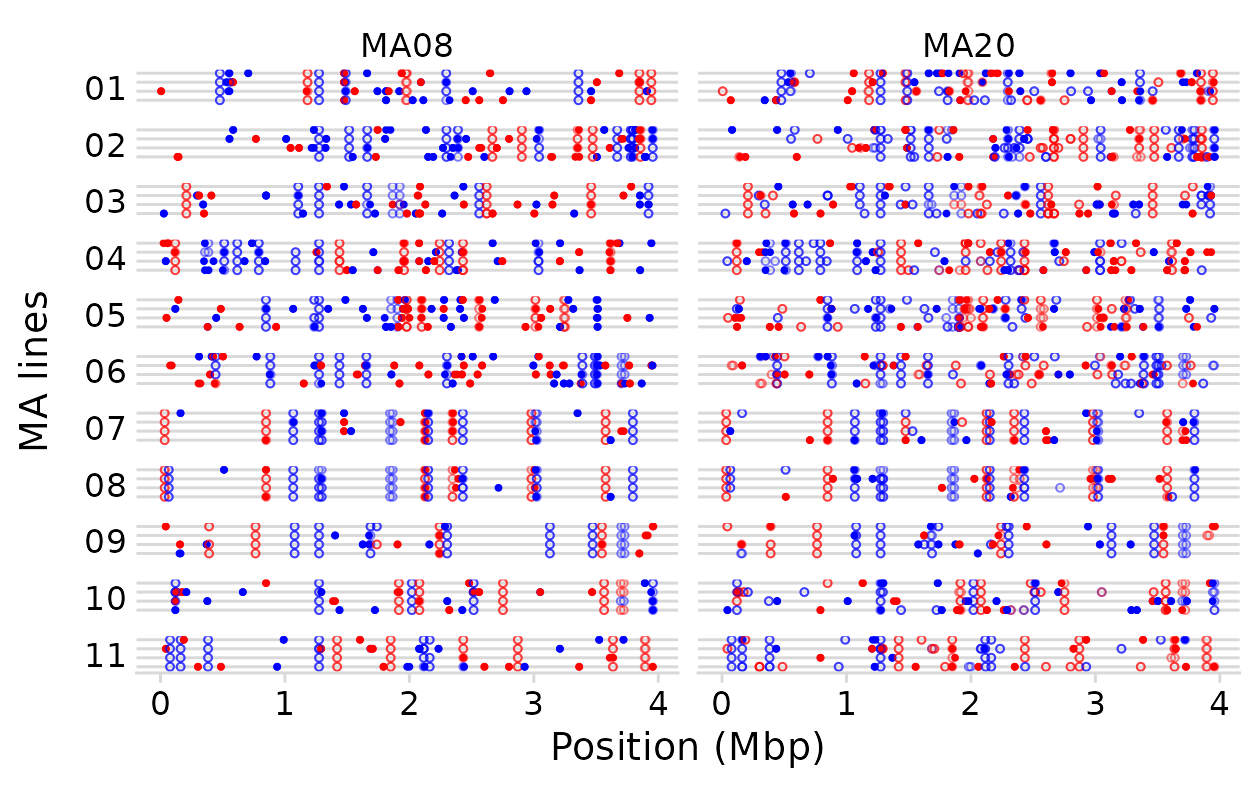

In [55]:
figure_name = file_prefix * "IS_insertion_pos_in_mds42_G8_G20"
@rput figure_name
R"""
p <- is_in_mds42.df.prevgen %>%
mutate(matched_row = is.na(matched_row.prev)) %>%
filter(Gen != "FACS") %>%
ggplot(aes(x = pos/1e6, y = 5- Subline, color = IS_strand)) +
geom_point(aes(shape = matched_row, alpha = matched_row), size = 1) +
scale_alpha_manual(values = c(0.5, 1)) +
scale_color_manual(values = c("blue", "red")) +
scale_shape_manual(values = c(1,16)) +
theme_minimal_hgrid() + 
ylim(0.5, 4.2)+
facet_grid(Parent~Gen, scales = "free_y", space = "free", switch = "y") +
theme(axis.text.y=element_blank(), legend.position = "none",  panel.margin.y = unit(0.5, "lines"),
strip.text.y.left = element_text(angle=0), axis.ticks.y = element_blank()) +
labs(x = "Position (Mbp)", y = "MA lines") 
ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=160, height=100, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=160, height=100, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

In [56]:
R"""
is_in_mds42.df.prevgen %>% filter(Gen != "MA08", Line == "L05-4", pos > 1.25e6, pos < 1.3e6) %>% head %>% data.frame
"""

RObject{VecSxp}
  pos_id IS_strand flank     pos genome cluster_id insert_id flankMatchDir
1      2     FALSE     r 1272612  Query          2         4          TRUE
2      2     FALSE     f 1275700  Query          6         5         FALSE
3      7     FALSE     r 1272612  Query          8         9          TRUE
4      7     FALSE     f 1275700  Query         31        10         FALSE
  position_status       sv  Line Parent Subline Gen_id  Gen matched_row.prev
1        original pristine L05-4     05       4      1 FACS               NA
2        original pristine L05-4     05       4      1 FACS               NA
3        original pristine L05-4     05       4      3 MA20             1290
4        original pristine L05-4     05       4      3 MA20             1289
  matched_row.facs
1              449
2              450
3             2537
4             2538


┌ Warning: RCall.jl: Warning: There was 1 warning in `arrange()`.
│ ℹ In argument: `..1 = -matched_row`.
│ Caused by warning in `Ops.factor()`:
│ ! ‘-’ not meaningful for factors
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


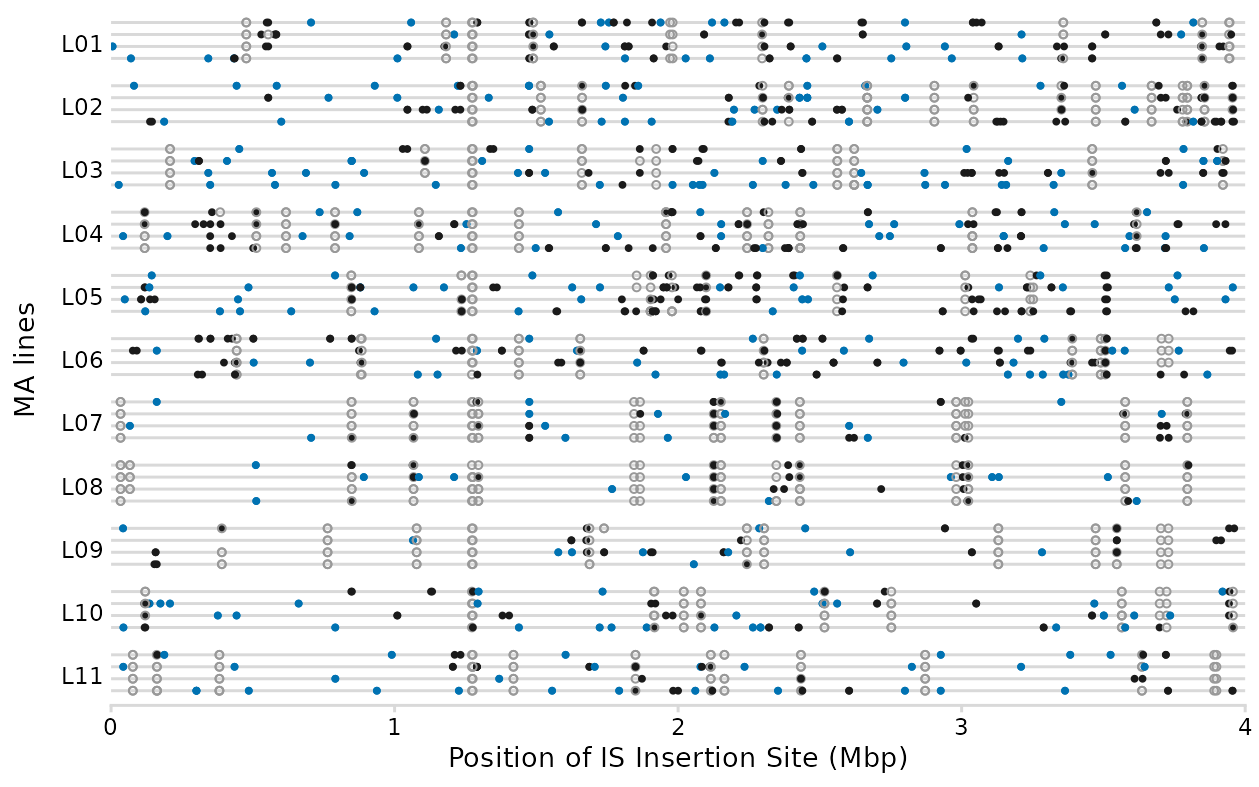

In [57]:
# change color for complex: black simple: blue
figure_name = file_prefix * "IS_insertion_pos_in_mds42_Gen20_with_facs_sc"
@rput figure_name
R"""
p <- is_in_mds42.df.prevgen %>%
mutate(no_matched_row = is.na(matched_row.facs)) %>%
mutate(matched_row = ifelse(no_matched_row, ifelse(sv == "simple_insertion", 2, 3), 1)) %>%
# factor in order
mutate(matched_row = factor(matched_row, levels = c(1, 2, 3))) %>%
mutate(Parent = paste0("L", Parent)) %>% # format: L01 etc
filter(Gen == "MA20") %>%
arrange(-matched_row) %>%
ggplot(aes(x = pos/1e6, y = 5- Subline, color = matched_row)) +
geom_point(aes(shape = matched_row, alpha = matched_row), size = 1) +
scale_alpha_manual(values = c(1, 1, 1)) +
scale_color_manual(values = c("grey60", "#0072b2", "grey10")) +
scale_shape_manual(values = c(1, 16, 16)) +
theme_minimal_hgrid(10) + 
coord_cartesian(xlim = c(0, 4))+
scale_x_continuous(expand = c(0,0), lim = c(0,4)) +
scale_y_continuous(breaks = c(1,2,3,4) , lim = c(0.0, 4.5)) +
facet_grid(Parent~., scales = "free_y", space = "free", switch = "y") +
theme(axis.text.y=element_blank(), legend.position = "none",  panel.margin.y = unit(0.1, "lines"),
strip.text.y.left = element_text(angle=0), axis.ticks.y = element_blank()) +
labs(x = "Position of IS Insertion Site (Mbp)", y = "MA lines") 
ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=180, height=80, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=180, height=80, units="mm", dpi=1000)
p.is.inspos.in.mds42.G20.facs.v2403 <- p
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

### FIG: Sliding window analysis (TOTAL)

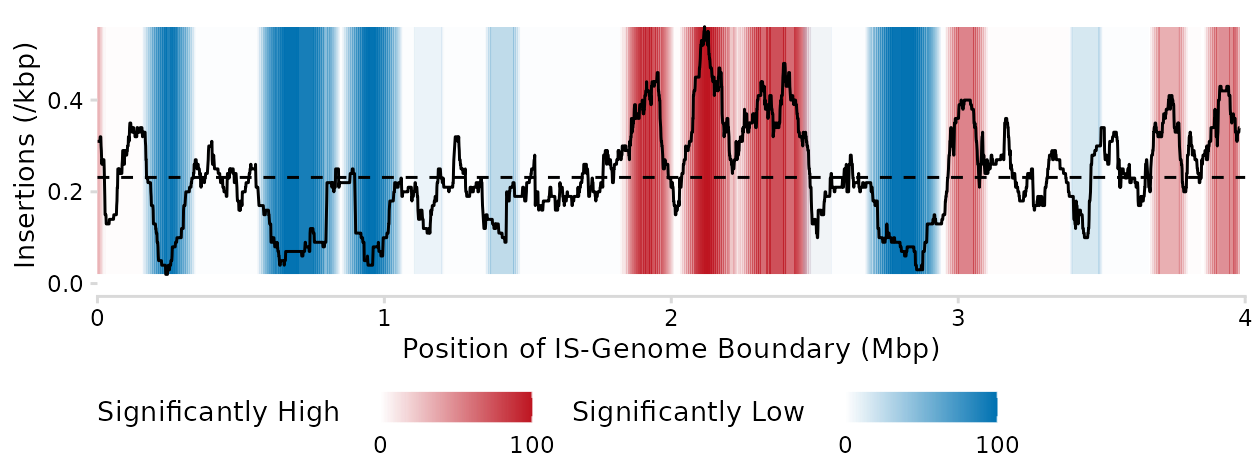

In [58]:
figure_name = file_prefix * "IS_insertion_pos_significance"
@rput figure_name
@rput windows_total
@rput total_ins_rate
R"""
mutation_rate <- total_ins_rate
windows <- windows_total
window_cnt <- window_cnt_total
df.tmp <- windows %>%
mutate(mid = ifelse(start < end, (start + end)/2, (start + end + ref_genome_size)/2)) %>%
  mutate(mid = mid - ref_genome_size * (mid > ref_genome_size)) %>%
  mutate(fill = ifelse(significant, ifelse(mutations_per_bp < mutation_rate, "B", "A"), "C"))

brewer.red <- "#be1521"#RColorBrewer::brewer.pal(3, "Set1")[1]
brewer.blue <- "#0072b2"#RColorBrewer::brewer.pal(3, "Set1")[2]
p <- ggplot()  +
  rasterise(
    geom_rect(
    data = window_cnt, #%>% filter(high_sig > 10),
      aes(xmin = start/1e6, xmax = end/1e6,
      ymin = min(windows_total$mutations_per_bp)*1e3,
      ymax = max(windows_total$mutations_per_bp)*1e3,
      fill = high_sig))
    , dpi = 1000) +
  scale_fill_gradient(low = alpha(brewer.red, 0.0), high = brewer.red, name = "Significantly High", breaks = c(0,100)) + 
  ggnewscale::new_scale_fill() +
  rasterise(
    geom_rect(
      data = window_cnt,# %>% filter(low_sig > 10),
      aes(xmin = start/1e6, xmax = end/1e6,
      ymin = min(windows_total$mutations_per_bp)*1e3,
      ymax = max(windows_total$mutations_per_bp)*1e3,
      fill = low_sig))
      , dpi = 1000
  )+
	scale_fill_gradient(low = alpha(brewer.blue, 0.0), high = brewer.blue, name = "Significantly Low", breaks = c(0,100)) +
  geom_hline(yintercept = mutation_rate*1e3, linetype = "dashed") +
  geom_line(data = df.tmp, aes(x=mid/1e6, y=mutations_per_bp*1e3)) + # Use both start and end for a clearer visualization
  xlab("Position of IS-Genome Boundary (Mbp)") +
  ylab('Insertions (/kbp)') +
  theme_minimal_hgrid(10) +
  coord_cartesian(xlim = c(0, 4))+
  scale_x_continuous(expand = c(0,0), lim = c(0,4)) +
  scale_y_continuous(lim = c(0,NA)) + 
  theme(legend.position = "bottom", panel.grid.major.y = element_blank(), panel.grid.minor.y = element_blank(),
    legend.spacing.x = unit(5, "mm"), legend.title = element_text(vjust = .8))
p.is.inspos.significance <- p

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=60, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=160, height=60, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=160, height=60, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

### FIG: Insertion hotspot and ESS

┌ Warning: RCall.jl: Scale for y is already present.
│ Adding another scale for y, which will replace the existing scale.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


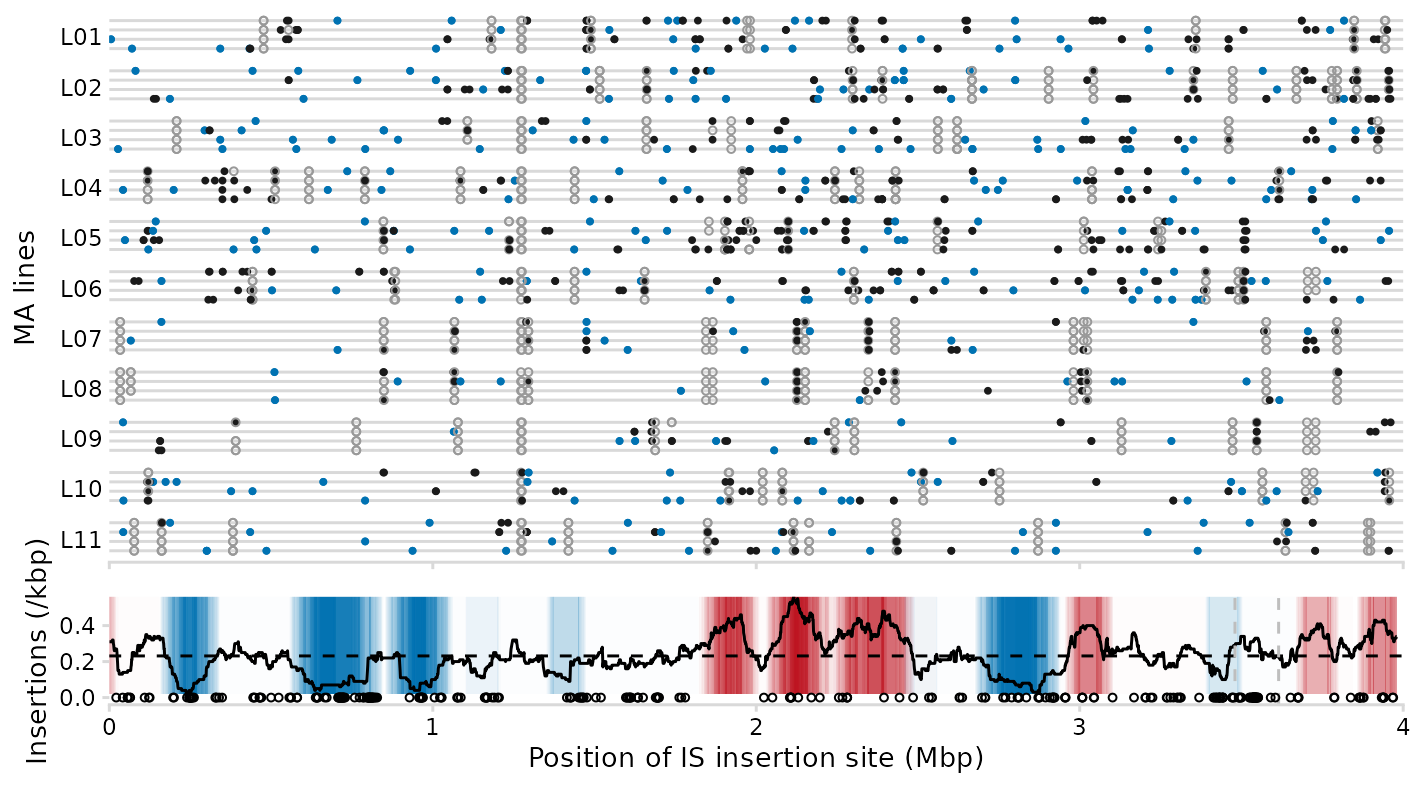

In [59]:
#fig:is_exp_ins_pos
figure_name = file_prefix * "IS_insertion_pos_and_significance_and_essential"
@rput figure_name
R"""
p <- plot_grid(p.is.inspos.in.mds42.G20.facs.v2403 + theme(axis.text.x=element_blank(), axis.title.x=element_blank()) +
ylab("MA lines"),
NULL,
p.is.inspos.significance+ geom_vline(xintercept = c(3.48, 3.615), linetype = "dashed", color = "grey") +
geom_point(data = essential_locus_plot_df %>% filter(Essential_PEC == TRUE, type == "G20"),
aes(x= (start+end)/2/1e6, y = 0), shape = 1, size = 1) +
scale_y_continuous(expand = expansion(add = c(0.04, 0)), breaks = c(0, 0.2, .4)) + 
theme(legend.position = "none") + labs(x = "Position of IS insertion site (Mbp)"),
ncol = 1, align = "hv", axis='lr', rel_heights = c(1, 0.00, 0.35))
ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=180, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=180, height=100, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=180, height=100, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

### DAT: is_in_mds42_coord

In [60]:
R"""
comment_header <- "# `Flank`: The 5' or 3' sequence of IS mapped to MDS42; `Clustered_Locus`: The ID of the locus where the IS is mapped to identify flanking sequences that are inserted to identical locus with only < 20 bp gap; `matched_row.XX`: Matched position is found in XX generation. IF NA, no match is found."
out_dir <- file.path(data_export_dir, paste0(file_prefix, "is_in_mds42_coord.csv"))
write_lines(comment_header, out_dir)
is_in_mds42.df.prevgen %>%
	select(Line, Gen, IS_ID = pos_id,  IS_strand, Flank = flank, Pos = pos, Clustered_Locus = cluster_id,
		New = position_status, Simple = sv, matched_row.prev, matched_row.facs) %>%
	mutate(Simple = ifelse(Simple == "simple_insertion", "Simple", "Complex")) %>%
	mutate(New = ifelse(New == "new", "New", "Preexisting")) %>%
	write_csv(out_dir, append = TRUE, col_names = TRUE)
""";

### DAT: windows stats

In [61]:
comment_header = "# test_side, side of one-sided binary tests"
open(joinpath(data_export_dir, file_prefix * "windows_total.csv"), "w") do io
	write(io, comment_header * "\n")
	CSV.write(io, windows_total, append=true, writeheader=true)
end

comment_header = "# test_side, side of one-sided binary tests"
open(joinpath(data_export_dir, file_prefix * "windows_simple.csv"), "w") do io
	write(io, comment_header * "\n")
	CSV.write(io, windows_simple, append=true, writeheader=true)
end

IOStream(<file ./exp/multiple_runs14/data/ins_del_analysis/20250204_windows_simple.csv>)

### FIG : Sliding window of insertion and essentiality

┌ Warning: RCall.jl: Scale for y is already present.
│ Adding another scale for y, which will replace the existing scale.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


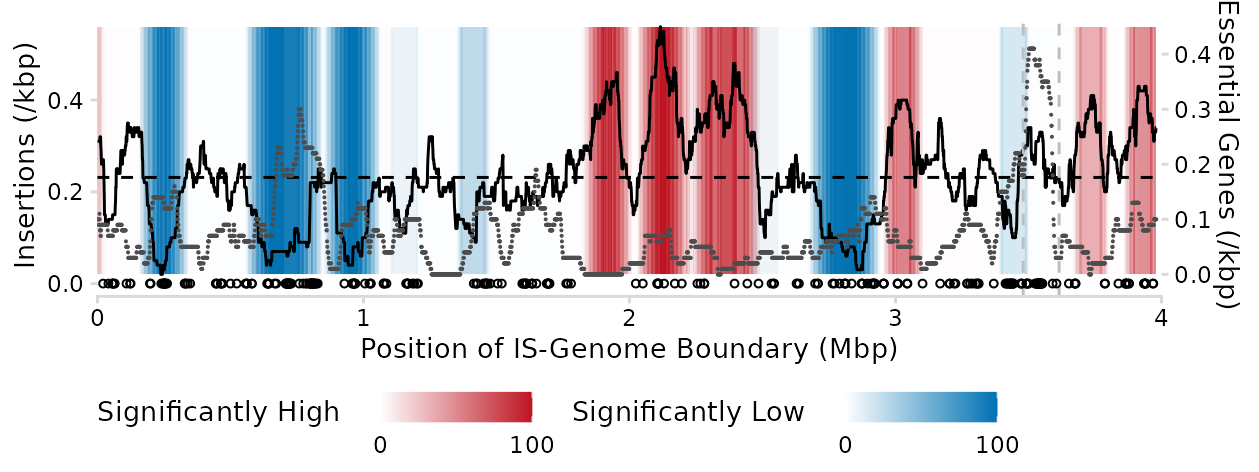

In [62]:
@rput windows_total_ess
figure_name = file_prefix * "IS_insertion_pos_significance_ess_cnt"
@rput figure_name
R"""
# for second axis scaling
scale_y <- 1.2 # manually set so that the values fit within the range of insertio rate 
shift_y <- min(windows_total$mutations_per_bp)*1e3

p <- p.is.inspos.significance+ geom_vline(xintercept = c(3.48, 3.615), linetype = "dashed", color = "grey") +
geom_point(data =
essential_locus_plot_df %>% filter(Essential_PEC == TRUE, type == "G20"),
aes(x= (start+end)/2/1e6, y = 0), shape = 1, size = 1) +
geom_point(data = windows_total_ess %>%
mutate(mid = ifelse(start < end, (start + end)/2, (start + end + ref_genome_size)/2)) %>%
  mutate(mid = mid - ref_genome_size * (mid > ref_genome_size)),
  aes(x = mid/1e6, y = ess_cnt/100 * scale_y + shift_y), color = "grey30", size = 0.03) + #linetype = "dotted") +
  scale_y_continuous(sec.axis = sec_axis(~(. -shift_y) /scale_y, name = "Essential Genes (/kbp)")) 
p.is.inspos.significance.ess <- p

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=60, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=160, height=60, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=160, height=60, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

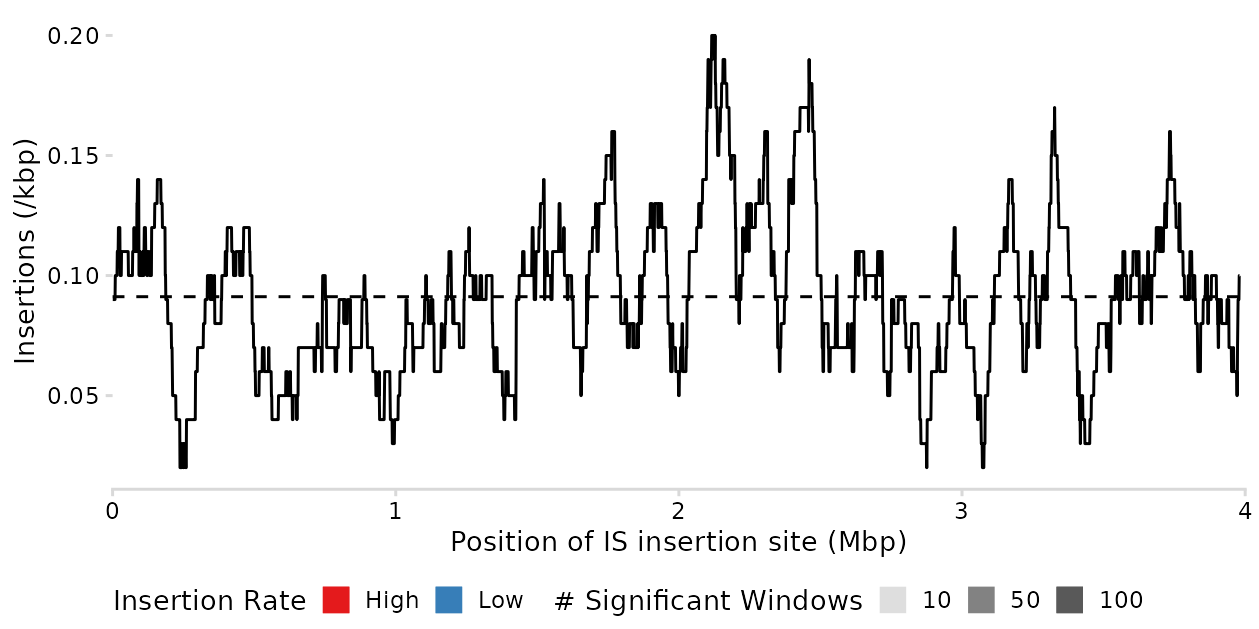

In [63]:
@rput window_cnt_simple
figure_name = file_prefix * "IS_insertion_pos_significance_simple"
@rput figure_name
@rput windows_simple
@rput simple_ins_rate
R"""
mutation_rate <- total_ins_rate 
mutation_rate_simple <- simple_ins_rate
windows <- windows_simple
df.tmp <- windows %>%
mutate(mid = ifelse(start < end, (start + end)/2, (start + end + ref_genome_size)/2)) %>%
  mutate(mid = mid - ref_genome_size * (mid > ref_genome_size)) %>%
  mutate(fill = ifelse(significant, ifelse(mutations_per_bp < mutation_rate, "B", "A"), "C"))

p <- ggplot()  +
  geom_rect(
	data = window_cnt_simple, # %>% filter(high_sig > 0),
    aes(xmin = start/1e6, xmax = end/1e6,
    ymin = min(windows_simple$mutations_per_bp)*1e3,
    ymax = max(windows_simple$mutations_per_bp)*1e3,
    fill = "A", alpha = high_sig)) +
  geom_rect(
    data = window_cnt_simple,# %>% filter(low_sig > 0),
    aes(xmin = start/1e6, xmax = end/1e6,
    ymin = min(windows_simple$mutations_per_bp)*1e3,
    ymax = max(windows_simple$mutations_per_bp)*1e3,
    fill = "B", alpha = low_sig)) +
  scale_fill_brewer(palette = "Set1", labels = c("High", "Low"), "Insertion Rate") +
  scale_alpha_continuous(range = c(0,1), limits = c(0,100), breaks = c(10, 50, 100), na.value = 0,
    name = "# Significant Windows") +
  geom_hline(yintercept = mutation_rate_simple*1e3, linetype = "dashed") +
  geom_line(data = df.tmp, aes(x=mid/1e6, y=mutations_per_bp*1e3)) + # Use both start and end for a clearer visualization
  xlab("Position of IS insertion site (Mbp)") +
  ylab('Insertions (/kbp)') +
  theme_minimal_hgrid(10) +
  coord_cartesian(xlim = c(0, 4))+
  scale_x_continuous(expand = c(0,0), lim = c(0,4)) +
  theme(legend.position = "bottom", panel.grid.major.y = element_blank(), panel.grid.minor.y = element_blank())
p.is.inspos.significance.simple <- p

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=80, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=160, height=80, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=160, height=80, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

┌ Warning: RCall.jl: Scale for y is already present.
│ Adding another scale for y, which will replace the existing scale.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


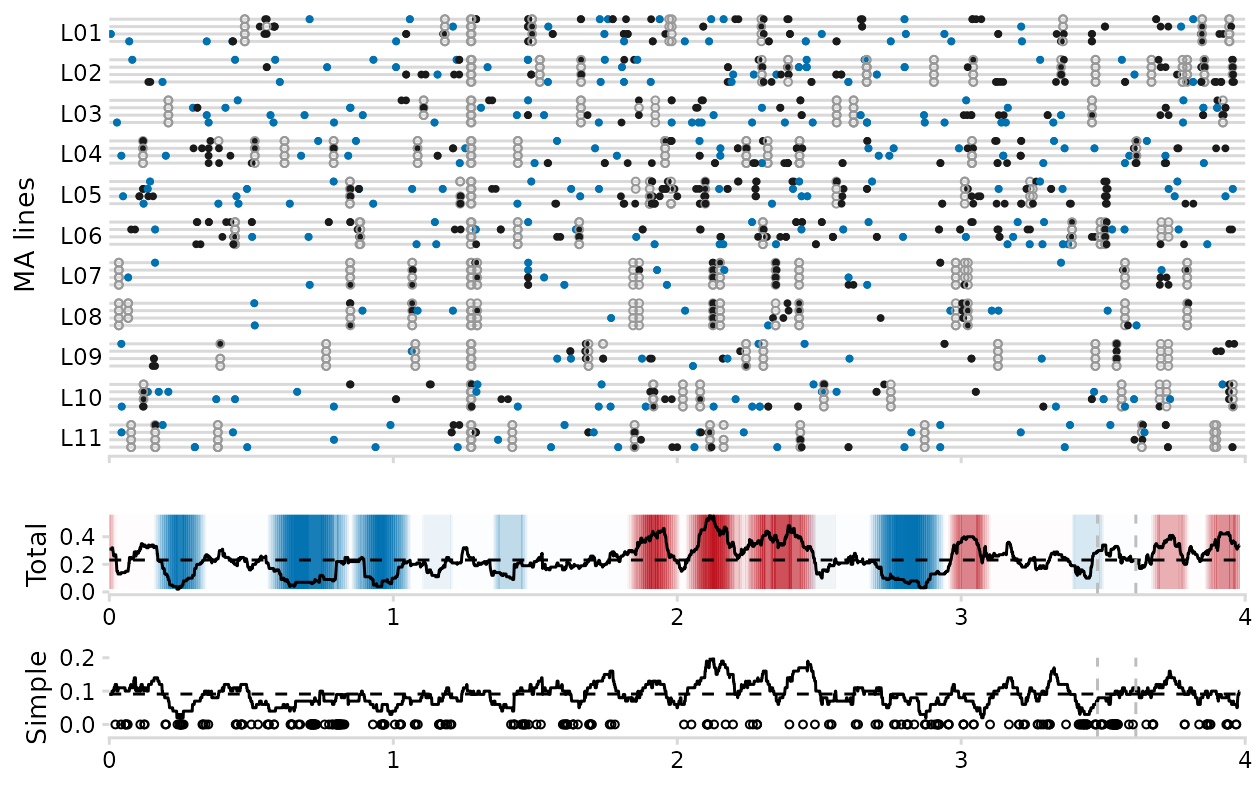

In [64]:
figure_name = file_prefix * "IS_insertion_pos_and_significance_and_essential_sc"
@rput figure_name
R"""
p <- plot_grid(p.is.inspos.in.mds42.G20.facs.v2403 + theme(axis.text.x=element_blank(), axis.title.x=element_blank()) +
ylab("MA lines"),
NULL,
p.is.inspos.significance + geom_vline(xintercept = c(3.48, 3.615), linetype = "dashed", color = "grey") +
#geom_point(data = essential_locus_plot_df %>% filter(Essential_PEC == TRUE, type == "G20"),
#aes(x= (start+end)/2/1e6, y = 0), shape = 1, size = 1) +
scale_y_continuous(expand = expansion(add = c(0.04, 0)), breaks = c(0, 0.2, .4)) + 
theme(legend.position = "none", axis.title.x = element_blank()) +
ylab("Total"),
p.is.inspos.significance.simple + geom_vline(xintercept = c(3.48, 3.615), linetype = "dashed", color = "grey") +
geom_point(data = essential_locus_plot_df %>% filter(Essential_PEC == TRUE, type == "G20"),
aes(x= (start+end)/2/1e6, y = 0), shape = 1, size = 1) +
scale_y_continuous(expand = expansion(add = c(0.04, 0)), breaks = c(0, 0.1, .2)) + 
theme(legend.position = "none", axis.title.x = element_blank()) +
ylab("Simple"),
ncol = 1, align = "hv", axis='lr', rel_heights = c(1, 0.05, 0.3, 0.3))

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=180, height=120, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=180, height=120, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

### STAT of hotspot in specific locus
Test in 1 M b terminus and 130 kb region homologous to consuegra region REL606  (3,315,000 .. 3,467,000)

In [65]:
R"""c(mutation_rate, mutation_rate_simple)"""

RObject{RealSxp}
[1] 2.313823e-04 9.119629e-05


In [66]:
R"""new_is_pos_in_mds42_df %>% head"""

RObject{VecSxp}
# A tibble: 6 × 5
# Groups:   Line, Gen [1]
  Line  Gen   insert_id      pos Type   
  <chr> <chr>     <dbl>    <dbl> <chr>  
1 L01-1 MA08          2  549440  Complex
2 L01-1 MA08          3  554375  Complex
3 L01-1 MA08          4  705281  Simple 
4 L01-1 MA08          8 1475270  Complex
5 L01-1 MA08         11 1660676. Simple 
6 L01-1 MA08         12 1938077. Simple 


In [67]:
# Terminus -> not used in paper as having 364 trials including L04-1 G20 might be confusing.
R"""
terminus <- (ref_genome_size + 1) /2
print("TOTAL")
terminus.p <- binom.test(length(new_is_pos_in_mds42_df %>% filter(terminus - 1e6/2 <= pos, pos < terminus + 1e6/2) %>% pull(pos)),
	as.integer(1e6), mutation_rate, alternative = "two.sided")
print(terminus.p)
print("SIMPLE")
terminus.p <- binom.test(length(new_is_pos_in_mds42_df %>% filter(terminus - 1e6/2 <= pos, pos < terminus + 1e6/2, Type == "Simple") %>% pull(pos)),
	as.integer(1e6), mutation_rate_simple, alternative = "two.sided")
print(terminus.p)
rm(terminus.p)
""";

[1] "TOTAL"

	Exact binomial test

data:  length(new_is_pos_in_mds42_df %>% filter(terminus - 1e+06/2 <= pos, pos < terminus + 1e+06/2) %>% pull(pos)) and as.integer(1e+06)
number of successes = 305, number of trials = 1e+06, p-value =
3.473e-06
alternative hypothesis: true probability of success is not equal to 0.0002313823
95 percent confidence interval:
 0.0002717319 0.0003412163
sample estimates:
probability of success 
              0.000305 

[1] "SIMPLE"

	Exact binomial test

data:  length(new_is_pos_in_mds42_df %>% filter(terminus - 1e+06/2 <= pos, pos < terminus + 1e+06/2, Type == "Simple") %>% pull(pos)) and as.integer(1e+06)
number of successes = 116, number of trials = 1e+06, p-value = 0.01183
alternative hypothesis: true probability of success is not equal to 9.119629e-05
95 percent confidence interval:
 9.585396e-05 1.391293e-04
sample estimates:
probability of success 
              0.000116 



In [68]:
# Terminus (Excluding L04-1 G20) -> used in paper
R"""
# change mutation rate per bp based on the exclusion of L04-1 Gen 20
exclusion.ratio <- (new_is_pos_in_mds42_df %>% filter(Type == "Simple", !(Line=="L04-1" & Gen=="MA20")) %>% pull(pos) %>% length) / (new_is_pos_in_mds42_df %>% filter(Type == "Simple") %>% pull(pos) %>% length)
print("SIMPLE")
terminus.p <- binom.test(length(new_is_pos_in_mds42_df %>% filter(terminus - 1e6/2 <= pos, pos < terminus + 1e6/2, Type == "Simple", !(Line=="L04-1" & Gen=="MA20")) %>% pull(pos)),
	as.integer(1e6), mutation_rate_simple * exclusion.ratio, alternative = "two.sided")
print(terminus.p)
rm(terminus.p)
""";

[1] "SIMPLE"

	Exact binomial test

data:  length(new_is_pos_in_mds42_df %>% filter(terminus - 1e+06/2 <= pos, pos < terminus + 1e+06/2, Type == "Simple", !(Line == "L04-1" & Gen == "MA20")) %>% pull(pos)) and as.integer(1e+06)
number of successes = 115, number of trials = 1e+06, p-value = 0.01122
alternative hypothesis: true probability of success is not equal to 8.994014e-05
95 percent confidence interval:
 0.0000949452 0.0001380385
sample estimates:
probability of success 
              0.000115 



In [69]:
R"""
print(paste("terminus:", new_is_pos_in_mds42_df %>% filter(((terminus - 1e6/2 <= pos) & (pos < terminus + 1e6/2)), Type == "Simple") %>% pull(pos) %>% length))
print(paste("terminus - L04-1_G20:", new_is_pos_in_mds42_df %>% filter(((terminus - 1e6/2 <= pos) & (pos < terminus + 1e6/2)), Type == "Simple", !(Line=="L04-1" & Gen=="MA20")) %>% pull(pos) %>% length))
print(paste("All:", new_is_pos_in_mds42_df %>% filter(Type == "Simple") %>% pull(pos) %>% length))
print(paste("All - L04-1_G20:", new_is_pos_in_mds42_df %>% filter(Type == "Simple", !(Line=="L04-1" & Gen=="MA20")) %>% pull(pos) %>% length))
""";

[1] "terminus: 116"
[1] "terminus - L04-1_G20: 115"
[1] "All: 363"
[1] "All - L04-1_G20: 358"


In [70]:
# IS-empty region in LTEE
R"""
range.start <- 3.48e6
range.end <- 3.615e6
print("TOTAL")
consuegra.is.devoid.binom.p <- binom.test(length(new_is_pos_in_mds42_df %>% filter(range.start <= pos, pos < range.end) %>% pull(pos)),
	as.integer(range.end - range.start), mutation_rate, alternative = "two.sided")
print(consuegra.is.devoid.binom.p)
print("SIMPLE")
consuegra.is.devoid.binom.p <- binom.test(length(new_is_pos_in_mds42_df %>% filter(range.start <= pos, pos < range.end, Type == "Simple") %>% pull(pos)),
	as.integer(range.end - range.start), mutation_rate_simple, alternative = "two.sided")
print(consuegra.is.devoid.binom.p)
rm(consuegra.is.devoid.binom.p)
""";

[1] "TOTAL"

	Exact binomial test

data:  length(new_is_pos_in_mds42_df %>% filter(range.start <= pos, pos < range.end) %>% pull(pos)) and as.integer(range.end - range.start)
number of successes = 39, number of trials = 135000, p-value = 0.1781
alternative hypothesis: true probability of success is not equal to 0.0002313823
95 percent confidence interval:
 0.0002054361 0.0003948997
sample estimates:
probability of success 
          0.0002888889 

[1] "SIMPLE"

	Exact binomial test

data:  length(new_is_pos_in_mds42_df %>% filter(range.start <= pos, pos < range.end, Type == "Simple") %>% pull(pos)) and as.integer(range.end - range.start)
number of successes = 12, number of trials = 135000, p-value = 1
alternative hypothesis: true probability of success is not equal to 9.119629e-05
95 percent confidence interval:
 0.0000459310 0.0001552658
sample estimates:
probability of success 
          8.888889e-05 



In [71]:
# One sided test I want to test if there is depletion of IS insertions
R"""
range.start <- 3.48e6
range.end <- 3.615e6
print("TOTAL")
consuegra.is.devoid.binom.p <- binom.test(length(new_is_pos_in_mds42_df %>% filter(range.start <= pos, pos < range.end) %>% pull(pos)),
as.integer(range.end - range.start), mutation_rate, alternative = "less")
print(consuegra.is.devoid.binom.p)
print("SIMPLE")
consuegra.is.devoid.binom.p <- binom.test(length(new_is_pos_in_mds42_df %>% filter(range.start <= pos, pos < range.end, Type == "Simple") %>% pull(pos)),
	as.integer(range.end - range.start), mutation_rate_simple, alternative = "less")
print(consuegra.is.devoid.binom.p)
rm(consuegra.is.devoid.binom.p)
""";

[1] "TOTAL"

	Exact binomial test

data:  length(new_is_pos_in_mds42_df %>% filter(range.start <= pos, pos < range.end) %>% pull(pos)) and as.integer(range.end - range.start)
number of successes = 39, number of trials = 135000, p-value = 0.9263
alternative hypothesis: true probability of success is less than 0.0002313823
95 percent confidence interval:
 0.0000000000 0.0003773147
sample estimates:
probability of success 
          0.0002888889 

[1] "SIMPLE"

	Exact binomial test

data:  length(new_is_pos_in_mds42_df %>% filter(range.start <= pos, pos < range.end, Type == "Simple") %>% pull(pos)) and as.integer(range.end - range.start)
number of successes = 12, number of trials = 135000, p-value = 0.5404
alternative hypothesis: true probability of success is less than 9.119629e-05
95 percent confidence interval:
 0.0000000000 0.0001440151
sample estimates:
probability of success 
          8.888889e-05 



## Plot the distribution of numbers
The reviewer asked me for the effect size, but I don't know how.I
I give the distribution ofthe number in relevance to the CI of binomeial distribution.

In [72]:
windows_total_ar_dir = joinpath("rdata", "$(run_date)_windows_total.arrow")
Arrow.write(windows_total_ar_dir, windows_total)
windows_simple_ar_dir = joinpath(data_export_dir, "$(run_date)_windows_simple.arrow")
Arrow.write(windows_simple_ar_dir, windows_simple)

@rput windows_total_ar_dir windows_simple_ar_dir
R"""
windows_total <- read_feather(windows_total_ar_dir)
windows_simple <- read_feather(windows_simple_ar_dir)
windows_simple %>% head(2) %>% collect
"""

RObject{VecSxp}
# A tibble: 2 × 8
  start    end mutation_count mutations_per_bp p_value adjusted_p_value
  <int>  <int>          <int>            <dbl>   <dbl>            <dbl>
1     1 100000             11          0.00011   0.617            0.964
2  1001 101000             11          0.00011   0.617            0.964
# ℹ 2 more variables: significant <lgl>, test_side <chr>


In [73]:
R"""
glm.win.simple <- glm(mutation_count ~ 1, family = poisson,
	data = windows_simple %>% filter(end %% 100000 == 0)) # avoid overlaps
summary(glm.win.simple)
"""

RObject{VecSxp}

Call:
glm(formula = mutation_count ~ 1, family = poisson, data = windows_simple %>% 
    filter(end%%1e+05 == 0))

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  2.20827    0.05241   42.13   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 54.748  on 39  degrees of freedom
Residual deviance: 54.748  on 39  degrees of freedom
AIC: 216.07

Number of Fisher Scoring iterations: 4



┌ Warning: RCall.jl: Warning: The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
│ ℹ Please use `after_stat(density)` instead.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


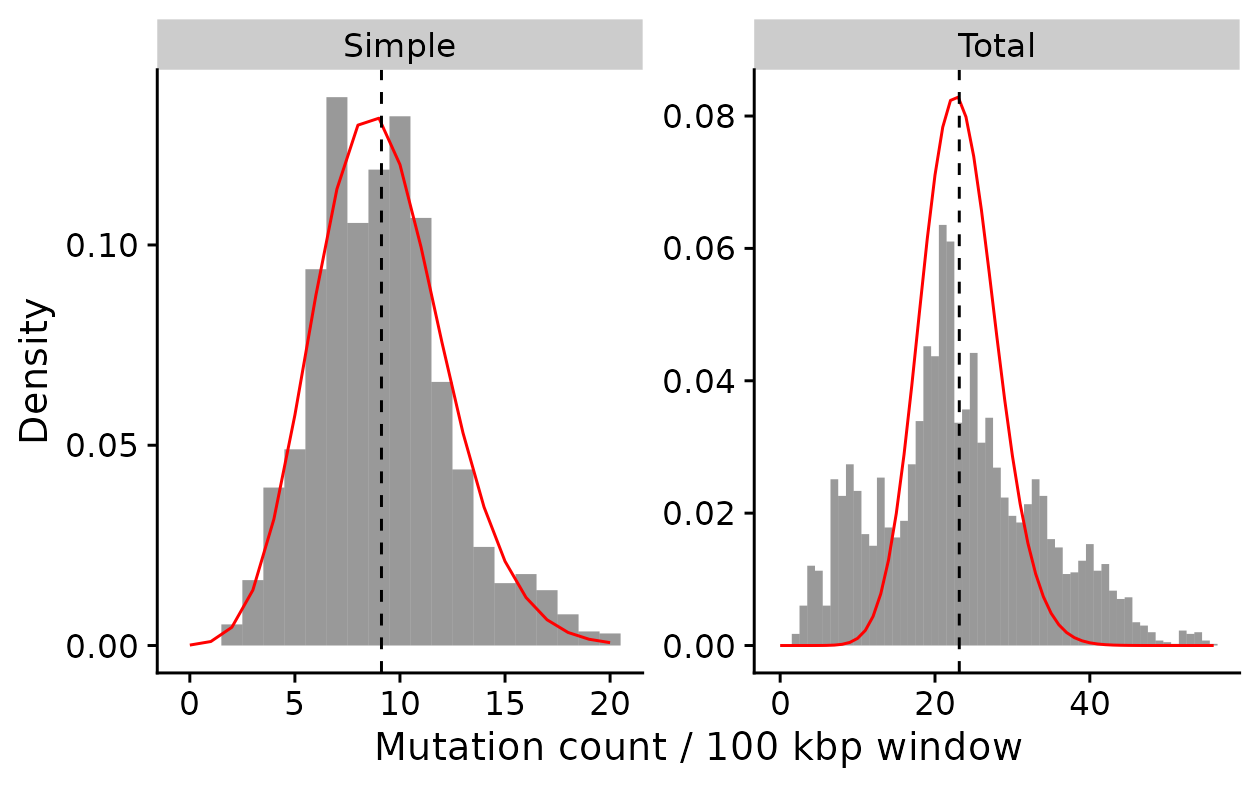

In [74]:
figure_name = file_prefix * "ins_windows_raw_dist"
@rput figure_name
R"""
lambda_hat.simple <- mean(windows_simple$mutation_count, na.rm = TRUE)
poiss_df <- data.frame(x = seq(0, max(windows_simple$mutation_count), by = 1)) %>%
  mutate(y = dpois(x, lambda = lambda_hat.simple), type = "Simple")
lambda_hat.total <- mean(windows_total$mutation_count, na.rm = TRUE)
poiss_df_total <- data.frame(x = seq(0, max(windows_total$mutation_count), by = 1)) %>%
  mutate(y = dpois(x, lambda = lambda_hat.total), type = "Total")
poiss_df <- rbind(poiss_df, poiss_df_total)
lambda_df <- data.frame(type = c("Simple", "Total"), lambda = c(lambda_hat.simple, lambda_hat.total))

p <- ggplot() +
  geom_histogram(data = windows_simple %>% select(mutation_count) %>%
					mutate(type = "Simple"),
		aes(x = mutation_count, y = ..density..), binwidth = 1, fill = "black", alpha = 0.4) +  # Histogram (scaled to density)
  geom_histogram(data = windows_total%>% select(mutation_count) %>%
					mutate(type = "Total"),
		aes(x = mutation_count, y = ..density..), binwidth = 1, fill = "black", alpha = 0.4) +  # Histogram (scaled to density)
  geom_line(data = poiss_df, aes(x = x, y = y), color = "red") +  # Poisson density curve
  facet_wrap(~type, scales = "free") +
  geom_vline(data = lambda_df, aes(xintercept = lambda), linetype = "dashed") +
  labs(
       x = "Mutation count / 100 kbp window",
       y = "Density") +
  theme_half_open()
ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=160, height=80, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=160, height=80, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

In [75]:
R"""
windows_total.fd.pois <- fitdist(windows_total$mutation_count, "pois")
gofstat(windows_total.fd.pois)
"""

RObject{VecSxp}
Chi-squared statistic:  777365.2 
Degree of freedom of the Chi-squared distribution:  29 
Chi-squared p-value:  0 
   the p-value may be wrong with some theoretical counts < 5  
Chi-squared table:
         obscounts   theocounts
<= 5  124.00000000   0.02477692
<= 7  124.00000000   0.32678578
<= 8   90.00000000   0.72557938
<= 9  109.00000000   1.86529531
<= 10  93.00000000   4.31571516
<= 12 127.00000000  26.57954014
<= 13 101.00000000  31.14949527
<= 15 136.00000000 130.88271192
<= 17 184.00000000 271.09541267
<= 18 135.00000000 200.87051066
<= 19 180.00000000 244.60636704
<= 20 174.00000000 282.97165607
<= 21 253.00000000 311.76604703
<= 22 243.00000000 327.87727000
<= 23 134.00000000 329.82885648
<= 24 142.00000000 317.96739003
<= 25 176.00000000 294.27119178
<= 26 122.00000000 261.86627764
<= 27 137.00000000 224.39903524
<= 28 107.00000000 185.42493217
<= 29  89.00000000 147.93648843
<= 31 152.00000000 199.24659921
<= 32  85.00000000  61.56840501
<= 33 100.00000000 

In [76]:
R"""
windows_simple.fd.pois <- fitdist(windows_simple$mutation_count, "pois")
gofstat(windows_simple.fd.pois)
"""

RObject{VecSxp}
Chi-squared statistic:  165.1958 
Degree of freedom of the Chi-squared distribution:  12 
Chi-squared p-value:  4.577329e-29 
Chi-squared table:
      obscounts theocounts
<= 3   86.00000   77.61532
<= 4  157.00000  125.59648
<= 5  195.00000  229.08974
<= 6  374.00000  348.21910
<= 7  545.00000  453.68324
<= 8  420.00000  517.20288
<= 9  473.00000  524.10296
<= 10 526.00000  477.98559
<= 11 425.00000  396.29656
<= 12 262.00000  301.18771
<= 13 175.00000  211.29639
<= 14  98.00000  137.64557
<= 16 133.00000  131.39233
> 16  112.00000   49.68613

Goodness-of-fit criteria
                               1-mle-pois
Akaike's Information Criterion   20408.96
Bayesian Information Criterion   20415.25


## IS event cnt and IS CN

### IS event cnt using Consuegra Fig

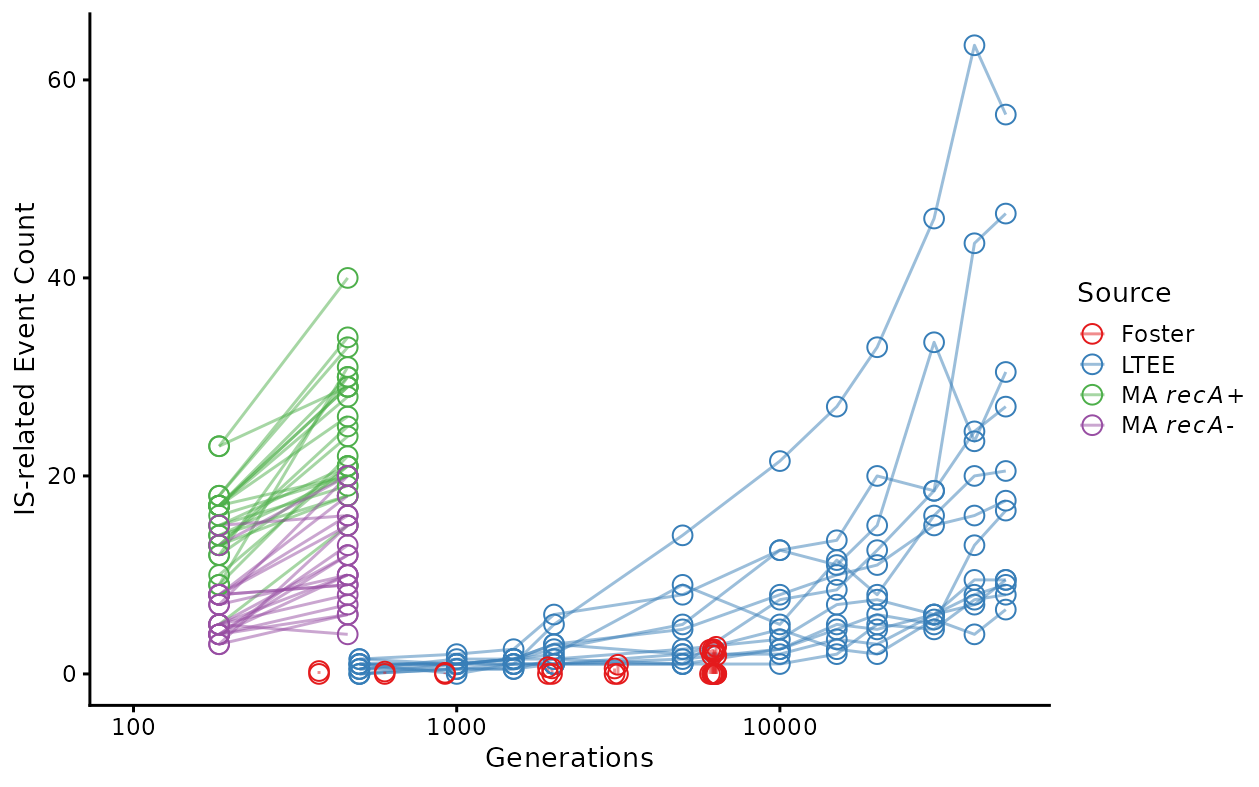

In [77]:
figure_name = file_prefix * "is_related_events"
@rput figure_name
@rput genome_stats_df
R"""
c.f.3ab_ <- c.f.3ab %>%
	mutate(Generations = ifelse(Generations == 0, 1, Generations)) %>%
	mutate(Source = "LTEE")
fosterMA_ <- Foster_ %>%
	rename(Event_CNT = Insertion)

## IS event: new_cnt_anc is the number of IS insertion sites based on the ancestral genome coordinates
genome_stats_df.isevent <- genome_stats_df %>%
	mutate(Generations = map_int(gen_id, ~ MA_generations[.x]),
		Population = Prefix,
		Source = ifelse(RecA, "MA recA+", "MA recA-"),
		Event_CNT = new_cnt_anc) %>%
		select(Population, Generations, Event_CNT, Source)
p<- genome_stats_df.isevent %>% rbind(fosterMA_) %>% rbind(c.f.3ab_) %>%
	filter(Generations > 100) %>%
	arrange(Population, rev(Source)) %>%
	ggplot(aes(x = Generations, y = Event_CNT, color = Source)) +
	geom_line(aes(group = Population), alpha = 0.5) +
	geom_point(shape=1, size = 3) + scale_x_log10(lim=c(100,NA)) +
	ylim(0, NA) + 
	labs(x = "Generations", y = "IS-related Event Count", color = "Source") + 
	theme_half_open(10)+
	theme(legend.text = element_text(hjust = 0)) +
	scale_color_brewer(palette = "Set1", 
                   labels = c("Foster", "LTEE", expression(paste("MA ",italic(recA),"+")), expression(paste("MA ",italic(recA),"-"))))

p.is.event <- p
ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=5.0, height=3.0, units="in", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))


In [78]:
R"""
print("IS-medaited event count in LTEE")
c.f.3ab_ %>% group_by(Generations)  %>% summarise(Event_CNT = sum(Event_CNT)) %>% print
""";

[1] "IS-medaited event count in LTEE"
# A tibble: 12 × 2
   Generations Event_CNT
         <dbl>     <dbl>
 1           1       0  
 2         500       8.5
 3        1000      11  
 4        1500      15  
 5        2000      28.5
 6        5000      51.5
 7       10000      83  
 8       15000     106  
 9       20000     128. 
10       30000     180. 
11       40000     240  
12       50000     258. 


### FIG: CN change of LTEE using barrick data

In [79]:
R"""
LTEE.summary <- LTEE.df %>% select(population, sample, time, clone, inserted_bp, deleted_bp, starts_with("mobile_element")) %>%
pivot_longer(starts_with("mobile_element.IS"), names_to = "IS", values_to = "number") %>%
mutate(IS = gsub("mobile_element.IS", "IS", IS)) %>%
group_by(population, time, IS) %>% 
summarise(number = mean(number), inserted_bp = mean(inserted_bp), deleted_bp = mean(deleted_bp)) %>% 
group_by(population, time) %>%
summarise(number = sum(number), inserted_bp = mean(inserted_bp), deleted_bp = mean(deleted_bp)) %>%
ungroup
LTEE.summary %>% head(5)
"""

┌ Warning: RCall.jl: `summarise()` has grouped output by 'population', 'time'. You can override
│ using the `.groups` argument.
│ `summarise()` has grouped output by 'population'. You can override using the
│ `.groups` argument.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 5 × 5
  population  time number inserted_bp deleted_bp
  <chr>      <dbl>  <dbl>       <dbl>      <dbl>
1 Ara+1        500    0.5        674.      5508 
2 Ara+1       1000    0.5        723       1272 
3 Ara+1       1500    0            0       6274.
4 Ara+1       2000    3        35681       6861 
5 Ara+1       5000   11.5      17352.     26124 


In [80]:
R"""
print("New IS insertion count in LTEE") 
LTEE.summary %>% group_by(time) %>% summarise(number = sum(number)) %>% data.frame %>%
head(5)
"""

[1] "New IS insertion count in LTEE"


RObject{VecSxp}
  time number
1  500      2
2 1000      3
3 1500      6
4 2000     14
5 5000     32


## Depth using ASM20
deletion, duplication analysis using pysam  minimap2 asm20.

┌ Warning: RCall.jl: Scale for y is already present.
│ Adding another scale for y, which will replace the existing scale.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


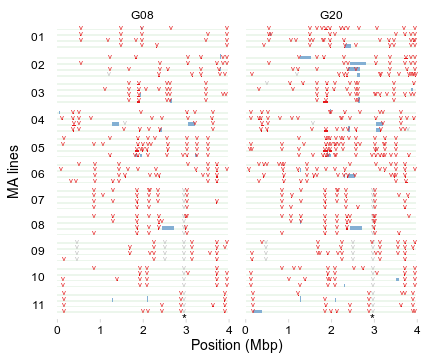

RObject{VecSxp}


In [81]:
R"""
depth_interval_df_ <- depth_interval_df %>% 
	mutate(Parent = str_sub(Parent, 2)) %>% # for group by parent
	mutate(ymin = 4-Subline) %>% # order reverse
	mutate(ymax = ymin + 0.3*depth) %>%
	mutate(fill = ifelse(depth > 1, "B", "C")) %>%
	mutate(fill = ifelse(depth < 1, "A", fill)) %>%
	mutate(ymax = ifelse(depth < 1, ymin + 0.2, ymax)) %>%
	mutate(alpha = ifelse(depth==1, 0.3, ifelse(depth>1, 0.7, 1))) %>%
	mutate(ymax = ifelse(depth >3 , ymin + 0.3 * 3, ymax)) # MAX DUP

p1.asm20 <- depth_interval_df_ %>%
filter(Gen %in% c("G08", "G20")) %>%
ggplot() +
geom_rect(aes(xmin = start_fix/1e6, xmax = end_fix/1e6, ymin = ymin, ymax = ymax, fill = fill, alpha = alpha)) +
scale_fill_brewer(palette = "Set1") +
scale_color_brewer(palette = "Set1") +
geom_point(data = depth_interval_df_ %>% filter(depth == 0, is_start == -1, is_end == -1, Gen %in% c("G08", "G20")),
aes(x = (start_fix + end_fix)/2 / 1e6, y = ymin + 0.4), size = 2.4, shape = "v", color = "grey") +  #'\u2304') + # DEL MARKER
geom_point(data = depth_interval_df_ %>% filter(depth == 0, is_start != -1 | is_end != -1, Gen %in% c("G08", "G20")),
aes(x = (start_fix + end_fix)/2 / 1e6, y = ymin + 0.4, color = fill), size = 2.4, shape = "v") +  #'\u2304') + # DEL MARKER
geom_point(data = data.frame(x = mean(2958683, 2959838)/1e6, y = -0.5, Parent = "11", Gen = c("G08","G20")),
aes(x = x ,y =y), shape = "*", size = 4, color = "black") + # RECA
#geom_point(data = data.frame(x = mean(3870531, 3870612)/1e6, y = -0.3, Parent = "11", Gen = c("G08","G20")),
#aes(x = x ,y =y), shape = "*", size = 4, color = "black") + # RECA small common deletion filtered out due to < min_del_threshold
theme_minimal_hgrid() + 
facet_grid(Parent~Gen, switch = "y", scales = "free_y", space = "free_y") +
ylim(-0.2,NA)+
scale_y_continuous(expand = c(0.0,0.5)) +
theme(axis.text.y=element_blank(), legend.position = "none", panel.margin.y = unit(0.005, "inch"),
strip.text.y.left = element_text(angle=0), axis.ticks.y = element_blank(),
panel.grid.major.y = element_blank(), panel.grid.minor.y = element_blank(),
axis.line=element_blank()) +
labs(x = "Position (Mbp)", y = "MA lines") 
"""

In [82]:
R"""
depth_interval_df_.RecA.G20 <- depth_interval_df_ %>%
filter(Gen == "G20", Parent  %in% c("01", "02", "03", "04", "05", "06"))

p1.asm20.RecA.G20 <- 
depth_interval_df_.RecA.G20 %>%
ggplot() +
geom_rect(aes(xmin = start_fix/1e6, xmax = end_fix/1e6, ymin = ymin, ymax = ymax, fill = fill, alpha = alpha)) +
scale_fill_brewer(palette = "Set1") +
scale_color_brewer(palette = "Set1") +
geom_point(data = depth_interval_df_.RecA.G20 %>% filter(depth == 0, is_start == -1, is_end == -1),
aes(x = (start_fix + end_fix)/2 / 1e6, y = ymin + 0.4), size = 2.4, shape = "v", color = "grey") +  #'\u2304') + # DEL MARKER
geom_point(data = depth_interval_df_.RecA.G20 %>% filter(depth == 0, is_start != -1 | is_end != -1),
aes(x = (start_fix + end_fix)/2 / 1e6, y = ymin + 0.4, color = fill), size = 2.4, shape = "v") +  #'\u2304') + # DEL MARKER
#geom_point(data = data.frame(x = mean(3870531, 3870612)/1e6, y = -0.3, Parent = "06", Gen = c("G20")),
#aes(x = x ,y =y), shape = "*", size = 6, color = "black") + # RECA filtered out due to < min_del_threshold
theme_minimal_hgrid(10) + 
#facet_grid(Parent~Gen, switch = "y", scales = "free_y", space = "free_y") +
facet_grid(Parent~., switch = "y", scales = "free_y", space = "free_y") +
ylim(-0.2,NA)+
scale_y_continuous(expand = c(0.0,0.5)) +
theme(axis.text.y=element_blank(), legend.position = "none", panel.margin.y = unit(0.005, "inch"),
strip.text.y.left = element_text(angle=0), axis.ticks.y = element_blank(),
panel.grid.major.y = element_blank(), panel.grid.minor.y = element_blank(),
axis.line=element_blank()) +
labs(x = "Position (Mbp)", y = "MA lines") 
""";

┌ Warning: RCall.jl: Scale for y is already present.
│ Adding another scale for y, which will replace the existing scale.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


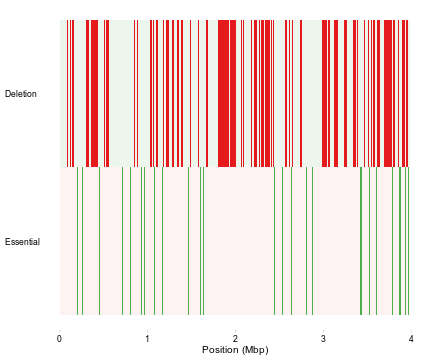

RObject{VecSxp}


In [83]:
# only use PEC and use RecA strains 
R"""
p4.asm20.3 <- depth_df %>% 
#filter(type != "TOTAL") %>%
filter(type == "G20") %>%
mutate(fill = ifelse(remain == 0, "A", "C")) %>%
mutate(alpha = ifelse(remain == 1, 0.3, 1)) %>%
ggplot() + 
geom_rect(aes(xmin = start/1e6, xmax = end/1e6, ymin = 2, ymax = 3, fill = fill, alpha = alpha)) +
scale_fill_manual(values = cols_) +
theme_minimal_hgrid(10) +
labs(x = "Position (Mbp)") + 
theme(axis.text.y=element_blank(), legend.position = "none",
strip.text.y.left = element_text(angle=0), axis.ticks.y = element_blank(),
panel.grid.major.y = element_blank(), panel.grid.minor.y = element_blank(),
axis.line=element_blank(), strip.background = element_blank(), strip.text.x = element_blank()) +
geom_rect(data= essential_locus_plot_df %>% filter(fill == "A", type == "G20"),
aes(xmin = start/1e6, xmax = end/1e6, ymin = 1, ymax = 2, fill = fill), alpha=.05) +
geom_rect(data = essential_locus_plot_df %>% filter(Essential_PEC == TRUE, type == "G20"),
aes(xmin = start/1e6, xmax = end/1e6, ymin = 1, ymax = 2, fill = fill, alpha = alpha)) +
facet_grid(~type) +
scale_y_continuous(breaks = c(1.5, 2.5), labels = c("Essential", "Deletion")) +
theme(axis.text.y= element_text(hjust = 0))
"""

┌ Warning: RCall.jl: Warning: The `panel.margin.x` argument of `theme()` is deprecated as of ggplot2 2.2.0.
│ ℹ Please use the `panel.spacing.x` argument instead.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


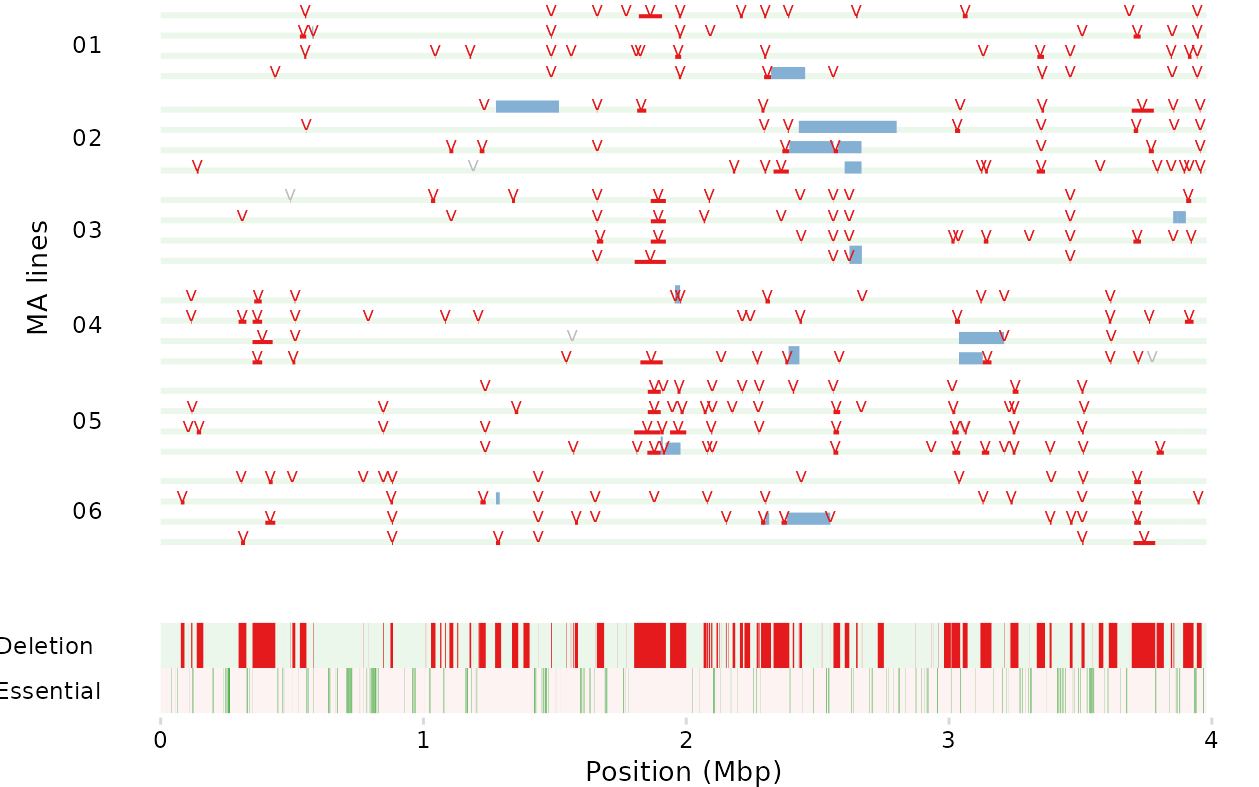

In [84]:
figure_name = file_prefix * "R06_deletion_intervals_asm20_RecA"
@rput figure_name
R"""
p <- plot_grid(p1.asm20.RecA.G20 + theme(panel.margin.x=unit(0.2, "lines")) + theme(plot.margin = unit(c(0, 0, 0, 0), "cm")) +
theme(axis.ticks.x = element_blank(), axis.text.x = element_blank(), axis.title.x = element_blank()),
NULL,
p4.asm20.3 + theme(panel.margin.x=unit(0.4, "lines"),plot.margin = unit(c(0, 0, 0, 0), "cm")) 
, ncol = 1, rel_heights = c(1, 0.1, 0.3), align = "hv", axis = "lr")
ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=160, height=100, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=160, height=100, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

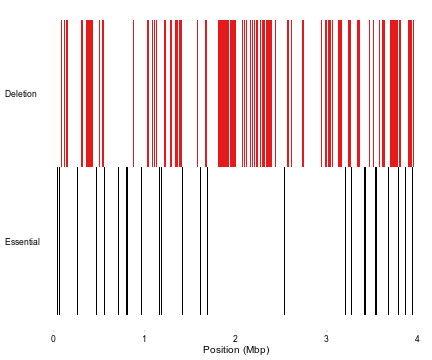

RObject{VecSxp}


In [85]:
R"""
p4.asm20.4 <- depth_df %>% 
filter(type == "G20") %>%
mutate(fill = ifelse(remain == 0, "A", "C")) %>%
mutate(alpha = ifelse(remain == 1, 0.3, 1)) %>%
filter(fill == "A") %>%
ggplot() + 
geom_rect(aes(xmin = start/1e6, xmax = end/1e6, ymin = 2, ymax = 3, fill = fill)) +
scale_x_continuous(expand = c(0,0.1), breaks = c(0,1,2,3,4), lim = c(0,4)) +
scale_fill_manual(values = c(cols_, "black")) +
theme_minimal_hgrid(10) +
labs(x = "Position (Mbp)") + 
theme(legend.position = "none", axis.text.y=element_text(hjust = 0),
axis.ticks.y = element_blank(),
panel.grid.major.y = element_blank(), panel.grid.minor.y = element_blank(),
axis.line=element_blank(), strip.background = element_blank(), strip.text.x = element_blank()) +
geom_rect(data = essential_locus_plot_df %>% filter(Essential_PEC == TRUE, type == "G20"),
aes(xmin = start/1e6, xmax = end/1e6, ymin = 1, ymax = 2,), fill = "black") +
facet_grid(~type) +
scale_y_continuous(breaks = c(1.5, 2.5), labels = c("Essential", "Deletion")) 
"""

### FIG: DELETION locus and ESS G20

┌ Warning: RCall.jl: Scale for y is already present.
│ Adding another scale for y, which will replace the existing scale.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


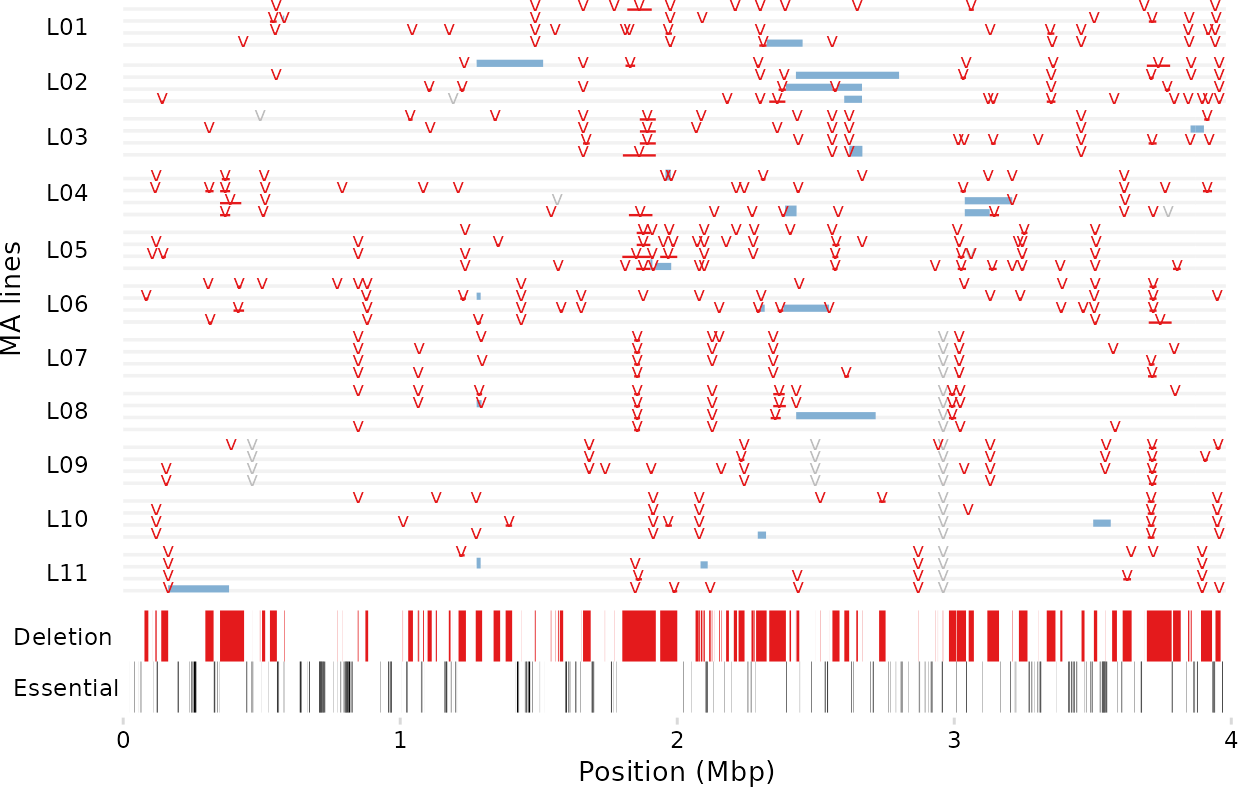

In [86]:
figure_name = file_prefix * "R06_deletion_intervals_asm20_G20"
@rput figure_name
R"""

# Custom labeller function
# Corrected custom labeller function
label_with_L <- function(labels) {
  # Prepends 'L' to each label
  labels <- paste0("L", labels)
  return(labels)
}

cpset1 <- RColorBrewer::brewer.pal(8, "Set1")

p <- plot_grid(
depth_interval_df_ %>% filter(Gen == "G20") %>%
ggplot() +
geom_rect(aes(xmin = start_fix/1e6, xmax = end_fix/1e6, ymin = ymin, ymax = ymax, fill = fill, alpha = alpha)) +
scale_fill_manual(values = c(cpset1[1], cpset1[2], "grey50"), guide="none", labels = c("Deletion", "Duplication", "Intact")) +
scale_color_manual(values = c(cpset1[1], cpset1[2], "grey50"), guide="none") +
scale_alpha_continuous(guide = "none") + 
# grey v for non-IS deletions
geom_point(data = depth_interval_df_ %>% filter(Gen == "G20")%>% filter(depth == 0, is_start == -1, is_end == -1),
aes(x = (start_fix + end_fix)/2 / 1e6, y = ymin + 0.4), size = 2.4, shape = "v", color = "grey") +  #'\u2304') + # DEL MARKER
# red v for IS deletions
geom_point(data =  depth_interval_df_ %>% filter(Gen == "G20") %>% filter(depth == 0, is_start != -1 | is_end != -1),
aes(x = (start_fix + end_fix)/2 / 1e6, y = ymin + 0.4, color = fill), size = 2.4, shape = "v") +  #'\u2304') + # DEL MARKER
theme_minimal_hgrid(10) + 
facet_grid(Parent~., switch = "y", scales = "free_y", space = "free_y", labeller = labeller(Parent = label_with_L)) +
ylim(-0.2,NA)+
scale_y_continuous(expand = c(0.0,0.5)) +
scale_x_continuous(expand = c(0,0.1), breaks = c(0,1,2,3,4), lim = c(0,4)) +
theme(axis.text.y=element_blank(), panel.margin.y = unit(0.005, "inch"),
strip.text.y.left = element_text(angle=0), axis.ticks.y = element_blank(),
panel.grid.major.y = element_blank(), panel.grid.minor.y = element_blank(),
axis.line=element_blank()) +
labs(x = "Position (Mbp)", y = "MA lines") 
+ theme(panel.margin.x=unit(0.2, "lines")) + theme(plot.margin = unit(c(0, 0, 0, 0), "cm")) +
theme(axis.ticks.x = element_blank(), axis.text.x = element_blank(), axis.title.x = element_blank(), legend.position = "none"),

p4.asm20.4 + theme(panel.margin.x=unit(0.4, "lines"),plot.margin = unit(c(0, 0, 0, 0), "cm"),
	axis.text.y = element_text(hjust = 0, margin = margin(l=0, r=-0.4, unit = "cm"))
)
, ncol = 1, rel_heights = c(1, 0.3), align = "hv", axis = "lr")
ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=160, height=160, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=160, height=160, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

In [87]:
R"""
depth_interval_df_ %>% pull(Gen) %>% unique
"""

RObject{StrSxp}
[1] "FACS" "G08"  "G20" 


┌ Warning: RCall.jl: Scale for y is already present.
│ Adding another scale for y, which will replace the existing scale.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


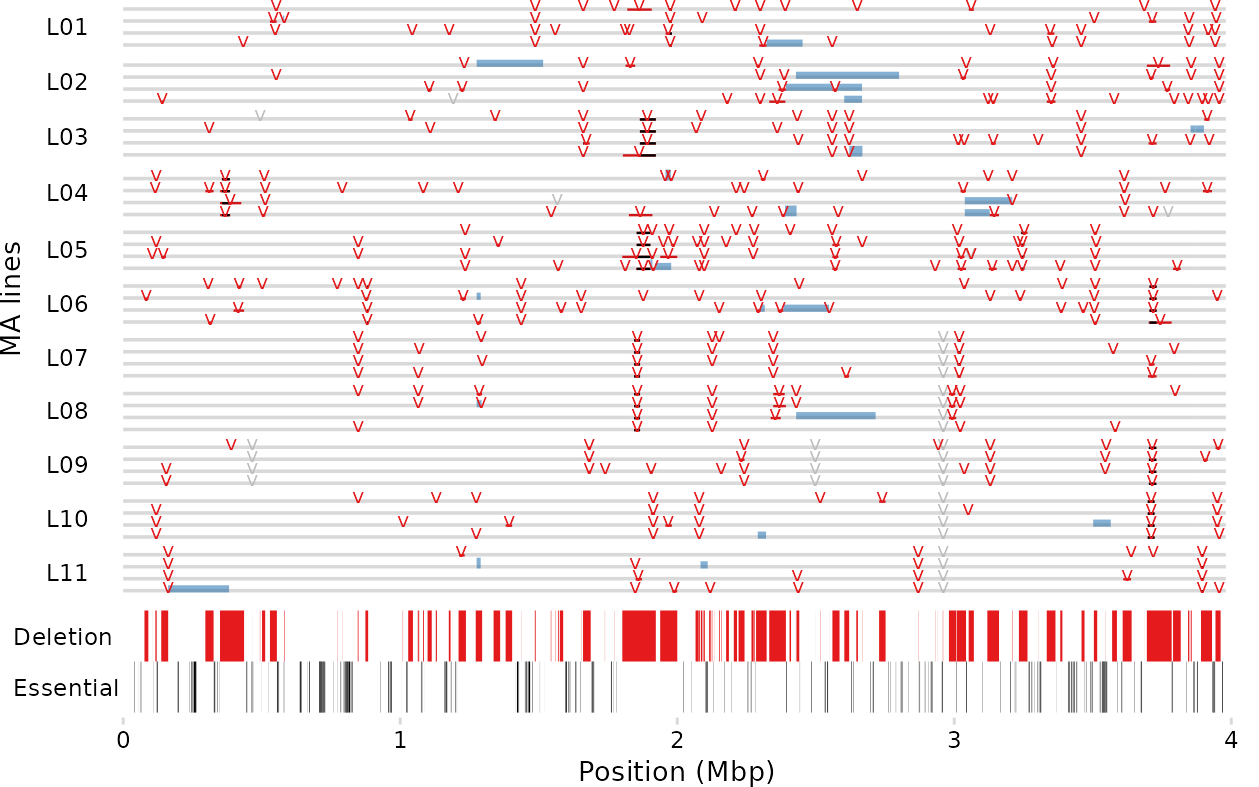

In [88]:
# show loci that were deleted before MA
figure_name = file_prefix * "R06_deletion_intervals_asm20_G20_minusAnc"
@rput figure_name
R"""
p <- plot_grid(
depth_interval_df_ %>% filter(Gen == "G20") %>%
ggplot() +
geom_rect(aes(xmin = start_fix/1e6, xmax = end_fix/1e6, ymin = ymin, ymax = ymax, fill = fill, alpha = alpha)) +
scale_fill_manual(values = c(cpset1[1], cpset1[2], "grey50"), guide="none", labels = c("Deletion", "Duplication", "Intact")) +
scale_color_manual(values = c(cpset1[1], cpset1[2], "grey50"), guide="none") +
scale_alpha_continuous(guide = "none") + 
# overlay preexisting SVs
geom_rect(data = depth_interval_df_ %>% filter(Gen == "FACS"),
	aes(xmin = start_fix/1e6, xmax = end_fix/1e6, ymin = ymin, ymax = ymax, alpha = alpha),
	fill = "black") +
# grey v for non-IS deletions
geom_point(data = depth_interval_df_ %>% filter(Gen == "G20")%>% filter(depth == 0, is_start == -1, is_end == -1),
aes(x = (start_fix + end_fix)/2 / 1e6, y = ymin + 0.4), size = 2.4, shape = "v", color = "grey") +  #'\u2304') + # DEL MARKER
# red v for IS deletions
geom_point(data =  depth_interval_df_ %>% filter(Gen == "G20") %>% filter(depth == 0, is_start != -1 | is_end != -1),
aes(x = (start_fix + end_fix)/2 / 1e6, y = ymin + 0.4, color = fill), size = 2.4, shape = "v") +  #'\u2304') + # DEL MARKER
theme_minimal_hgrid(10) + 
facet_grid(Parent~., switch = "y", scales = "free_y", space = "free_y", labeller = labeller(Parent = label_with_L)) +
ylim(-0.2,NA)+
scale_y_continuous(expand = c(0.0,0.5)) +
scale_x_continuous(expand = c(0,0.1), breaks = c(0,1,2,3,4), lim = c(0,4)) +
theme(axis.text.y=element_blank(), panel.margin.y = unit(0.005, "inch"),
strip.text.y.left = element_text(angle=0), axis.ticks.y = element_blank(),
panel.grid.major.y = element_blank(), panel.grid.minor.y = element_blank(),
axis.line=element_blank()) +
labs(x = "Position (Mbp)", y = "MA lines") 
+ theme(panel.margin.x=unit(0.2, "lines")) + theme(plot.margin = unit(c(0, 0, 0, 0), "cm")) +
theme(axis.ticks.x = element_blank(), axis.text.x = element_blank(), axis.title.x = element_blank(), legend.position = "none"),

p4.asm20.4 + theme(panel.margin.x=unit(0.4, "lines"),plot.margin = unit(c(0, 0, 0, 0), "cm"),
	axis.text.y = element_text(hjust = 0, margin = margin(l=0, r=-0.4, unit = "cm"))
)
, ncol = 1, rel_heights = c(1, 0.3), align = "hv", axis = "lr")
ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=160, height=160, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=160, height=160, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

### DAT: DELETION locus and ESS G20

## Deleted gene analysis

In [89]:
@rget gene_list
deleted_genes_df = DataFrame()
# for each deletion interval, find genes that are deleted
for int_ in eachrow(depth_interval_df[depth_interval_df.depth .== 0,:])
	del_genes_ = gene_list[(gene_list.end_ori_shift .> int_.start_fix) .& (gene_list.start_ori_shift .< int_.end_fix),:]
	new_dat_ = crossjoin(DataFrame(int_), select(del_genes_, Not([:start, :end, :length])), makeunique=true)
	deleted_genes_df = vcat(deleted_genes_df, new_dat_)
end
first(deleted_genes_df, 10)

Row,group,start,end,depth,length,start_fix,end_fix,is_start,is_end,line,Parent,Subline,gen_id,Gen,gene,strand,bnumber,ECK_id,Insertion Index Score,Log Likelihood Ratio,Essential,Non-essential,Unclear,start_ori_shift,end_ori_shift,Essential_PEC
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,String,Int64,Int64,String,String,Float64,String,String,Float64?,Float64?,Bool?,Bool?,Bool?,Float64,Float64,Bool?
1,2.0,1.48524e6,1.4859e6,0.0,668.0,1.48833e6,1.489e6,6.0,7.0,L01-1,L01,1,1,FACS,ycbS,1.0,b0940,ECK0931,0.251057,19.9825,false,true,false,1.48742e6,1.49002e6,false
2,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,dmsD,1.0,b1591,ECK1586,0.104065,5.445,false,true,false,1.97156e6,1.97217e6,false
3,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,clcB,1.0,b1592,ECK1587,0.122514,7.61804,false,true,false,1.97237e6,1.97362e6,false
4,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,ynfK,-1.0,b1593,ECK1588,0.130747,8.53625,false,true,false,1.97358e6,1.97427e6,false
5,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,dgsA,-1.0,b1594,ECK1589,0.11466,6.71431,false,true,false,1.9744e6,1.97562e6,false
6,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,ynfL,-1.0,b1595,ECK1590,0.136465,9.15831,false,true,false,1.97575e6,1.97664e6,false
7,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,ynfM,1.0,b1596,ECK1591,0.167464,12.3496,false,true,false,1.97675e6,1.978e6,false
8,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,asr,1.0,b1597,ECK1592,0.200647,15.5122,false,true,false,1.97843e6,1.97874e6,false
9,4.0,1.96847e6,1.9777e6,0.0,9234.0,1.97156e6,1.98079e6,8.0,9.0,L01-1,L01,1,1,FACS,ydgD,1.0,b1598,ECK1593,0.149635,10.5483,false,true,false,1.97901e6,1.97983e6,false


In [90]:
# these are possibly TRADIS false positives
df_ = deleted_genes_df[.!ismissing.(deleted_genes_df.Essential),:]
df_[df_.Essential .== true, :].gene |> unique

7-element Vector{String}:
 "yncH"
 "yddL"
 "dcd"
 "ygeF"
 "ygeG"
 "tktA"
 "lpxL"

## Deletion size distributions

### Decide minimal  deletion
Since all deletions detected in FACS generatios are incorporated within the deletions detected in the whole population, I decided to use the deletion size 100bp as the minimal size of deletion. 

In [91]:
R"""
depth_interval_df %>% filter(depth !=1, gen_id == 1) %>% distinct(start,end, .keep_all = TRUE)  %>% arrange(length)
"""

RObject{VecSxp}
# A tibble: 33 × 14
   group   start     end depth length start_fix end_fix is_start is_end line 
   <dbl>   <dbl>   <dbl> <dbl>  <dbl>     <dbl>   <dbl>    <dbl>  <dbl> <chr>
 1     2  466506  466617     0    112    466506  466617       -1     -1 L09-1
 2     6 2497144 2497256     0    113   2500236 2500348       -1     -1 L09-1
 3     6 2095602 2095740     0    139   2098694 2098832        9     10 L05-1
 4     8 2617813 2617964     0    152   2620905 2621056       11     12 L03-1
 5     2 1235413 1235791     0    379   1235413 1235791        2      3 L05-1
 6     4  512113  512507     0    395    512113  512507        4      5 L04-1
 7     4 1434920 1435339     0    420   1438012 1438431        6      7 L06-1
 8     8 3009263 3009700     0    438   3012355 3012792       12     13 L05-1
 9     4 2239043 2239487     0    445   2242135 2242579        8      9 L09-1
10     4 2077286 2077774     0    489   2080378 2080866        7      8 L10-1
# ℹ 23 more rows
# ℹ 4 more 

In [92]:
R"""
depth_interval_df.evo <- read_csv(file.path(base_dir, "export/classify_IS_events/depth_interval.csv"))
depth_interval_df.evo <- depth_interval_df.evo %>% filter(length >= min_del_threshold) %>%
	filter(!((line == "L04-1") & (gen_id == 3))) 
"""

┌ Warning: RCall.jl: Rows: 914 Columns: 11
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr  (1): line
│ dbl (10): group, start, end, depth, length, start_fix, end_fix, is_start, is...
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 889 × 11
   group   start     end depth  length start_fix end_fix is_start is_end line 
   <dbl>   <dbl>   <dbl> <dbl>   <dbl>     <dbl>   <dbl>    <dbl>  <dbl> <chr>
 1     1       1  549437     1  549437         1  552530       -1      3 L01-1
 2     2  549438  554384     0    4947    552531  560570        3      6 L01-1
 3     3  554385 1934345     1 1379961    560571 1952959        6     16 L01-1
 4     4 1934346 1967835     2   33490   1952960 1991112       16     17 L01-1
 5     5 1967836 2633390     1  665555   1991113 2661330       17     21 L01-1
 6     6 2633391 2637598     0    4208   2661331 2665538       21     22 L01-1
 7     7 2637599 3965065     1 1327467   2665539 4003851       22     -1 L01-1
 8     1       1  548961     1  548961         1  552053       -1      3 L01-1
 9     2  548962  549423     0     462    552054  552515        3      4 L01-1
10     3  549424 1651475     1 1102052    555609 1676262        4     18 L01-1
# ℹ 879 more ro

┌ Warning: RCall.jl: 
│ Attaching package: ‘ggh4x’
│ 
│ The following objects are masked from ‘package:lemon’:
│ 
│     GeomPointPath, geom_pointpath
│ 
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning: `expand_scale()` was deprecated in ggplot2 3.3.0.
│ ℹ Please use `expansion()` instead.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


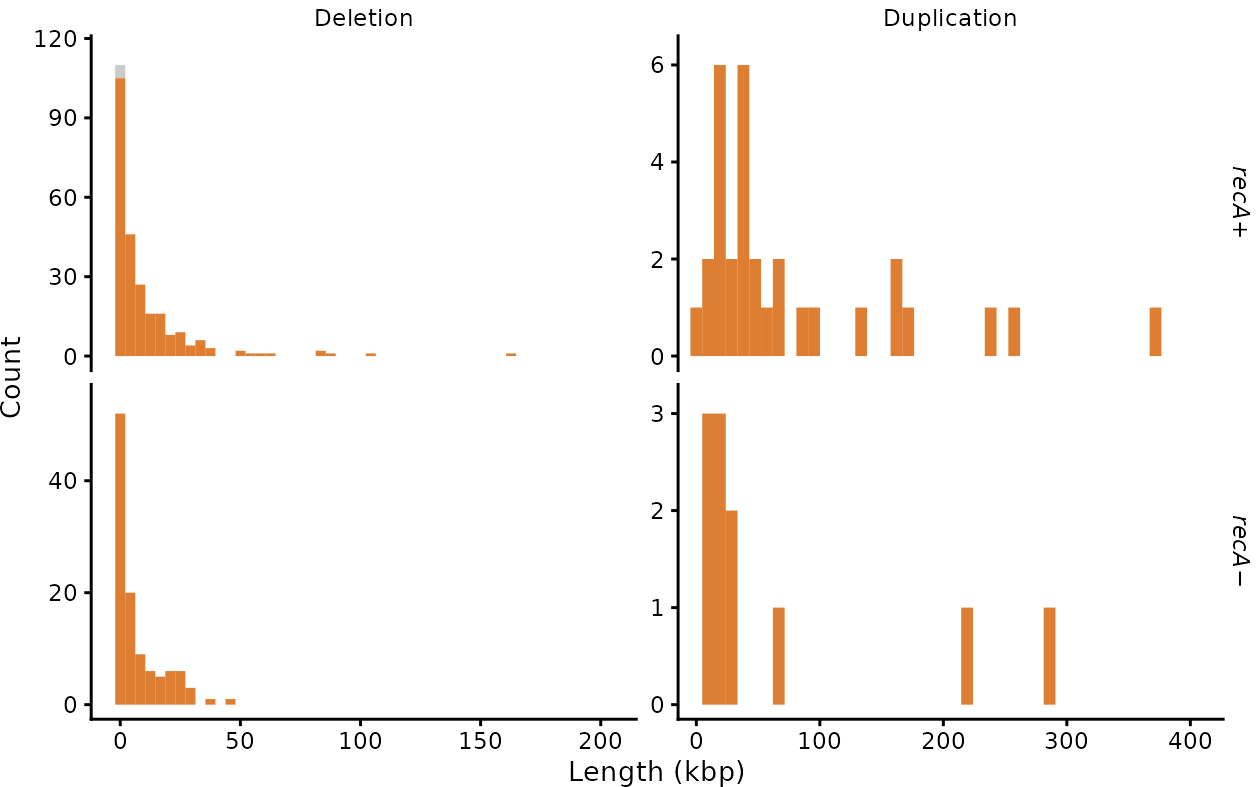

In [93]:
# based on depth interval
# note that duplications are defined like rieman integrals and not as in lebesgue.

figure_name = file_prefix * "Del-Dup_length_histogram"
@rput figure_name
R"""
library(ggh4x)
cpset1 <- RColorBrewer::brewer.pal(8, "Set1")
p <- depth_interval_df.evo %>%
filter(!((line == "L04-1") & (gen_id == 3))) %>%
filter(depth != 1) %>%
mutate(RecA = ifelse(as.numeric(str_sub(line, start=2, end = 3))<=6, "recA+", "recA\U2212")) %>%
mutate(IS = ifelse(is_start != -1 | is_end != -1, "IS", "Non-IS")) %>%
mutate(IS = factor(IS, levels = c("Non-IS", "IS"))) %>%
mutate(Type = ifelse(depth == 0, "Deletion", "Duplication")) %>%
ggplot(aes(x = length/1e3, fill = IS)) +
geom_histogram(bins = 40, position = "stack", alpha = 0.8) +
facet_grid2(RecA~Type, scale= "free", independent = "y", labeller = label_bquote(italic(.(RecA)), .(Type))) +
#facet_wrap(~RecA+Type, scale= "free", labeller = label_bquote(cols = list(italic(.(RecA)), .(Type)))) +
theme_half_open(10) +
scale_y_continuous(expand = expand_scale(mult = c(.05, .1))) +
scale_x_continuous(expand = expand_scale(add = c(10, 50))) +
#scale_fill_manual(values = c("grey", cpset1[1])) +
# d65e00cc
scale_fill_manual(values = c("grey", "#d65e00cc")) +
labs(x = "Length (kbp)", y = "Count") +
theme(strip.background = element_blank(), legend.position = "none", plot.margin = unit(c(0,0,0,0), "cm"))

saveRDS(p, paste0(figure_export_dir,"/", figure_name, ".rds"))

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=70, height=50, units="mm", dpi=1000, device = cairo_pdf)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=70, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))


In [94]:
R"""
depth_interval_df.evo %>% filter(depth > 1) %>% select(-start, -end) %>% data.frame %>% head
"""

RObject{VecSxp}
  group depth length start_fix end_fix is_start is_end  line gen_id
1     4     2  33490   1952960 1991112       16     17 L01-1      2
2     4     2  16166    571296  587461        6      7 L01-2      2
3     4     2 129960   2317293 2447252       26     28 L01-4      3
4    10     4  19158   3829926 3855278       35     37 L02-1      2
5     4     2 240168   1282160 1522327        9     12 L02-1      3
6    10     2  16503   3810331 3829926       35     37 L02-2      2


In [95]:
R"""
comment_header <- c(
	paste("# `is_start`: the ID of IS corresponding to the start of the interval. -1 if no corresponding IS."),
	paste("# Data of {L04-1, gen3} is removed from the main analyses due to sequence divergence between G08 and G20,",
		"making analyese unreliable.")
	)
out_dir <- file.path(data_export_dir, paste0(file_prefix, "depth_interval.csv"))
write_lines(comment_header, out_dir)
read_csv(file.path(base_dir, "export/classify_IS_events/depth_interval.csv")) %>%
#depth_interval_df.evo %>%
filter(depth != 1) %>% select(-group, -start, -end) %>%
	rename(start = start_fix, end = end_fix) %>%
	write_csv(out_dir, append = TRUE, col_names = TRUE)
""";

┌ Warning: RCall.jl: Rows: 914 Columns: 11
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr  (1): line
│ dbl (10): group, start, end, depth, length, start_fix, end_fix, is_start, is...
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


### STAT: Deletion size

In [96]:
println("ALL SV")
R"depth_interval_df.evo %>% filter(depth != 1) %>% pull(length) %>% summary %>% print"
println("DUP")
R"""depth_interval_df.evo %>%
filter(!((line == "L04-1") & (gen_id == 3))) %>%
filter(depth > 1) %>% pull(length) %>% summary %>% print"""
println("DEL")
R"depth_interval_df.evo %>% filter(depth < 1) %>% pull(length) %>% summary %>% print"
println("<100")
R"depth_interval_df.evo %>% filter(depth != 1, length < 100) %>% pull(length) %>% summary %>% print"
println("100-200")
R"depth_interval_df.evo %>% filter(depth != 1, length >= 100, length<200) %>% pull(length) %>% length %>% print"
println("<500")
R"depth_interval_df.evo %>% filter(depth != 1, length < 500) %>% pull(length) %>% length %>% print";

ALL SV
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   102.0    837.5   4222.5  15897.9  16431.0 372360.0 
DUP
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    559   16853   36705   73460   83902  372360 
DEL
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    102     744    2743    9256   11774  162795 
<100
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
                                                
100-200
[1] 21
<500
[1] 65


In [97]:
R"""
# To specifically find and print min and max we can use min and max functions
min_length <- min(depth_interval_df.evo %>% filter(depth < 1) %>% pull(length))
max_length <- max(depth_interval_df.evo %>% filter(depth < 1) %>% pull(length))

# Printing min and max
depth_interval_df.evo %>% filter(length %in% c(min_length, max_length))
"""

RObject{VecSxp}
# A tibble: 3 × 11
  group   start     end depth length start_fix end_fix is_start is_end line 
  <dbl>   <dbl>   <dbl> <dbl>  <dbl>     <dbl>   <dbl>    <dbl>  <dbl> <chr>
1     8 2283109 2283210     0    102   2306386 2311150       19     20 L01-2
2     2 1875054 2037848     0 162795   1912159 2074953       26     28 L04-3
3    21 3746970 3747071     0    102   3815018 3815119       -1     -1 L04-4
# ℹ 1 more variable: gen_id <dbl>


In [98]:
#Deletion count and IS related
R"""
depth_interval_df.evo %>%
mutate(Depth = ifelse(depth > 1, 2, depth)) %>% 
mutate(IS = ifelse(is_start != -1 | is_end != -1, "IS", "Non-IS")) %>%
group_by(Depth, IS) %>%
summarise(n = n(), median = median(length))
"""

┌ Warning: RCall.jl: `summarise()` has grouped output by 'Depth'. You can override using the
│ `.groups` argument.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 5 × 4
# Groups:   Depth [3]
  Depth IS         n median
  <dbl> <chr>  <int>  <dbl>
1     0 IS       359   3180
2     0 Non-IS     5    109
3     1 IS       473 427637
4     1 Non-IS    10 936492
5     2 IS        42  36705


# Analysis using SV_df

In [99]:
R"""
sv.df <- read_csv(file.path(base_dir, "export/classify_IS_events/sv_df.csv"))
head(sv.df)
"""

┌ Warning: RCall.jl: Rows: 1049 Columns: 43
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr (23): chr1, REF, ALT, chr2, start2, end2, ID, parent, SVTYPE, MISC, star...
│ dbl (20): start1, end1, start1_is_rm, end1_is_rm, start1_is, end1_is, start2...
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 6 × 43
  chr1    start1   end1 REF   ALT   chr2  start2 end2  ID    parent SVTYPE MISC 
  <chr>    <dbl>  <dbl> <chr> <chr> <chr> <chr>  <chr> <chr> <chr>  <chr>  <chr>
1 contig… 5.53e5 5.61e5 -     -     cont… 552515 5525… DEL1  SYN1   DEL    -    
2 contig… 7.11e5 7.11e5 C     CGCG… cont… 706499 7065… INS80 SYN1   INS    -    
3 contig… 1.19e6 1.21e6 -     -     cont… 11906… 1203… INV3  -      INV    -    
4 contig… 1.68e6 1.68e6 T     TCAG… cont… 16768… 1676… INS1… SYN2   INS    -    
5 contig… 1.95e6 1.95e6 T     TCGG… cont… 19573… 1957… INS2… SYN2   INS    -    
6 contig… 1.95e6 1.99e6 -     -     cont… 19573… 2035… CPG2  SYN2   CPG    -    
# ℹ 31 more variables: start1_is_rm <dbl>, end1_is_rm <dbl>,
#   start2_is_rm <chr>, end2_is_rm <chr>, start1_is <dbl>, end1_is <dbl>,
#   start2_is <dbl>, end2_is <dbl>, SVLEN_ISDEL <dbl>, start1_fixed <dbl>,
#   end1_fixed <dbl>, start2_fixed <chr>, end2_fixed <chr>,
#   start1_is_status <chr>, start1_is_status_ri

## Inversion Stat 

In [100]:
R"""
sv.df %>% filter(SVTYPE == "INV") %>%
# remove artifact due to sequence dievergence between G08 and G20
filter(!((Line == "L05-4") & gen_id == 3 & ID == "INV5"), !((Line == "L04-1" & gen_id == 3 & ID == "INV2"))) %>%
mutate(recA = ifelse(as.numeric(str_sub(Line, start=2, end = 3))<=6, "recA+", "recA-")) %>%
#cnt min max mean median
summarise(cnt = n(), min = min(SVLEN_fixed), max = max(SVLEN_fixed), mean = mean(SVLEN_fixed), median = median(SVLEN_fixed),
	recAP = sum(recA == "recA+"), recAM = sum(recA == "recA-")) 
"""


RObject{VecSxp}
# A tibble: 1 × 7
    cnt   min     max    mean median recAP recAM
  <int> <dbl>   <dbl>   <dbl>  <dbl> <int> <int>
1    54  2174 1719098 225789.  83548    42    12


## FIG: SV length and angle

In [101]:
R"""
sv.df %>% pull(SVTYPE) %>% unique
"""

RObject{StrSxp}
 [1] "DEL"   "INS"   "INV"   "CPG"   "CPL"   "INVTR" "HDR"   "INVDP" "DUP"  
[10] "TRANS" "TDM"  


┌ Warning: RCall.jl: Warning in FUN(X[[i]], ...) : NaNs produced
│ Warning in FUN(X[[i]], ...) : NaNs produced
│ Warning: Removed 30 rows containing missing values (`geom_point()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning in FUN(X[[i]], ...) : NaNs produced
│ Warning in FUN(X[[i]], ...) : NaNs produced
│ Warning: Removed 30 rows containing missing values (`geom_point()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning in FUN(X[[i]], ...) : NaNs produced
│ Warning in FUN(X[[i]], ...) : NaNs produced
│ Warning: Removed 30 rows containing missing values (`geom_point()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


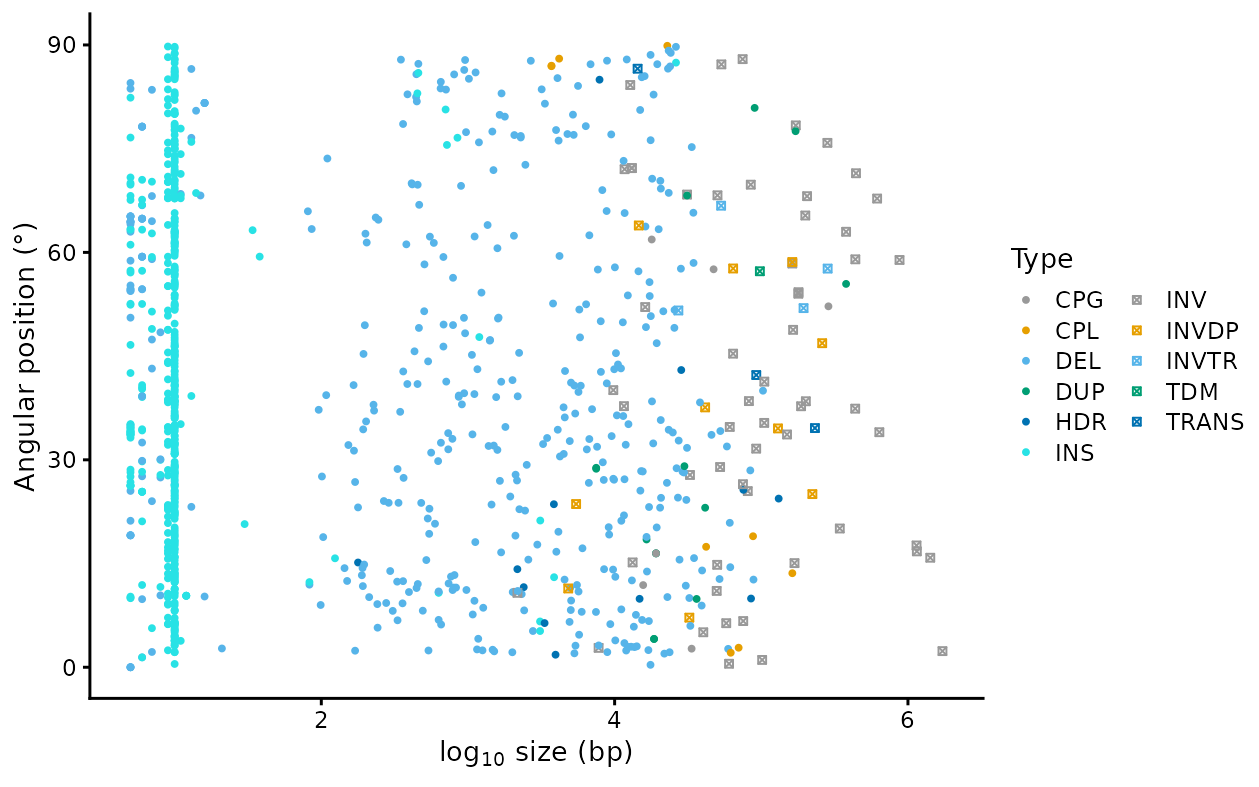

In [102]:
# size and pos
figure_name = file_prefix * "SVLEN_Angle"
@rput figure_name
R"""
p <- sv.df %>% mutate(angle = (start1 + end1)/2/genome_size * 360) %>% 
	mutate(angle = ifelse(angle > 180, angle - 360, angle)) %>%
	mutate(angle = ifelse(abs(angle)>90, angle + 180 * ifelse(angle > 0, -1, 1), angle)) %>%
	ggplot(aes(x = log10(SVLEN_fixed), y = abs(angle), color = SVTYPE, shape = SVTYPE)) +
	geom_point(size = 1) +
	#scale_shape_manual(values = c(rep(c(16, 7), each = 5), 16), name = "Type") +
	scale_shape_manual(values = c(rep(16,6), rep(7,5)), name = "Type") +
	scale_color_manual(values = c(cbp[c(1:4, 6)], 5, cbp[c(1:4, 6)]), name = "Type") +
	theme_half_open(10) +
	labs(x = expression('log'[10]*' size (bp)'), y = "Angular position (°)") +
	guides(shape = guide_legend(ncol=2)) +
	theme(legend.spacing = unit(0.01, "cm"), ) +
	scale_y_continuous(lim = c(0,90), breaks = c(0, 30, 60, 90)) 

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=90, height=50, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=90, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))


In [103]:
R"""
sv.df %>% filter(SVTYPE == "INV") %>%
mutate(recA = ifelse(as.numeric(str_sub(Line, start=2, end = 3))<=6, "recA+", "recA-")) %>%
summarise(recAP = sum(recA == "recA+"), recAM = sum(recA == "recA-"))
"""

RObject{VecSxp}
# A tibble: 1 × 2
  recAP recAM
  <int> <int>
1    44    12


### Fig : Inversion distance

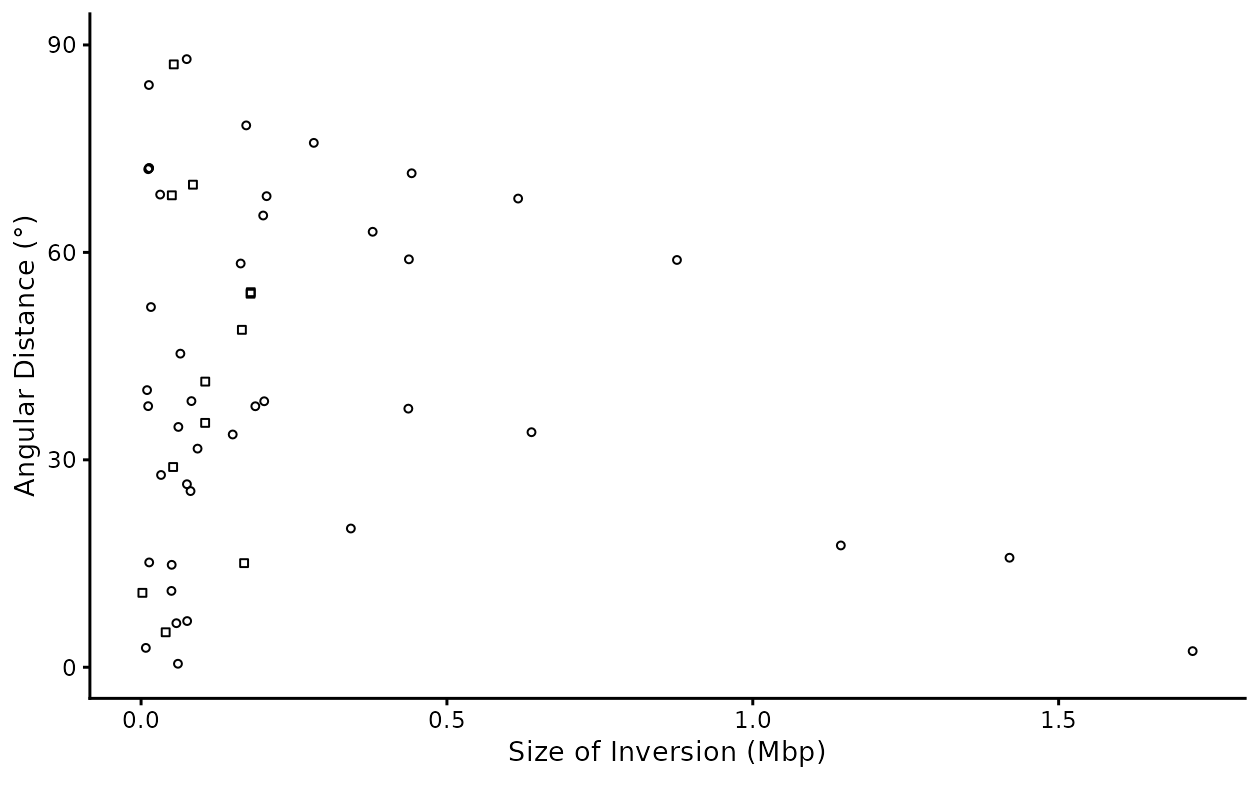

In [104]:
figure_name = file_prefix * "SVLEN_Angle_linear"
@rput figure_name
R"""
p <- sv.df %>% mutate(angle = (start1 + end1)/2/genome_size * 360) %>% 
	mutate(angle = ifelse(angle > 180, angle - 360, angle)) %>%
	mutate(angle = ifelse(abs(angle)>90, angle + 180 * ifelse(angle > 0, -1, 1), angle)) %>%
	filter(SVTYPE == "INV") %>% 
	# remove artifact due to sequence divergence between G08 and G20
	filter(!((Line == "L05-4") & gen_id == 3 & ID == "INV5"), !((Line == "L04-1" & gen_id == 3 & ID == "INV2"))) %>%
	mutate(recA = ifelse(as.numeric(str_sub(Line, start=2, end = 3))<=6, "recA+", "recA-")) %>%
	ggplot(aes(x = (SVLEN_fixed / 1e6), y = abs(angle), color = SVTYPE, shape = recA)) +
	geom_point(size = 1, color = "black") +
	scale_shape_manual(values = c(1,0), name = "Type") +
	theme_half_open(10) +
	labs(x = expression('Size of Inversion (Mbp)'), y = "Angular Distance (°)") +
	guides(shape = guide_legend(ncol=2)) +
	theme(legend.spacing = unit(0.01, "cm"), legend.position = "none") +
	scale_y_continuous(lim = c(0,90), breaks = c(0, 30, 60, 90)) 

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=60, height=50, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=60, height=50, units="mm", dpi=1000)
saveRDS(p, paste0(figure_export_dir,"/", figure_name, ".rds"))
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))


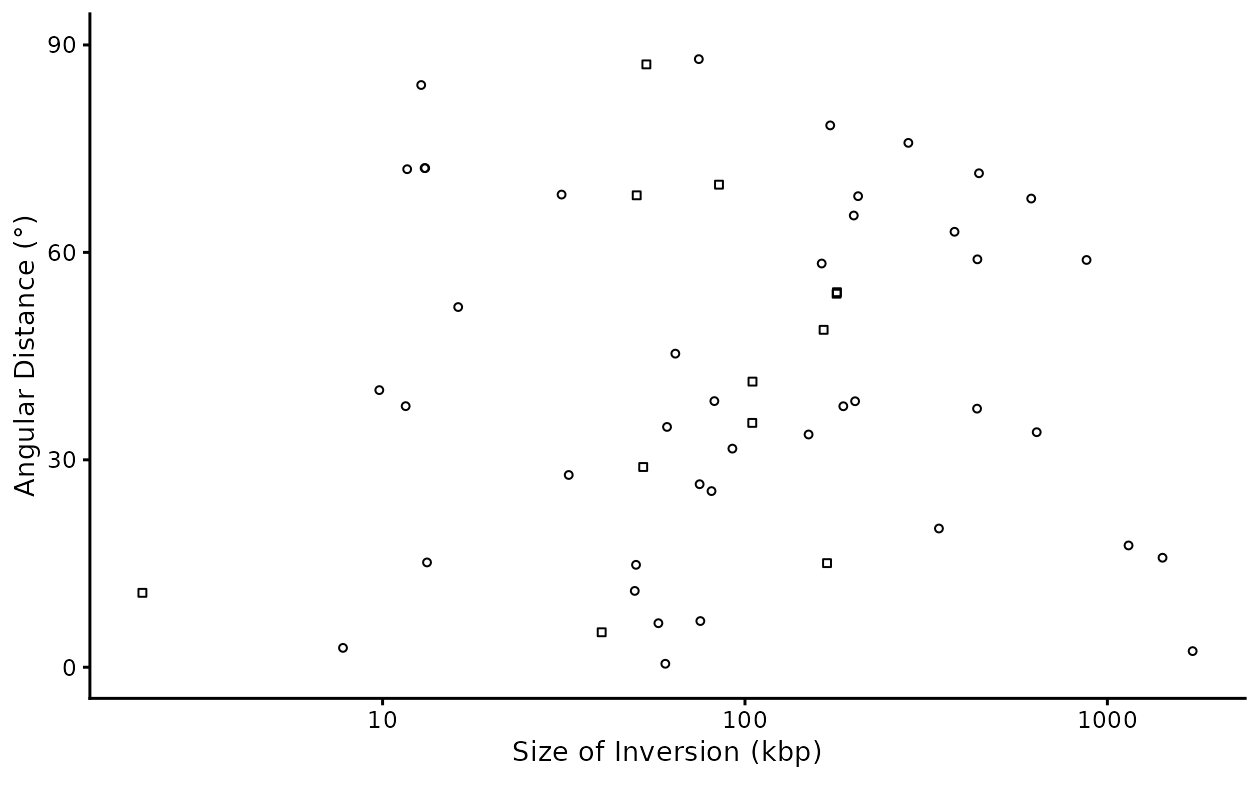

In [105]:
figure_name = file_prefix * "SVLEN_Angle_log"
@rput figure_name
R"""
p <- sv.df %>% mutate(angle = (start1 + end1)/2/genome_size * 360) %>% 
		mutate(angle = ifelse(angle > 180, angle - 360, angle)) %>%
		mutate(angle = ifelse(abs(angle)>90, angle + 180 * ifelse(angle > 0, -1, 1), angle)) %>%
		filter(SVTYPE == "INV") %>% 
		# remove artifact due to sequence divergence between G08 and G20
		filter(!((Line == "L05-4") & gen_id == 3 & ID == "INV5"), !((Line == "L04-1" & gen_id == 3))) %>%
		mutate(recA = ifelse(as.numeric(str_sub(Line, start=2, end = 3))<=6, "recA+", "recA-")) %>%
	ggplot(aes(x = (SVLEN_fixed / 1e3), y = abs(angle), color = SVTYPE, shape = recA)) +
	geom_point(size = 1, color = "black") +
	scale_shape_manual(values = c(1,0), name = "Type") +
	theme_half_open(10) +
	labs(x = expression('Size of Inversion (kbp)'), y = "Angular Distance (°)") +
	guides(shape = guide_legend(ncol=2)) +
	theme(legend.spacing = unit(0.01, "cm"), legend.position = "none") +
	scale_x_log10() +
	scale_y_continuous(lim = c(0,90), breaks = c(0, 30, 60, 90)) 

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=60, height=50, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=60, height=50, units="mm", dpi=1000)
saveRDS(p, paste0(figure_export_dir,"/", figure_name, ".rds"))
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))


### DAT: Inversion distance

In [106]:
R"""
comment_header <- c(
	paste("# `start1_IS`: The IS insertion site cluster ID in terms of the reference genome that",
		"corresponds to the start locus of the inversion"),
	paste("# {L05-4, gen3, INV5} and {L04-1, gen3, INV2} are removed from the plot because",
		"it is likely a false reversal of a large inversion due to sequence divergence between G08 and G20.",
		"See the Overview Fig. to see the repeated inversion that I am reffering to.")
	)
out_dir <- file.path(data_export_dir, paste0(file_prefix, "inv_dist.csv"))
write_lines(comment_header, out_dir)
sv.df %>% mutate(angle = (start1 + end1)/2/genome_size * 360) %>% 
	mutate(angle = ifelse(angle > 180, angle - 360, angle)) %>%
	mutate(angle = ifelse(abs(angle)>90, angle + 180 * ifelse(angle > 0, -1, 1), angle)) %>%
	filter(SVTYPE == "INV") %>% 
	# remove artifact due to sequence divergence between G08 and G20
	#filter(!((Line == "L05-4") & gen_id == 3 & ID == "INV5"), !((Line == "L04-1" & gen_id == 3 & ID == "INV2"))) %>%
	mutate(recA = ifelse(as.numeric(str_sub(Line, start=2, end = 3))<=6, "recA+", "recA-")) %>%
	select(Line, gen_id, ID, SVLEN_fixed, angle, recA, start = start1_fixed, end = end1_fixed,
		start1_IS = start1_is, end1_IS = end1_is, start2_IS = start2_is, end2_IS = end2_is) %>%
	write_csv(out_dir, append = TRUE, col_names = TRUE)
""";

### STAT: Mean Insertion events

In [107]:
R"""
genome_stats_df.iscn.stats <- genome_stats_df.iscn %>%
group_by(Source, Generations) %>%
summarise(Insertion.mean = mean(Insertion), Insertion.sd = sd(Insertion), Insertion.sum = sum(Insertion), Insertion.min = min(Insertion), Insertion.max = max(Insertion))
print("IS cumulative insertions")
print(genome_stats_df.iscn.stats %>% data.frame)
tmp.cn <- genome_stats_df.iscn %>% filter(Generations == 460) %>% pull(Insertion) %>% sum
print(paste("Total IS count at 540 generations:", tmp.cn, "mean:", tmp.cn/44))

genome_stats_df.isevent.stats <- genome_stats_df.isevent %>%
group_by(Source, Generations) %>%
summarise(ISevent.mean = mean(Event_CNT), ISevent.sd = sd(Event_CNT), ISevent.sum = sum(Event_CNT), ISevent.min = min(Event_CNT), ISevent.max = max(Event_CNT))
print("IS cumulative insertion sites")
print(genome_stats_df.isevent.stats %>% data.frame)
tmp.cn.site <- genome_stats_df.isevent.stats %>% filter(Generations == 460) %>%pull(ISevent.sum) %>% sum
print(paste("Total IS site count (new insertions) at 540 generations:", tmp.cn.site, "mean:", tmp.cn.site/44))
""";

[1] "IS cumulative insertions"
   Source Generations Insertion.mean Insertion.sd Insertion.sum Insertion.min
1 MA.RecA           1       0.000000     0.000000             0             0
2 MA.RecA         184       9.791667     2.669948           235             5
3 MA.RecA         460      15.833333     3.679162           380             9
4 MA.recA           1       0.000000     0.000000             0             0
5 MA.recA         184       3.450000     3.379115            69             0
6 MA.recA         460       6.750000     4.843607           135             0
  Insertion.max
1             0
2            16
3            23
4             0
5            12
6            17
[1] "Total IS count at 540 generations: 515 mean: 11.7045454545455"
[1] "IS cumulative insertion sites"
    Source Generations ISevent.mean ISevent.sd ISevent.sum ISevent.min
1 MA recA+           1           NA         NA          NA          NA
2 MA recA+         184       14.750   4.162462         354       

┌ Warning: RCall.jl: `summarise()` has grouped output by 'Source'. You can override using the
│ `.groups` argument.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: `summarise()` has grouped output by 'Source'. You can override using the
│ `.groups` argument.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


## FIG: IS ins pos (recA+)

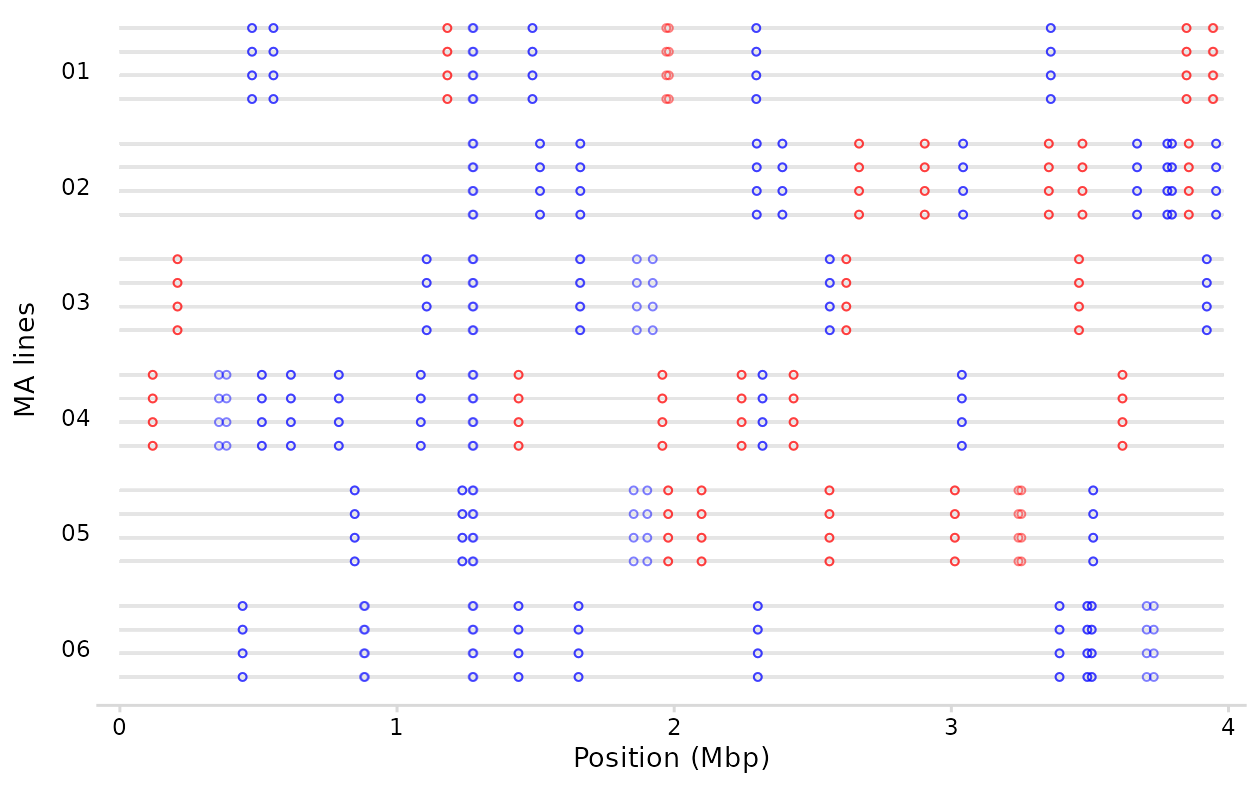

In [108]:
# if there are matched ISs in facs generations, then plot unfilled circle
figure_name = file_prefix * "IS_position_in_mds42_FACS"
@rput figure_name
R"""

tmp.df_ <- is_in_mds42.df.prevgen %>%
filter(Gen == "FACS") %>%
filter(as.numeric(Parent) <= 6) %>%
mutate(matched_row = is.na(matched_row.facs))

p <- 
data.frame(from = 1, to = ref_genome_size) %>% cross_join(tmp.df_ %>% select(Subline, Parent)) %>%
ggplot() +
geom_segment(aes(x = from/1e6, xend = to/1e6, y = 5- Subline, yend = 5- Subline), size = .5, color = "grey90") +
geom_point(data = tmp.df_, aes(x = pos/1e6, y = 5-Subline, shape = matched_row, alpha = matched_row, color = IS_strand), size = 1) +
scale_alpha_manual(values = c(0.5, 1)) +
scale_color_manual(values = c("blue", "red")) +
scale_shape_manual(values = c(1,16)) +
theme_minimal_hgrid(10) + 
scale_x_continuous(expand = c(0.02,0)) +
scale_y_continuous(limit = c(0.2, 4.2), expand = c(0.1,0), breaks = 1:4) +
facet_grid(rows = vars(Parent), scales = "free_y", switch = "y") +
theme(axis.text.y=element_blank(), legend.position = "none",  panel.margin.y = unit(0.05, "lines"),
strip.text.y.left = element_text(angle=0), axis.ticks.y = element_blank(), panel.grid.major = element_blank()) +
labs(x = "Position (Mbp)", y = "MA lines") 

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=80, height=50, units="mm", dpi=1000)
""";
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

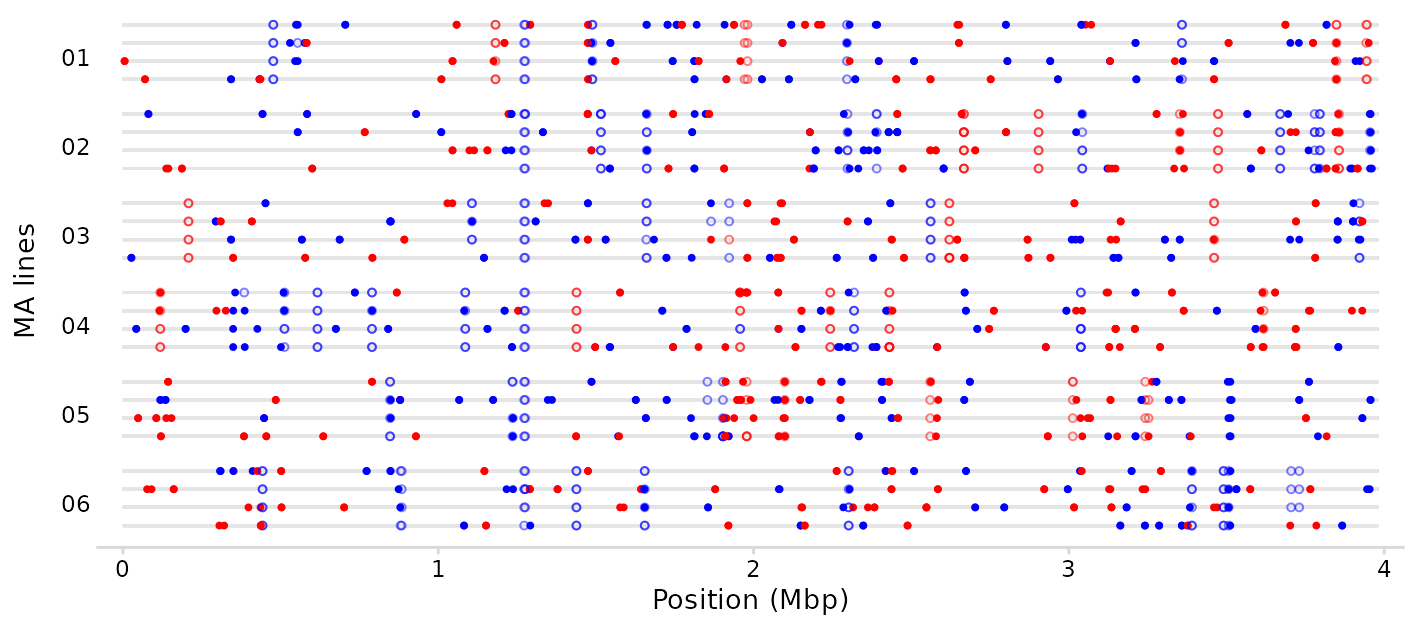

In [109]:
# if there are matched ISs in facs generations, then plot unfilled circle
figure_name = file_prefix * "IS_position_in_mds42_G08"
@rput figure_name
R"""

tmp.df_ <- is_in_mds42.df.prevgen %>%
filter(Gen == "MA08") %>%
filter(as.numeric(Parent) <= 6) %>%
mutate(matched_row = is.na(matched_row.facs))

p <- 
data.frame(from = 1, to = ref_genome_size) %>% cross_join(tmp.df_ %>% select(Subline, Parent)) %>%
ggplot() +
geom_segment(aes(x = from/1e6, xend = to/1e6, y = 5- Subline, yend = 5- Subline), size = .5, color = "grey90") +
geom_point(data = tmp.df_, aes(x = pos/1e6, y = 5-Subline, shape = matched_row, alpha = matched_row, color = IS_strand), size = 1) +
scale_alpha_manual(values = c(0.5, 1)) +
scale_color_manual(values = c("blue", "red")) +
scale_shape_manual(values = c(1,16)) +
theme_minimal_hgrid(10) + 
scale_x_continuous(expand = c(0.02,0)) +
scale_y_continuous(limit = c(0.2, 4.2), expand = c(0.1,0), breaks = 1:4) +
facet_grid(rows = vars(Parent), scales = "free_y", switch = "y") +
theme(axis.text.y=element_blank(), legend.position = "none",  panel.margin.y = unit(0.05, "lines"),
strip.text.y.left = element_text(angle=0), axis.ticks.y = element_blank(), panel.grid.major = element_blank()) +
labs(x = "Position (Mbp)", y = "MA lines") 

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=80, height=50, units="mm", dpi=1000)
""";

figure_name = file_prefix * "IS_position_in_mds42_G20"
@rput figure_name
R"""

tmp.df_ <- is_in_mds42.df.prevgen %>%
filter(Gen == "MA20") %>%
filter(as.numeric(Parent) <= 6) %>%
mutate(matched_row = is.na(matched_row.facs))

p <- 
data.frame(from = 1, to = ref_genome_size) %>% cross_join(tmp.df_ %>% select(Subline, Parent)) %>%
ggplot() +
geom_segment(aes(x = from/1e6, xend = to/1e6, y = 5- Subline, yend = 5- Subline), size = .5, color = "grey90") +
geom_point(data = tmp.df_, aes(x = pos/1e6, y = 5-Subline, shape = matched_row, alpha = matched_row, color = IS_strand), size = 1) +
scale_alpha_manual(values = c(0.5, 1)) +
scale_color_manual(values = c("blue", "red")) +
scale_shape_manual(values = c(1,16)) +
theme_minimal_hgrid(10) + 
scale_x_continuous(expand = c(0.02,0)) +
scale_y_continuous(limit = c(0.2, 4.2), expand = c(0.1,0), breaks = 1:4) +
facet_grid(rows = vars(Parent), scales = "free_y", switch = "y") +
theme(axis.text.y=element_blank(), legend.position = "none",  panel.margin.y = unit(0.05, "lines"),
strip.text.y.left = element_text(angle=0), axis.ticks.y = element_blank(), panel.grid.major = element_blank()) +
labs(x = "Position (Mbp)", y = "MA lines") 

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=180, height=80, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=80, height=50, units="mm", dpi=1000)
""";
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

## Comparison with Foster

In [110]:
R"""
genome_stats_df.isevent %>% rbind(fosterMA_) %>% rbind(c.f.3ab_) %>%
	filter(Generations > 100) %>%
	filter(Source != "LTEE") %>% filter(Source != "MA recA-") %>%
	arrange(Population, rev(Source)) %>%
	filter(Source == "MA recA+") %>% nrow
	"""

RObject{IntSxp}
[1] 48


In [111]:
R"""fosterMA %>%
mutate(Generations = generations * lines) %>%
mutate(Source = "Foster") %>%
select(Population = description, Generations, Source, Event_CNT = insertion_num)"""

RObject{VecSxp}
# A tibble: 16 × 4
   Population        Generations Source Event_CNT
   <chr>                   <dbl> <chr>      <dbl>
 1 WT @3Kgen              117040 Foster        21
 2 WT @6K gen             133476 Foster        39
 3 WT on min. medium      271304 Foster        83
 4 mutL                    12750 Foster        10
 5 umuDC dinB             237042 Foster        95
 6 umuDC dinB polB        266772 Foster       108
 7 uvr A                  146050 Foster        63
 8 alkA tag. A            230325 Foster        81
 9 ada ogt                294643 Foster       113
10 xthA nfo               126200 Foster        37
11 mutT                    14975 Foster         6
12 mut Y                   49300 Foster        14
13 nth nei                 46000 Foster         6
14 nfi                    182932 Foster        65
15 mut Y mutM              47900 Foster        17
16 <NA>                  2176720 Foster       758


## STAT: lm of Foster Data

In [112]:
R"""
foster.lm <- lm(Event_CNT ~ Generations + 0, data = fosterMA_ %>% filter(Event_CNT != 0))
foster.lm %>% summary %>% print
coefficients(foster.lm) %>% print
confint(foster.lm) %>% print
""";


Call:
lm(formula = Event_CNT ~ Generations + 0, data = fosterMA_ %>% 
    filter(Event_CNT != 0))

Residuals:
     Min       1Q   Median       3Q      Max 
-0.54637 -0.20452 -0.00943  0.16383  0.47333 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
Generations 3.568e-04  1.526e-05   23.38 1.28e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2815 on 14 degrees of freedom
Multiple R-squared:  0.975,	Adjusted R-squared:  0.9732 
F-statistic: 546.7 on 1 and 14 DF,  p-value: 1.282e-12

Generations 
0.000356819 
                   2.5 %       97.5 %
Generations 0.0003240877 0.0003895502


## Fig foster regression

In [113]:
## Import generation data
R"""
genome_stats_df.isevent <- genome_stats_df %>%
	mutate(Generations = map_int(gen_id, ~ MA_generations[.x]),
		Population = Prefix,
		Source = ifelse(RecA, "MA recA+", "MA recA-"),
		Event_CNT = new_cnt_anc) %>%
		select(Population, Generations, Event_CNT, Source)
genome_stats_df.isevent %>% head(2)
"""

RObject{VecSxp}
  Population Generations Event_CNT   Source
1      L01-1           1        NA MA recA+
2      L01-2           1        NA MA recA+


In [114]:
R"""
generation_df <- read_csv(file.path(base_dir, "misc/2305_Estimated_Generations.csv")) %>%
	pivot_longer(cols = -Line, names_to = "gen_id", values_to = "Generations.measured") %>%
	mutate(gen_id = ifelse(gen_id == "Gen8", 2, 3))

generation_df %>% head(2)
"""

┌ Warning: RCall.jl: Rows: 45 Columns: 3
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr (1): Line
│ dbl (2): Gen8, Gen20
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 2 × 3
  Line  gen_id Generations.measured
  <chr>  <dbl>                <dbl>
1 L01-1      2                 217.
2 L01-1      3                 544.


In [115]:
# edit the generations
R"""
genome_stats_df.isevent2 <- 
	genome_stats_df %>%
	mutate(Generations = map_int(gen_id, ~ MA_generations[.x]),
		Population = Prefix,
		Source = ifelse(RecA, "MA recA+", "MA recA-"),
		Event_CNT = new_cnt_anc) %>%
	left_join(generation_df, by = c("Population" = "Line", "gen_id" = "gen_id")) %>%
	mutate(Generations = ifelse(Generations == 1, 1, Generations.measured))  %>%
	select(Population, Generations, Event_CNT, Source, gen_id)
genome_stats_df.isevent2 %>% tail(2)
"""

RObject{VecSxp}
    Population Generations Event_CNT   Source gen_id
131      L11-3    541.7894         6 MA recA-      3
132      L11-4    542.2853        20 MA recA-      3


### Plot comparison with Foster

┌ Warning: RCall.jl: `summarise()` has grouped output by 'Source'. You can override using the
│ `.groups` argument.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning: Removed 49 rows containing missing values (`geom_line()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning: Removed 49 rows containing missing values (`geom_line()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning: Removed 49 rows containing missing values (`geom_line()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


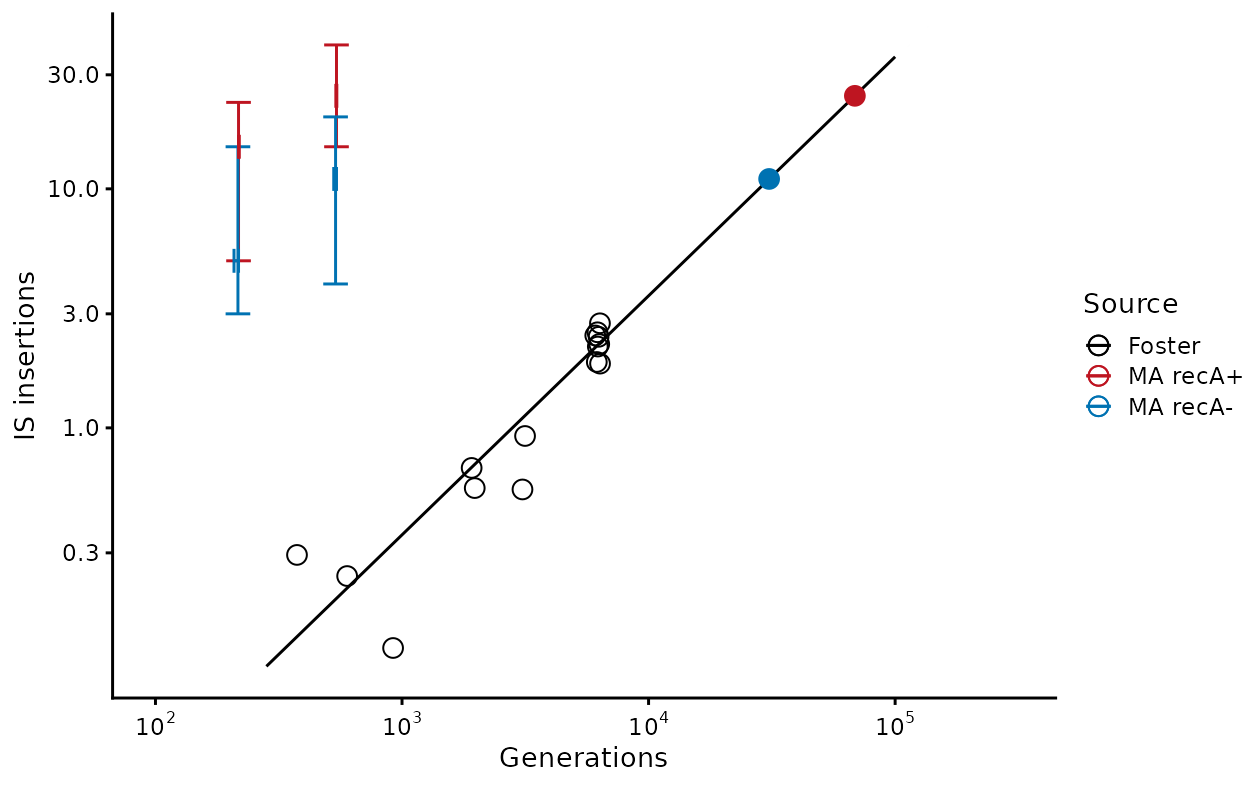

In [116]:
figure_name = file_prefix * "is_related_events_only_foster_log_fit_recAPM_median"
@rput figure_name
R"""
tmp.df_ <- genome_stats_df.isevent2 %>% select(-gen_id) %>%
	filter(Generations > 300) %>%
	rbind(fosterMA_) %>%
	filter(Source != "LTEE") %>%# filter(Source != "MA recA-") %>%
	arrange(Population, rev(Source)) %>%
	mutate(Foster_Gen = Event_CNT / coefficients(foster.lm)[1])

labs_ <- c("Foster", expression(paste("",italic(recA),"+")), expression(paste("",italic(recA),"\u2212")))

tmp.df_.summary <- genome_stats_df.isevent2 %>%
	filter(Source != "Foster") %>%
	group_by(Source, gen_id) %>%
	summarise(Gen.med = median(Generations), cnt.med = median(Event_CNT),
		Gen.max = max(Generations), Gen.min = min(Generations),
		Ev.max = max(Event_CNT), Ev.min = min(Event_CNT))

p <- tmp.df_ %>% 
	filter(Source == "Foster", Event_CNT != 0) %>% #20240129 found that fosterMA_ data can include 0s
	ggplot(aes(x = Generations, y = Event_CNT, color = Source)) +
	geom_point(shape=1, size = 3) +
	geom_errorbar(data = tmp.df_.summary, aes(ymin = Ev.min, ymax = Ev.max, x = Gen.med, y = cnt.med), width = 0.1) +
	geom_errorbar(data = tmp.df_.summary, aes(xmin = Gen.min, xmax = Gen.max, x = Gen.med, y = cnt.med), width = 0.1) +
	geom_line(data = data.frame(Generations = 10 ^ seq(1, 6, , length.out = 101)) %>%
		mutate(Event_CNT = coefficients(foster.lm)[1] * Generations),
		color = "black", size = .5) +
	geom_point(data = tmp.df_ %>% filter(Generations > 300, Source != "Foster") %>%
		group_by(Source) %>% summarise(Foster_Gen = median(Foster_Gen)) %>%
		mutate(Event_CNT = coefficients(foster.lm)[1] * Foster_Gen),
		aes(x = Foster_Gen), shape = 19, size = 3) + 
	scale_x_log10(lim=c(100,3e5), label = trans_format("log10", math_format(10^.x))) +
	scale_y_log10(lim = c(0.1, 40), breaks = c(0.3, 1, 3, 10, 30)) +
	labs(x = "Generations", y = "IS insertions") + 
	theme_half_open(10)+
	theme(legend.text = element_text(hjust = 0)) +
	scale_color_manual(values = c("black", "#be1521", "#0072b2")) + 
	guides(color = guide_legend(override.aes = list(shape = 1)))

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=80, height=50, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=80, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

### STAT: Days based on Foster generations

In [117]:
R"""
tmp.df_ %>% group_by(Source) %>% summarise(Foster_Gen = median(Foster_Gen))  %>% print
recA.FG <- tmp.df_ %>% group_by(Source) %>% summarise(Foster_Gen = median(Foster_Gen)) %>% 
	filter(Source == "MA recA+") %>% pull(Foster_Gen)
# foster 3080 generations / 111 days / 365 days / year, 7/5 days (/ week)
recA.FG / 3080 * 111 / 365 * 7/5
"""

# A tibble: 3 × 2
  Source   Foster_Gen
  <chr>         <dbl>
1 Foster         168.
2 MA recA+     68662.
3 MA recA-     30828.


RObject{RealSxp}
[1] 9.491298


┌ Warning: RCall.jl: Warning: Removed 49 rows containing missing values (`geom_line()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning: Removed 49 rows containing missing values (`geom_line()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning: Removed 49 rows containing missing values (`geom_line()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


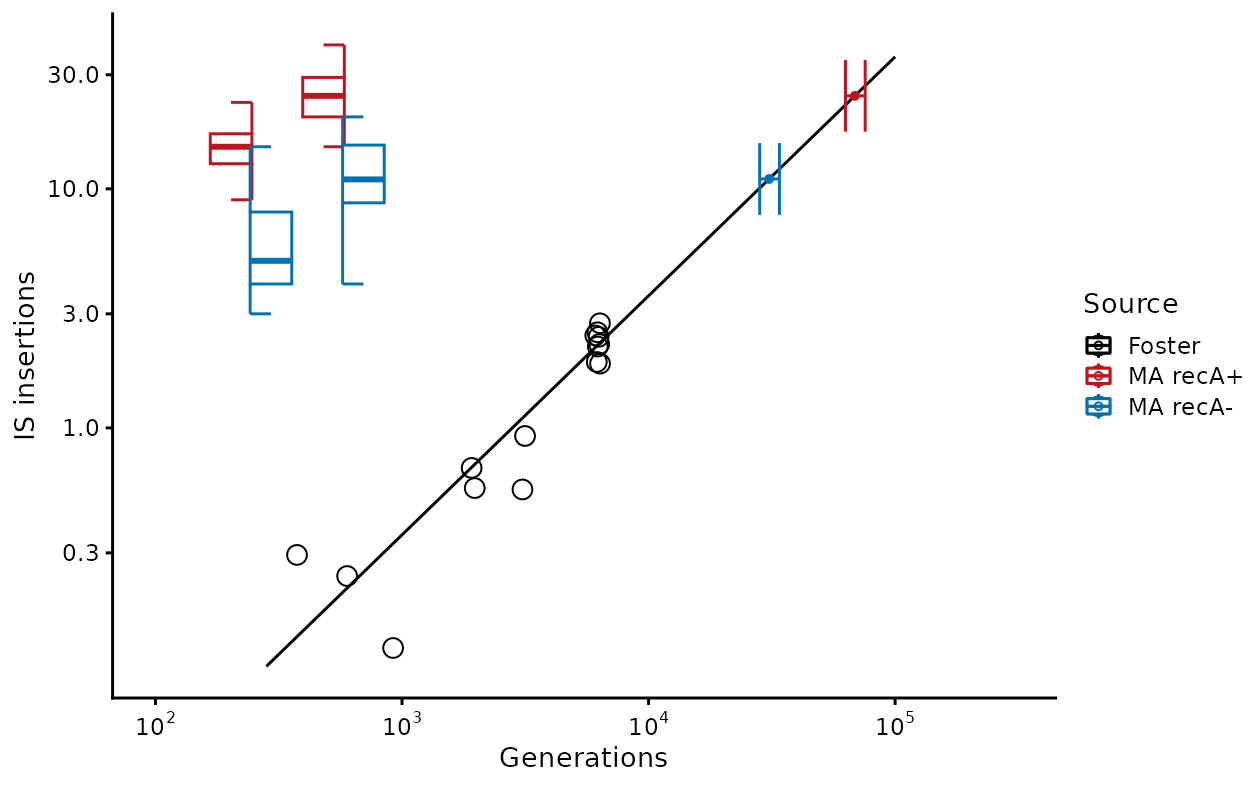

In [118]:
figure_name = file_prefix * "is_related_events_only_foster_log_fit_recAPM_median_2"
@rput figure_name
R"""
tmp.df_ <- genome_stats_df.isevent2 %>% select(-gen_id) %>%
	filter(Generations > 300) %>%
	rbind(fosterMA_) %>%
	filter(Source != "LTEE") %>%# filter(Source != "MA recA-") %>%
	arrange(Population, rev(Source)) %>%
	mutate(Foster_Gen = Event_CNT / coefficients(foster.lm)[1])

labs_ <- c("Foster", expression(paste("",italic(recA),"+")), expression(paste("",italic(recA),"\u2212")))

tmp.df2_ <- genome_stats_df.isevent2 %>% select(-gen_id) %>%
	filter(Generations > 300, Source != "Foster") %>%
		group_by(Source) %>%
		summarise(Event_CNT = median(Event_CNT)) %>%
		mutate(Foster_Gen = Event_CNT / coefficients(foster.lm)[1],
			Foster_Gen_low = Event_CNT/ confint(foster.lm)[1],
			Foster_Gen_high = Event_CNT/ confint(foster.lm)[2])
			

p <- tmp.df_ %>% 
	filter(Source == "Foster", Event_CNT != 0) %>% #20240129 found that fosterMA_ data can include 0s
	ggplot(aes(x = Generations, y = Event_CNT, color = Source)) +
	geom_point(shape=1, size = 3) +
	
	geom_half_boxplot(data=genome_stats_df.isevent2 %>% filter(Source == "MA recA+", gen_id > 1) %>% mutate(Generations = median(Generations)), aes(group = gen_id), outlier.color =NA) +
	geom_half_boxplot(data=genome_stats_df.isevent2 %>% filter(Source == "MA recA-", gen_id > 1) %>% mutate(Generations = median(Generations)), aes(group = gen_id), side="r", outlier.color=NA) + 

	# line of extrapolation of foster data
	geom_line(data = data.frame(Generations = 10 ^ seq(1, 6, , length.out = 101)) %>%
		mutate(Event_CNT = coefficients(foster.lm)[1] * Generations),
		color = "black", size = .5) +
	geom_point(data = tmp.df2_, aes(x = Foster_Gen), shape = 19, size = 1) + 
	geom_errorbar(data = tmp.df2_, aes(x = Foster_Gen, xmin = Foster_Gen_low, xmax = Foster_Gen_high), width = 0.3) +
	scale_x_log10(lim=c(100,3e5), label = trans_format("log10", math_format(10^.x))) +
	scale_y_log10(lim = c(0.1, 40), breaks = c(0.3, 1, 3, 10, 30)) +
	labs(x = "Generations", y = "IS insertions") + 
	theme_half_open(10)+
	theme(legend.text = element_text(hjust = 0)) +
	scale_color_manual(values = c("black", "#be1521", "#0072b2")) + 
	guides(color = guide_legend(override.aes = list(shape = 1)))

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=80, height=50, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=80, height=50, units="mm", dpi=1000)
p.iscn.foster <- p
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

In [119]:
R"""
tmp.df2_
"""

RObject{VecSxp}
# A tibble: 2 × 5
  Source   Event_CNT Foster_Gen Foster_Gen_low Foster_Gen_high
  <chr>        <dbl>      <dbl>          <dbl>           <dbl>
1 MA recA+      24.5     68662.         75597.          62893.
2 MA recA-      11       30828.         33941.          28238.


┌ Warning: RCall.jl: Warning: Removed 101 rows containing missing values (`geom_line()`).
│ Warning: Removed 2 rows containing missing values (`geom_point()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning: Removed 101 rows containing missing values (`geom_line()`).
│ Warning: Removed 2 rows containing missing values (`geom_point()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning: Removed 101 rows containing missing values (`geom_line()`).
│ Warning: Removed 2 rows containing missing values (`geom_point()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


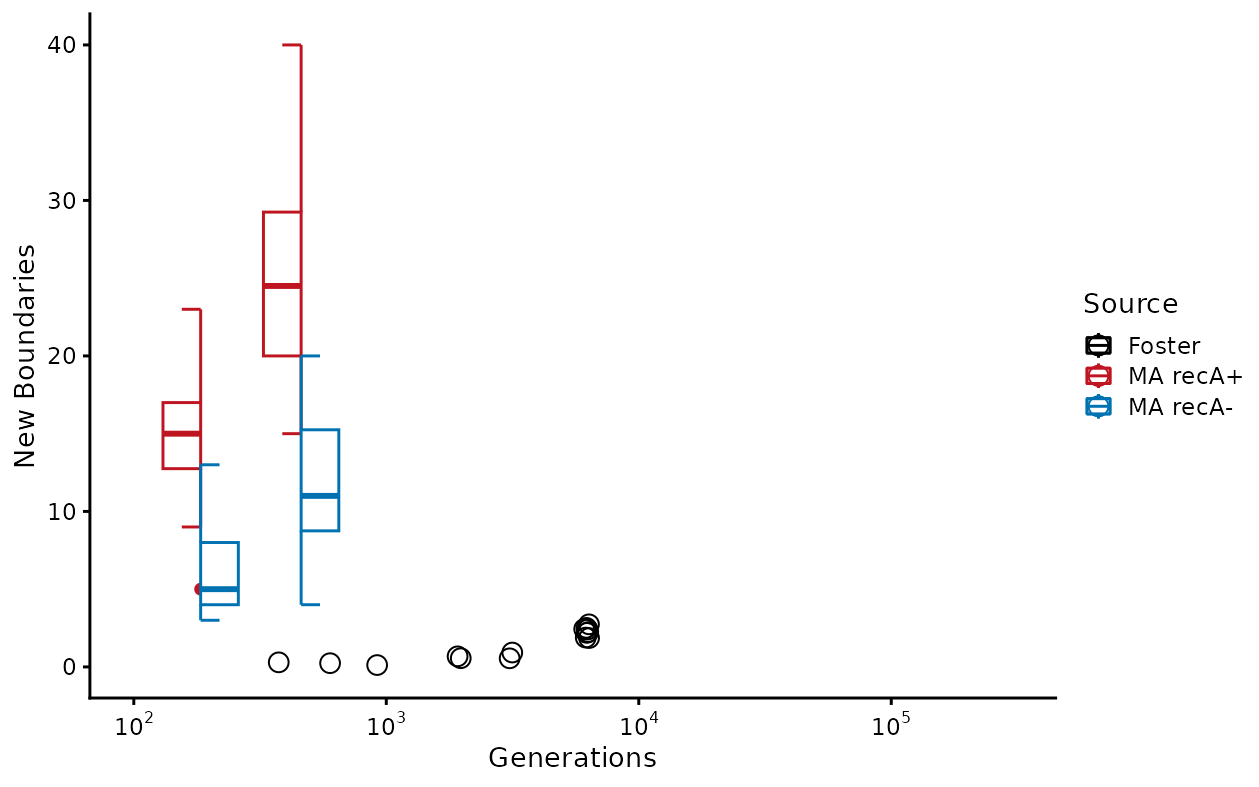

In [120]:
# plot before revision
figure_name = file_prefix * "is_related_events_only_foster_xlog_fit_recAPM_median"
@rput figure_name
R"""
tmp.df_ <- genome_stats_df.isevent %>% 
	filter(Generations > 100) %>%
	rbind(fosterMA_) %>%
	filter(Source != "LTEE") %>%# filter(Source != "MA recA-") %>%
	arrange(Population, rev(Source)) %>%
	mutate(Foster_Gen = (Event_CNT - coefficients(foster.lm)[1]) / coefficients(foster.lm)[2])

labs_ <- c("Foster", expression(paste("",italic(recA),"+")), expression(paste("",italic(recA),"\u2212")))

p <- tmp.df_ %>% 
	filter(Source == "Foster", Event_CNT != 0) %>% #20240129 found that fosterMA_ data can include 0s
	ggplot(aes(x = Generations, y = Event_CNT, color = Source)) +
	geom_point(shape=1, size = 3) +
	geom_half_boxplot(data=tmp.df_ %>% filter(Source == "MA recA+"), aes(group = Generations)) + 
	geom_half_boxplot(data=tmp.df_ %>% filter(Source == "MA recA-"), aes(group = Generations), side="r", outlier.color=NA) + 
	# line of extrapolation of foster data
	geom_line(data = data.frame(Generations = 10 ^ seq(2, 6, , length.out = 101)) %>%
		mutate(Event_CNT = coefficients(foster.lm)[1] + coefficients(foster.lm)[2] * Generations),
		color = "black", size = .5) +
	geom_point(data = tmp.df_ %>% filter(Generations > 200, Source != "Foster") %>%
		group_by(Source) %>% summarise(Foster_Gen = median(Foster_Gen)) %>%
		mutate(Event_CNT = coefficients(foster.lm)[1] + coefficients(foster.lm)[2] * Foster_Gen),
		aes(x = Foster_Gen), shape = 19, size = 3) + 
	scale_x_log10(lim=c(100,3e5), label = trans_format("log10", math_format(10^.x))) +
	ylim(0, 40) + 
	labs(x = "Generations", y = "New Boundaries") + 
	theme_half_open(10)+
	theme(legend.text = element_text(hjust = 0)) +
	#scale_color_brewer(palette = "Set1", labels = labs_, name = "") + 
	scale_color_manual(values = c("black", "#be1521", "#0072b2")) + 
	guides(color = guide_legend(override.aes = list(shape = 1)))

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=80, height=50, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=80, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

### DAT: IS CN and Ins events

In [121]:
R"""
genome_stats_df.iscn2 <- genome_stats_df %>%
	arrange(Prefix, gen_id) %>%
	select(Prefix, gen_id, is_cnt, new_cnt_anc) %>%
	mutate(recA = ifelse(as.numeric(str_sub(Prefix, start=2, end = 3))<=6, "recA+", "recA-")) %>%
	mutate(mutS = ifelse(as.numeric(str_sub(Prefix, start=2, end = 3))==8, "mutS-", "mutS+")) %>%
	mutate(is_cnt_change = lead(is_cnt) - is_cnt) %>%
	mutate(is_cnt_change = ifelse(gen_id == max(gen_id), NA, is_cnt_change)) %>%
	mutate(is_cnt_change_per_gen = ifelse(gen_id == 1, is_cnt_change/8, is_cnt_change/12))

genome_stats_df.iscn2 %>% head
"""

RObject{VecSxp}
  Prefix gen_id is_cnt new_cnt_anc  recA  mutS is_cnt_change
1  L01-1      1     10          NA recA+ mutS+             7
2  L01-1      2     17           9 recA+ mutS+            13
3  L01-1      3     30          31 recA+ mutS+            NA
4  L01-2      1     10          NA recA+ mutS+             6
5  L01-2      2     16          10 recA+ mutS+             5
6  L01-2      3     21          21 recA+ mutS+            NA
  is_cnt_change_per_gen
1             0.8750000
2             1.0833333
3                    NA
4             0.7500000
5             0.4166667
6                    NA


## STAT: IS CN and Ins events

In [122]:
R""" # IS copy number stat min,max per recA
genome_stats_df.iscn2 %>% filter(gen_id == 3) %>%
	group_by(recA) %>%
	summarise(min = min(is_cnt), max = max(is_cnt))
"""

RObject{VecSxp}
# A tibble: 2 × 3
  recA    min   max
  <chr> <int> <int>
1 recA+    18    35
2 recA-    13    29


In [123]:
# added 20240616 based on CF comment
R"""
# Subset data for recA+ and gen_id 1 or 3
data_recA_plus <- subset(genome_stats_df.iscn2, recA == "recA+" & gen_id %in% c(1, 3))

# Subset data for recA- and gen_id 1 or 3
data_recA_minus <- subset(genome_stats_df.iscn2, recA == "recA-" & gen_id %in% c(1, 3))

# Performing t-test for recA+
t_test_recA_plus <- t.test(is_cnt ~ gen_id, data = data_recA_plus, paired = TRUE)

# Performing t-test for recA-
t_test_recA_minus <- t.test(is_cnt ~ gen_id, data = data_recA_minus, paired = TRUE)

# Wilcoxon test for non-normally distributed data
wilcox_test_results <- wilcox.test(is_cnt ~ recA, data = genome_stats_df.iscn2, subset = gen_id %in% c(3))

# Output results
print("T-test for recA+:")
print(t_test_recA_plus)

print("T-test for recA-:")
print(t_test_recA_minus)

print("Wilcoxon test")
print(wilcox_test_results)
"""

[1] "T-test for recA+:"

	Paired t-test

data:  is_cnt by gen_id
t = -21.083, df = 23, p-value < 2.2e-16
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -17.38691 -14.27976
sample estimates:
mean difference 
      -15.83333 

[1] "T-test for recA-:"

	Paired t-test

data:  is_cnt by gen_id
t = -6.2323, df = 19, p-value = 5.502e-06
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -9.016878 -4.483122
sample estimates:
mean difference 
          -6.75 

[1] "Wilcoxon test"

	Wilcoxon rank sum test with continuity correction

data:  is_cnt by recA
W = 434, p-value = 4.865e-06
alternative hypothesis: true location shift is not equal to 0



┌ Warning: RCall.jl: Warning in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...) :
│   cannot compute exact p-value with ties
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}

	Wilcoxon rank sum test with continuity correction

data:  is_cnt by recA
W = 434, p-value = 4.865e-06
alternative hypothesis: true location shift is not equal to 0



### Improve stats
Reviewer recommended tot use glm instead of tests withgaussian assumption.

In [124]:
R"""
data_recA_minus %>% head
"""

RObject{VecSxp}
   Prefix gen_id is_cnt new_cnt_anc  recA  mutS is_cnt_change
73  L07-1      1     14          NA recA- mutS+             3
75  L07-1      3     18           9 recA- mutS+            NA
76  L07-2      1     14          NA recA- mutS+             2
78  L07-2      3     18          10 recA- mutS+            NA
79  L07-3      1     14          NA recA- mutS+             3
81  L07-3      3     19           9 recA- mutS+            NA
   is_cnt_change_per_gen
73                 0.375
75                    NA
76                 0.250
78                    NA
79                 0.375
81                    NA


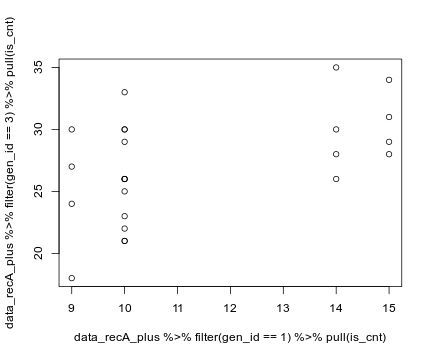

RObject{NilSxp}
NULL


In [125]:
R"""
plot(data_recA_plus %>% filter(gen_id == 1) %>% pull(is_cnt), data_recA_plus %>% filter(gen_id == 3) %>% pull(is_cnt))
"""

In [126]:
R"""
glm.is_cnt.r_plus <- glm(is_cnt ~ gen_id + Prefix, data = data_recA_plus %>% mutate(gen_id = ifelse(gen_id ==3, 1, 0)),
	family = poisson(link = "log"))
summary(glm.is_cnt.r_plus) %>% print
check_overdispersion(glm.is_cnt.r_plus) %>% print
check_zeroinflation(glm.is_cnt.r_plus) %>% print
exp(coefficients(glm.is_cnt.r_plus)[["gen_id"]]) %>% print
exp(confint(glm.is_cnt.r_plus, parm = "gen_id")) %>% print
Anova(glm.is_cnt.r_plus, type = "II") %>% print
"""


Call:
glm(formula = is_cnt ~ gen_id + Prefix, family = poisson(link = "log"), 
    data = data_recA_plus %>% mutate(gen_id = ifelse(gen_id == 
        3, 1, 0)))

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)  2.466e+00  1.661e-01  14.845   <2e-16 ***
gen_id       8.742e-01  7.218e-02  12.112   <2e-16 ***
PrefixL01-2 -2.549e-01  2.393e-01  -1.065    0.287    
PrefixL01-3 -1.924e-01  2.352e-01  -0.818    0.413    
PrefixL01-4 -1.054e-01  2.297e-01  -0.459    0.647    
PrefixL02-1  1.398e-01  2.162e-01   0.646    0.518    
PrefixL02-2  9.531e-02  2.185e-01   0.436    0.663    
PrefixL02-3  7.232e-02  2.197e-01   0.329    0.742    
PrefixL02-4  2.029e-01  2.131e-01   0.952    0.341    
PrefixL03-1 -3.930e-01  2.491e-01  -1.578    0.115    
PrefixL03-2 -1.924e-01  2.352e-01  -0.818    0.413    
PrefixL03-3 -1.054e-01  2.297e-01  -0.459    0.647    
PrefixL03-4 -2.532e-02  2.250e-01  -0.113    0.910    
PrefixL04-1 -7.931e-16  2.236e-01   0.000    1.000  

┌ Warning: RCall.jl: No overdispersion detected.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Waiting for profiling to be done...
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
Analysis of Deviance Table (Type II tests)

Response: is_cnt
       LR Chisq Df Pr(>Chisq)    
gen_id  161.011  1     <2e-16 ***
Prefix   20.434 23     0.6156    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [127]:
R"""
glm.is_cnt.r_minus <- glm(is_cnt ~ gen_id + Prefix, data = data_recA_minus  %>% mutate(gen_id = ifelse(gen_id ==3, 1, 0)),
	family = poisson(link = "log"))
summary(glm.is_cnt.r_minus) %>% print
check_overdispersion(glm.is_cnt.r_minus) %>% print
check_zeroinflation(glm.is_cnt.r_minus) %>% print
exp(coefficients(glm.is_cnt.r_minus)[["gen_id"]]) %>% print
exp(confint(glm.is_cnt.r_minus, parm = "gen_id")) %>% print
Anova(glm.is_cnt.r_minus, type = "II") %>% print
"""


Call:
glm(formula = is_cnt ~ gen_id + Prefix, family = poisson(link = "log"), 
    data = data_recA_minus %>% mutate(gen_id = ifelse(gen_id == 
        3, 1, 0)))

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)  2.534e+00  1.835e-01  13.806  < 2e-16 ***
gen_id       4.318e-01  8.122e-02   5.316 1.06e-07 ***
PrefixL07-2 -2.476e-16  2.500e-01   0.000    1.000    
PrefixL07-3  3.077e-02  2.481e-01   0.124    0.901    
PrefixL07-4  8.961e-02  2.446e-01   0.366    0.714    
PrefixL08-1 -6.454e-02  2.541e-01  -0.254    0.800    
PrefixL08-2  1.978e-01  2.385e-01   0.829    0.407    
PrefixL08-3 -3.833e-16  2.500e-01   0.000    1.000    
PrefixL08-4 -3.758e-16  2.500e-01   0.000    1.000    
PrefixL09-1 -9.844e-02  2.564e-01  -0.384    0.701    
PrefixL09-2 -2.877e-01  2.700e-01  -1.065    0.287    
PrefixL09-3  6.062e-02  2.463e-01   0.246    0.806    
PrefixL09-4 -2.877e-01  2.700e-01  -1.065    0.287    
PrefixL10-1 -2.076e-01  2.640e-01  -0.786    0.432 

┌ Warning: RCall.jl: No overdispersion detected.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Waiting for profiling to be done...
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
Analysis of Deviance Table (Type II tests)

Response: is_cnt
       LR Chisq Df Pr(>Chisq)    
gen_id   28.921  1  7.539e-08 ***
Prefix   12.426 19     0.8666    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [128]:
R"""
glm.ins_cnt.recA <- glm(new_cnt_anc ~ recA,
	data = genome_stats_df.iscn2 %>% filter(gen_id == 3) %>%
	mutate(Parent = str_sub(Prefix, start = 1, end = 3)), family = poisson(link = "log"))
summary(glm.ins_cnt.recA) %>% print
check_overdispersion(glm.ins_cnt.recA) %>% print
check_zeroinflation(glm.ins_cnt.recA) %>% print
exp(coefficients(glm.ins_cnt.recA)[["recArecA-"]]) %>% print
exp(confint(glm.ins_cnt.recA, parm = "recArecA-")) %>% print
Anova(glm.ins_cnt.recA, type = "II") %>% print
"""


Call:
glm(formula = new_cnt_anc ~ recA, family = poisson(link = "log"), 
    data = genome_stats_df.iscn2 %>% filter(gen_id == 3) %>% 
        mutate(Parent = str_sub(Prefix, start = 1, end = 3)))

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  3.22386    0.04072  79.165   <2e-16 ***
recArecA-   -0.75576    0.07678  -9.843   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 177.175  on 43  degrees of freedom
Residual deviance:  71.032  on 42  degrees of freedom
AIC: 280.76

Number of Fisher Scoring iterations: 4

# Overdispersion test

       dispersion ratio =  1.684
  Pearson's Chi-Squared = 70.745
                p-value =  0.004

Model has no observed zeros in the response variable.
NULL
[1] 0.4696517
    2.5 %    97.5 % 
0.4033355 0.5450649 
Analysis of Deviance Table (Type II tests)

Response: new_cnt_anc
     LR Chisq Df Pr(>Chisq)    
recA  

┌ Warning: RCall.jl: Overdispersion detected.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Waiting for profiling to be done...
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
Analysis of Deviance Table (Type II tests)

Response: new_cnt_anc
     LR Chisq Df Pr(>Chisq)    
recA   106.14  1  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


## FIG: IS CN and Ins events

┌ Warning: RCall.jl: Warning: The `labeller` API has been updated. Labellers taking `variable` and `value`
│ arguments are now deprecated.
│ ℹ See labellers documentation.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y,  :
│   conversion failure on '−' in 'mbcsToSbcs': dot substituted for <e2>
│ Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y,  :
│   conversion failure on '−' in 'mbcsToSbcs': dot substituted for <88>
│ Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y,  :
│   conversion failure on '−' in 'mbcsToSbcs': dot substituted for <92>
│ Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y,  :
│   conversion failure on '−' in 'mbcsToSbcs': dot substituted for <e2>
│ Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y,  :
│   conversion failure on '−' in 'mbcsToSbcs': dot substituted for <88>
│ Warning 

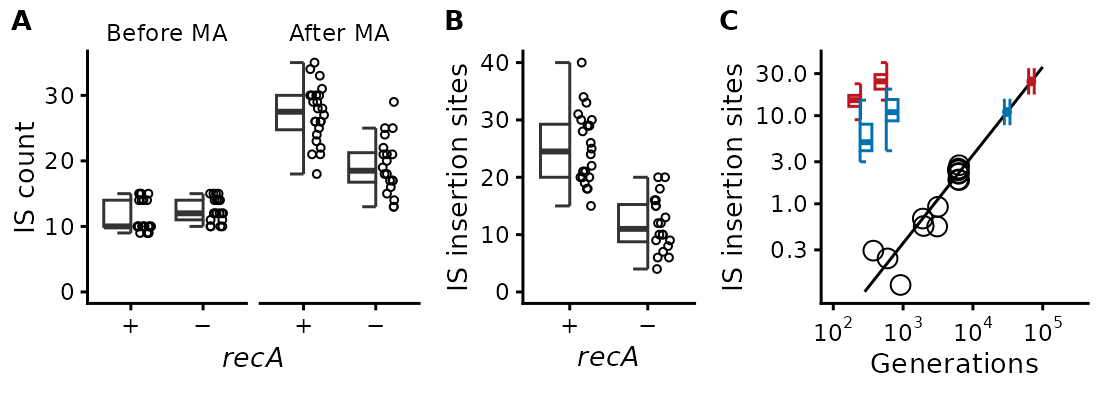

In [129]:
figure_name = file_prefix * "iscn_isevent_foster_combined"
@rput figure_name
R"""
#pdf.options(encoding='ISOLatin2.enc')
library(gghalves)

recA.names <- c(expression(paste(italic("recA"),"+")), expression(paste(italic("recA"),"\u2212")))

p.iscn <- 
genome_stats_df.iscn2 %>% 
filter(gen_id %in% c(1,3)) %>%
mutate(gen_id = as.factor(gen_id)) %>%
mutate(recA = ifelse(recA == "recA+", "+", "\u2212")) %>%
ggplot(aes(x = recA, y = is_cnt)) +
#geom_half_violin(aes(fill = recA), alpha = 0.5, width = 0.8, lwd = 0.2, trim = TRUE) +
geom_half_boxplot(outlier.color = NA) +
geom_half_point(side = "r", size = 1, shape = 1, transformation = position_jitter(width = 0.1, height = 0)) +
facet_grid(~gen_id, labeller = function(variable,value){
	lst<- list(
	"1" = "Before MA",
	"3" = "After MA")
	return(lst[value])}
	)  +
#scale_x_discrete(labels = recA.names) +
labs(x = expression(italic("recA")), y = "IS count") +
theme_half_open(10) +
ylim(0,NA) +
theme(strip.background = element_blank())

p.isevent <-
genome_stats_df.iscn2 %>% 
filter(gen_id %in% c(3)) %>%
mutate(recA = ifelse(recA == "recA+", "+", "\u2212")) %>%
ggplot(aes(x = recA, y = new_cnt_anc)) +
geom_half_boxplot(outlier.color = NA) +
geom_half_point(side = "r", size = 1, shape = 1, transformation = position_jitter(width = 0.1, height = 0)) +
labs(x = expression(italic("recA")), y = "IS insertion sites") +
#scale_x_discrete(labels = recA.names) +
theme_half_open(10) +
ylim(0,NA) +
theme(strip.background = element_blank())

p <- plot_grid(
	p.iscn, p.isevent, p.iscn.foster + theme(legend.position = "none") + ylab("IS insertion sites"),
	nrow = 1, rel_widths = c(5.5, 3.5, 5), align = "h", axis = "tb",
	labels = c("A", "B", "C"), label_size = 10
) + panel_border(remove = TRUE)

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=140, height=50, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=140, height=50, units="mm", dpi=1000, device = cairo_pdf)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=140, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))


In [130]:
R"""
comment_header <- "# Gen: `1` (preMA), `2` (MA 8 passages), `3` (MA 20 passages)"
out_dir <- file.path(data_export_dir, paste0(file_prefix, "is_count_insertion_site_cnt.csv"))
write_lines(comment_header, out_dir)
genome_stats_df.iscn2 %>%
	select(-mutS) %>%
	rename(Line = Prefix, Gen = gen_id, `IS count` = is_cnt, `New Insertion Sites` = new_cnt_anc) %>%
	write_csv(out_dir, append = TRUE, col_names = TRUE)
""";

## STAT: IS increase

┌ Warning: RCall.jl: Warning: Specifying the `id_cols` argument by position was deprecated in tidyr 1.3.0.
│ ℹ Please explicitly name `id_cols`, like `id_cols = c(Prefix, recA, mutS)`.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


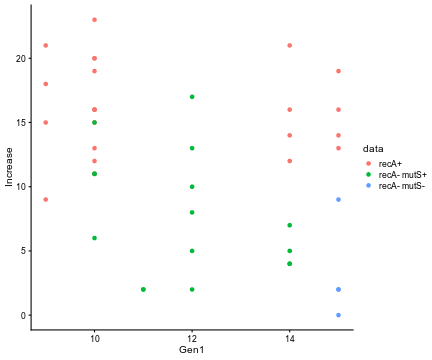

RObject{VecSxp}


In [131]:
R"""
iscn.tmp.df <- genome_stats_df.iscn2 %>%
	pivot_wider(c(Prefix, recA, mutS), names_from = gen_id, values_from = is_cnt, names_prefix = "Gen") %>%
		mutate(Increase = Gen3 - Gen1)  %>%
		mutate(data = case_when(
			recA == "recA+" ~ "recA+",
			recA == "recA-" & mutS == "mutS+" ~ "recA- mutS+",
			mutS == "mutS-" ~ "recA- mutS-"
			))

iscn.tmp.df %>% 
ggplot(aes(x = Gen1, y = Increase, color = data)) +
geom_point() +
theme_half_open(10) 
"""

In [132]:
R"""
genome_stats_df.iscn2 %>%
	pivot_wider(c(Prefix, recA, mutS), names_from = gen_id, values_from = is_cnt, names_prefix = "Gen") %>%
		mutate(Increase = Gen3 - Gen1)  %>%
		group_by(recA) %>%
		summarise(mean = mean(Increase), median = median(Increase), min = min(Increase), max = max(Increase))
"""

┌ Warning: RCall.jl: Warning: Specifying the `id_cols` argument by position was deprecated in tidyr 1.3.0.
│ ℹ Please explicitly name `id_cols`, like `id_cols = c(Prefix, recA, mutS)`.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 2 × 5
  recA   mean median   min   max
  <chr> <dbl>  <dbl> <int> <int>
1 recA+ 15.8    16       9    23
2 recA-  6.75    5.5     0    17


### STAT: IS inscease ~ preexisting IS + recA

In [133]:
# just the last gen : to show IS increase
R"""
lm.iscn1 <- lm(Increase ~ Gen1 + recA,
	data = genome_stats_df.iscn2 %>%
	pivot_wider(c(Prefix, recA, mutS), names_from = gen_id, values_from = is_cnt, names_prefix = "Gen") %>%
		mutate(Increase = Gen3 - Gen1) 
	)

summary(lm.iscn1) %>% print
Anova(lm.iscn1, type = "III") %>% print

##Use poisson log link R1
glm.iscn1 <- glm(Increase ~ Gen1 + recA, family = poisson(link = "log"),
	data = genome_stats_df.iscn2 %>%
	pivot_wider(c(Prefix, recA, mutS), names_from = gen_id, values_from = is_cnt, names_prefix = "Gen") %>%
		mutate(Increase = Gen3 - Gen1) 
	)
summary(glm.iscn1) %>% print
Anova(glm.iscn1, type = "III") %>% print
""";


Call:
lm(formula = Increase ~ Gen1 + recA, data = genome_stats_df.iscn2 %>% 
    pivot_wider(c(Prefix, recA, mutS), names_from = gen_id, values_from = is_cnt, 
        names_prefix = "Gen") %>% mutate(Increase = Gen3 - Gen1))

Residuals:
   Min     1Q Median     3Q    Max 
-7.890 -2.829 -0.437  3.118 10.024 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  20.9641     3.5424   5.918 5.66e-07 ***
Gen1         -0.4527     0.3033  -1.492    0.143    
recArecA-    -8.5552     1.3156  -6.503 8.33e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.185 on 41 degrees of freedom
Multiple R-squared:  0.5667,	Adjusted R-squared:  0.5455 
F-statistic: 26.81 on 2 and 41 DF,  p-value: 3.585e-08

Anova Table (Type III tests)

Response: Increase
            Sum Sq Df F value    Pr(>F)    
(Intercept) 613.38  1 35.0225 5.660e-07 ***
Gen1         39.01  1  2.2273    0.1432    
recA        740.66  1 42.2898 8.331e-08 ***

┌ Warning: RCall.jl: Warning: Specifying the `id_cols` argument by position was deprecated in tidyr 1.3.0.
│ ℹ Please explicitly name `id_cols`, like `id_cols = c(Prefix, recA, mutS)`.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning in printHypothesis(L, rhs, names(b)) :
│   one or more coefficients in the hypothesis include
│      arithmetic operators in their names;
│   the printed representation of the hypothesis will be omitted
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning: Specifying the `id_cols` argument by position was deprecated in tidyr 1.3.0.
│ ℹ Please explicitly name `id_cols`, like `id_cols = c(Prefix, recA, mutS)`.
│ Warning: Specifying the `id_cols` argument by position was deprecated in tidyr 1.3.0.
│ ℹ Please explicitly name `id_cols`, like `id_cols = c(Prefix, recA, mutS)`.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172



Call:
glm(formula = Increase ~ Gen1 + recA, family = poisson(link = "log"), 
    data = genome_stats_df.iscn2 %>% pivot_wider(c(Prefix, recA, 
        mutS), names_from = gen_id, values_from = is_cnt, names_prefix = "Gen") %>% 
        mutate(Increase = Gen3 - Gen1))

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  3.17194    0.23805  13.325  < 2e-16 ***
Gen1        -0.03646    0.02085  -1.749   0.0803 .  
recArecA-   -0.80879    0.10344  -7.819 5.33e-15 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 170.896  on 43  degrees of freedom
Residual deviance:  86.772  on 41  degrees of freedom
AIC: 271.12

Number of Fisher Scoring iterations: 5

Analysis of Deviance Table (Type III tests)

Response: Increase
     LR Chisq Df Pr(>Chisq)    
Gen1    3.114  1     0.0776 .  
recA   66.791  1  3.018e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0

In [134]:
# reduction of count between 8and 20 th passage in line L10-2.
R"head(genome_stats_df.iscn2 %>% filter(is_cnt_change < 0))"

RObject{VecSxp}
  Prefix gen_id is_cnt new_cnt_anc  recA  mutS is_cnt_change
1  L10-2      2     22          15 recA- mutS+            -1
  is_cnt_change_per_gen
1           -0.08333333


In [135]:
# All gens to see the effect of IS copies
R"""
##Use poisson log link R1
glm.iscn2 <- glm(is_cnt_change ~ is_cnt + recA,
	family = poisson(link = "log"),
	data = genome_stats_df.iscn2 %>% filter(gen_id <3) %>%
		mutate(is_cnt_change= ifelse(is_cnt_change > 0, is_cnt_change, 0)) %>%
		mutate(gen = ifelse(gen_id == 1, 8, 12)),
	offset = log(gen)
	)
summary(glm.iscn2) %>% print
check_overdispersion(glm.iscn2) %>% print
check_zeroinflation(glm.iscn2) %>% print
exp(coefficients(glm.iscn2)) %>% print
exp(confint(glm.iscn2)) %>% print
Anova(glm.iscn2, type = "III") %>% print
""";


Call:
glm(formula = is_cnt_change ~ is_cnt + recA, family = poisson(link = "log"), 
    data = genome_stats_df.iscn2 %>% filter(gen_id < 3) %>% mutate(is_cnt_change = ifelse(is_cnt_change > 
        0, is_cnt_change, 0)) %>% mutate(gen = ifelse(gen_id == 
        1, 8, 12)), offset = log(gen))

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  0.973611   0.146094   6.664 2.66e-11 ***
is_cnt      -0.075299   0.009182  -8.201 2.39e-16 ***
recArecA-   -0.979465   0.100303  -9.765  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 330.78  on 87  degrees of freedom
Residual deviance: 179.76  on 85  degrees of freedom
AIC: 471.12

Number of Fisher Scoring iterations: 5

# Overdispersion test

       dispersion ratio =   2.089
  Pearson's Chi-Squared = 177.573
                p-value = < 0.001

# Check for zero-inflation

   Observed zeros: 6
  Predicted ze

┌ Warning: RCall.jl: Overdispersion detected.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Model is underfitting zeros (probable zero-inflation).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Waiting for profiling to be done...
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


In [136]:
# All gens to see the effect of IS copies mixed effect
R"""
##Use poisson log link R1
glm.iscn3 <- glmer(is_cnt_change ~ is_cnt + recA + (1|recA:Prefix),
family = poisson(link = "log"),
	data = genome_stats_df.iscn2 %>% filter(gen_id <3) %>%
		mutate(is_cnt_change= ifelse(is_cnt_change > 0, is_cnt_change, 0)) %>%
		mutate(gen = ifelse(gen_id == 1, 8, 12)),
	offset = log(gen)
	)

summary(glm.iscn3) %>% print
check_overdispersion(glm.iscn3) %>% print
check_zeroinflation(glm.iscn3) %>% print
exp(fixef(glm.iscn3)) %>% print
Anova(glm.iscn3, type = "III") %>% print
""";

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: is_cnt_change ~ is_cnt + recA + (1 | recA:Prefix)
   Data: 
genome_stats_df.iscn2 %>% filter(gen_id < 3) %>% mutate(is_cnt_change = ifelse(is_cnt_change >  
    0, is_cnt_change, 0)) %>% mutate(gen = ifelse(gen_id == 1,      8, 12))
 Offset: log(gen)

     AIC      BIC   logLik deviance df.resid 
   448.7    458.6   -220.3    440.7       84 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.7517 -0.7309 -0.1477  0.5765  2.4756 

Random effects:
 Groups      Name        Variance Std.Dev.
 recA:Prefix (Intercept) 0.1698   0.412   
Number of obs: 88, groups:  recA:Prefix, 44

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  1.16258    0.17435   6.668 2.59e-11 ***
is_cnt      -0.08908    0.00966  -9.222  < 2e-16 ***
recArecA-   -1.07142    0.16426  -6.523 6.91e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.

┌ Warning: RCall.jl: No overdispersion detected.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Model is underfitting zeros (probable zero-inflation).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning in printHypothesis(L, rhs, names(b)) :
│   one or more coefficients in the hypothesis include
│      arithmetic operators in their names;
│   the printed representation of the hypothesis will be omitted
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


### Fig: IS increase ~ preexisting IS + recA

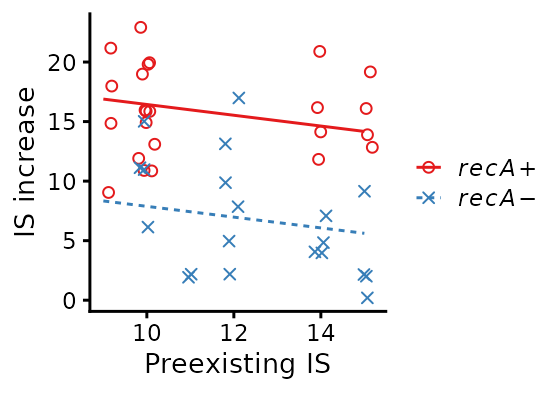

In [137]:
figure_name = file_prefix * "isincrease_vs_preexisting"
@rput figure_name
R"""
# Assuming you have already fitted the model lm.iscn1
# Generate new data for predictions
new_data <- expand.grid(
  Gen1 = seq(min(iscn.tmp.df$Gen1), max(iscn.tmp.df$Gen1), length.out = 100),
  recA = unique(iscn.tmp.df$recA)
)

# Predict using the model
new_data$Increase <- predict(lm.iscn1, newdata = new_data)

# Plot
labs_ <- c(expression(paste("",italic(recA),"+")), expression(paste("",italic(recA),"\u2212")))
p <- ggplot(iscn.tmp.df, aes(x = Gen1, y = Increase, color = recA, shape = recA)) +
  #geom_point() +  # original data points
  geom_jitter(width = 0.2, height = 0.2) +
  geom_line(data = new_data, aes(y = Increase, color = recA, linetype= recA)) +  # add regression lines
  scale_color_brewer(palette = "Set1", name = "", labels= labs_) +
  scale_shape_manual(values = c(1, 4), name = "", labels= labs_) +
  scale_linetype_discrete(name = "", labels= labs_) +
  xlab("Preexisting IS") +
  ylab("IS increase") +
  theme_half_open(10)

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=70, height=50, units="mm", dpi=200)
#ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=70, height=50, units="mm", dpi=1000, device = cairo_pdf)
#ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=70, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

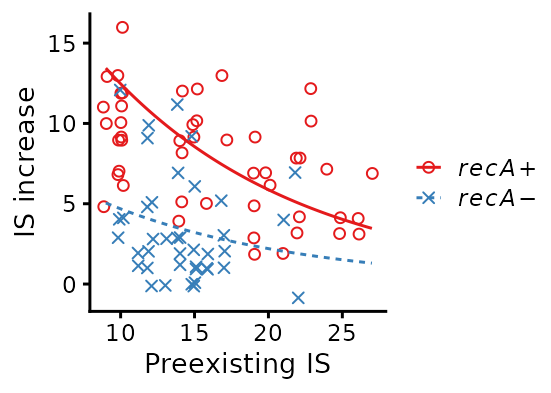

In [138]:
# glm version
figure_name = file_prefix * "isincrease_vs_preexisting_glm"
@rput figure_name
R"""
# Assuming you have already fitted the model lm.iscn1
# Generate new data for predictions
new_data <- expand.grid(
  is_cnt = seq(min(genome_stats_df.iscn2$is_cnt),
    max(genome_stats_df.iscn2 %>% filter(gen_id < 3) %>%pull(is_cnt)), 
    length.out = 100),
  recA = unique(genome_stats_df.iscn2$recA), gen = 10
)


# Predict using the model
new_data$is_cnt_change <- predict(glm.iscn2, newdata = new_data, type = "response")

# Plot
labs_ <- c(expression(paste("",italic(recA),"+")), expression(paste("",italic(recA),"\u2212")))
p <- ggplot(genome_stats_df.iscn2 %>% filter(gen_id < 3),
aes(x = is_cnt, y = is_cnt_change, color = recA, shape = recA)) +
  geom_jitter(width = 0.2, height = 0.2) +
  geom_line(data = new_data, aes(y = is_cnt_change, color = recA, linetype= recA)) +  # add regression lines
  scale_color_brewer(palette = "Set1", name = "", labels= labs_) +
  scale_shape_manual(values = c(1, 4), name = "", labels= labs_) +
  scale_linetype_discrete(name = "", labels= labs_) +
  xlab("Preexisting IS") +
  ylab("IS increase") +
  theme_half_open(10)

p.glm.iscn2 <- p

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=70, height=50, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=70, height=50, units="mm", dpi=1000, device = cairo_pdf)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=70, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

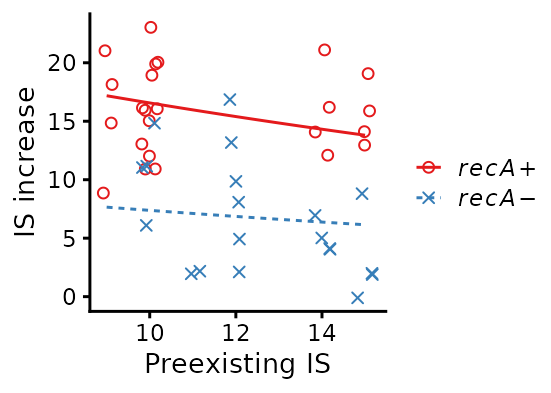

In [139]:
# glm version
figure_name = file_prefix * "isincrease_vs_preexisting_glm"
@rput figure_name
R"""
# Assuming you have already fitted the model lm.iscn1
# Generate new data for predictions
new_data <- expand.grid(
  Gen1 = seq(min(iscn.tmp.df$Gen1), max(iscn.tmp.df$Gen1), length.out = 100),
  recA = unique(iscn.tmp.df$recA)
)

# Predict using the model
new_data$Increase <- predict(glm.iscn1, newdata = new_data, type = "response")

# Plot
labs_ <- c(expression(paste("",italic(recA),"+")), expression(paste("",italic(recA),"\u2212")))
p <- ggplot(iscn.tmp.df ,
  aes(x = Gen1, y = Increase, color = recA, shape = recA)) +
  geom_jitter(width = 0.2, height = 0.2) +
  geom_line(data = new_data, aes(y = Increase, color = recA, linetype= recA)) +  # add regression lines
  scale_color_brewer(palette = "Set1", name = "", labels= labs_) +
  scale_shape_manual(values = c(1, 4), name = "", labels= labs_) +
  scale_linetype_discrete(name = "", labels= labs_) +
  xlab("Preexisting IS") +
  ylab("IS increase") +
  theme_half_open(10)

p.glm.iscn1 <- p

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=70, height=50, units="mm", dpi=200)
#ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=70, height=50, units="mm", dpi=1000, device = cairo_pdf)
#ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=70, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

┌ Warning: RCall.jl: Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y,  :
│   font metrics unknown for Unicode character U+2212
│ Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y,  :
│   font metrics unknown for Unicode character U+2212
│ Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y,  :
│   font metrics unknown for Unicode character U+2212
│ Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y,  :
│   font metrics unknown for Unicode character U+2212
│ Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y,  :
│   font metrics unknown for Unicode character U+2212
│ Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y,  :
│   font metrics unknown for Unicode character U+2212
│ Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y,  :
│   font metrics unknown for Unicode character U+2212
│ Warning in grid.Call(C_textBounds, as.graphicsAnnot(x$label), 

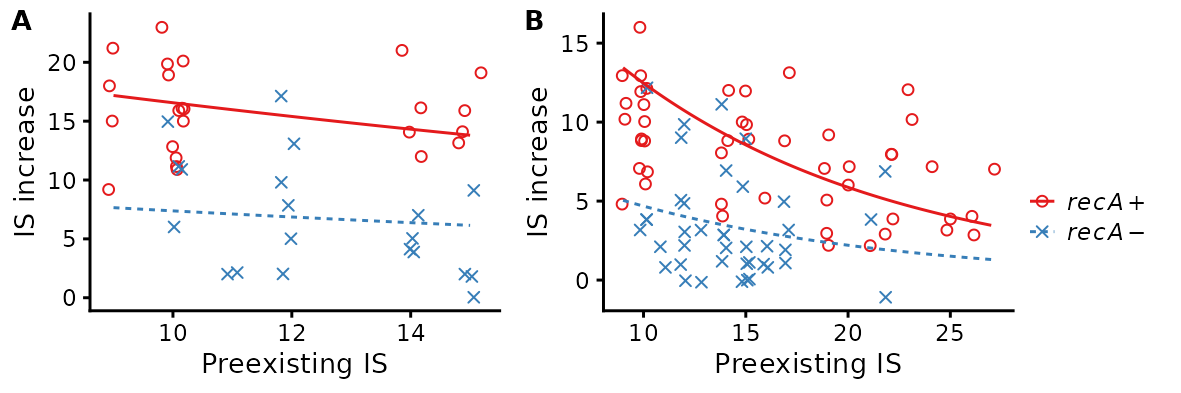

In [143]:
# merge figure
figure_name = file_prefix * "isincrease_vs_preexisting_glm"
@rput figure_name
R"""
p <- plot_grid(p.glm.iscn1 + theme(legend.position = "none"), p.glm.iscn2 + theme(legend.position = "none"),
	get_legend(p.glm.iscn1),
	nrow = 1, rel_widths = c(1,1,0.3), align = "h", axis = "tb",
	labels = c("A", "B", ""), label_size = 10
) + panel_border(remove = TRUE)

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=150, height=50, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=150, height=50, units="mm", dpi=1000, device = cairo_pdf)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=150, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

In [165]:
R"""
is_pos_df <- read_csv(file.path(base_dir, "export", "classify_IS_events", "IS_positions.csv"))
is_pos_df %>%
	filter((length < 3090) | (length > 3100)) %>%
	filter(Gen == 1) %>%
	pull(Line) %>%
	unique
"""

┌ Warning: RCall.jl: Rows: 2385 Columns: 8
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr (2): IS_strand, Line
│ dbl (6): start, end, max_alignment_length, length, cluster_id, Gen
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{StrSxp}
 [1] "L01-1" "L01-2" "L01-3" "L01-4" "L02-1" "L02-2" "L02-3" "L02-4" "L03-1"
[10] "L03-2" "L03-3" "L03-4" "L09-1" "L09-2" "L09-3" "L09-4" "L10-1" "L10-2"
[19] "L10-3" "L10-4"


In [166]:
R"""
new_is_variant_lines <- is_pos_df %>%
	filter((length < 3090) | (length > 3100)) %>%
	group_by(Line) %>%
	summarise(Gen = min(Gen)) %>%
	filter(Gen != 1) %>%
	pull(Line) %>%
	unique
"""

RObject{StrSxp}
 [1] "L04-2" "L04-3" "L04-4" "L05-1" "L05-2" "L05-3" "L06-2" "L06-4" "L07-2"
[10] "L07-3" "L07-4" "L08-2" "L08-3" "L11-1" "L11-4"


## Fig: Anc IS positions

In [167]:
R"""
is_pos_df %>% 
separate(Line, c("Parent", "Subline"), sep = "-", remove = FALSE) %>%
filter(Subline == "1") %>% head
"""

RObject{VecSxp}
# A tibble: 6 × 10
    start     end IS_strand max_alignment_length length cluster_id Line  Parent
    <dbl>   <dbl> <chr>                    <dbl>  <dbl>      <dbl> <chr> <chr> 
1  476928  480020 reverse                   3093   3093          0 L01-1 L01   
2  557167  560259 reverse                   3093   3093          1 L01-1 L01   
3 1187831 1192502 forward                   3093   4672          2 L01-1 L01   
4 1405123 1408215 forward                   3093   3093          3 L01-1 L01   
5 1499230 1503892 reverse                   3093   4663          4 L01-1 L01   
6 1986448 1991110 forward                   3093   4663          5 L01-1 L01   
# ℹ 2 more variables: Subline <chr>, Gen <dbl>


### is_position_in_genome.csv

In [168]:
R"""
comment_header <- "# Gen: `1` (preMA), `2` (MA 8 passages), `3` (MA 20 passages)"
out_dir <- file.path(data_export_dir, paste0(file_prefix, "is_position_in_genome.csv"))
write_lines(comment_header, out_dir)
is_pos_df %>%
	select(-max_alignment_length) %>%
	rename(IS_id = cluster_id) %>%
	write_csv(out_dir, append = TRUE, col_names = TRUE)
"""

RObject{VecSxp}
# A tibble: 2,385 × 7
     start     end IS_strand length IS_id Line    Gen
     <dbl>   <dbl> <chr>      <dbl> <dbl> <chr> <dbl>
 1  476928  480020 reverse     3093     0 L01-1     1
 2  557167  560259 reverse     3093     1 L01-1     1
 3 1187831 1192502 forward     4672     2 L01-1     1
 4 1405123 1408215 forward     3093     3 L01-1     1
 5 1499230 1503892 reverse     4663     4 L01-1     1
 6 1986448 1991110 forward     4663     5 L01-1     1
 7 2306486 2311148 reverse     4663     6 L01-1     1
 8 3373645 3376737 reverse     3093     7 L01-1     1
 9 3866530 3869621 forward     3092     8 L01-1     1
10 3964094 3968754 forward     4661     9 L01-1     1
# ℹ 2,375 more rows


## Fig: IS positions in Anc.

┌ Warning: RCall.jl: Warning in geom_point(data = tmp.df3, aes(x = genome_size, xend = genome_size,  :
│   Ignoring unknown aesthetics: xend and yend
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


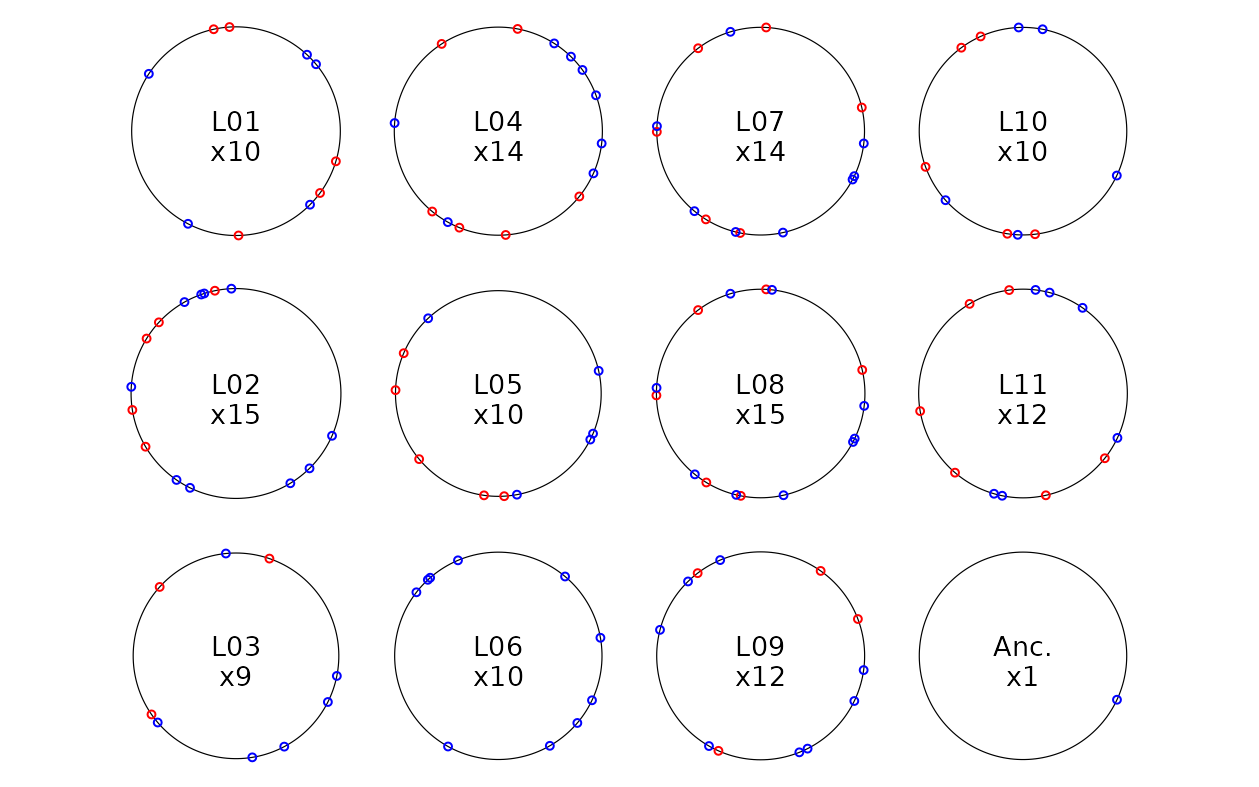

In [169]:
figure_name = "FACS_genomes"
@rput figure_name
R"""
max.genome.size <- max(genome_stats_df %>% filter(gen == "FACS") %>% pull(genome_size))
tmp.df1 <- is_pos_df %>% 
	separate(Line, c("Parent", "Subline"), sep = "-", remove = FALSE) %>%
	filter(Subline == "1", Gen == 1) %>%
	mutate(midpoint = (start + end) / 2, ID = str_sub(Parent, start = 2, end =3)) %>%
  select(ID, start, end, midpoint, IS_strand) %>%
  mutate(ID.label = paste0("L", ID)) %>%
  rbind(data.frame(ID = "Anc", ID.label = "Anc.", start = 1272e3, end = 1275e3, midpoint = 1274e3, IS_strand = "reverse"))
  #group_by(ID) %>%
  #mutate(first_ = first(midpoint), last_ = last(midpoint)) %>%
  #ungroup() %>%
  #filter(midpoint %in% c(first_))
tmp.df2 <- genome_stats_df %>%
      filter(SubLine == 1, gen == "FACS") %>%
      mutate(ID = str_pad(ParentLine, 2, pad = "0")) %>%
      select(ID, genome_size, is_cnt) %>%
      mutate(ID.label = paste0("L", ID)) %>%
      rbind(data.frame(ID = "Anc", genome_size = 3980425, ID.label = "Anc.", is_cnt = 1))
tmp.df3 <- 
 inner_join(tmp.df1, tmp.df2, by = "ID") %>%
mutate(start = start/genome_size, end = end/genome_size) 
p <- tmp.df3 %>%
group_by(ID) %>%
filter(midpoint == first(midpoint)) %>%
ggplot() +
  # Draw genes as lines on the circles
  geom_segment(aes(x= genome_size, xend = genome_size, y = 0, yend = 1), color = "black", size = .2) +
  geom_point(data = tmp.df3, aes(x= genome_size, xend = genome_size, y = start, yend = end, color = IS_strand), size = 1, shape = 1) +
      #scale_color_manual(values = c("blue", "red")) +
      scale_color_manual(values = c("red", "blue")) +
  # Add genome ID in the center of the circle
  geom_text(data = tmp.df2, aes(x = 0, label = ID.label), y = 0, vjust = 0, size = 10/(1/0.35)) +
  # Add gene count in the center of the circle
  geom_text(data = tmp.df2, aes(x = 0, label = paste0("x",is_cnt,"")), y = 0, vjust = 1.5, size = 10/(1/0.35))+
  # Use polar coordinates
  coord_polar(theta = "y", start = 0) +
  theme_nothing() +
  # Facet by genome ID
  facet_wrap(~ ID, ncol = 4, dir = "v")  +
  theme(panel.spacing = unit(0., "lines"))

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=160, height=100, units="mm", dpi=200)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=80, height=40, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=80, height=40, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

# Summarise number of events
For table

In [170]:
R"""
# Note the number excludes L04-1 Gen 3 
ins.cnt.df <- 
read_csv(file.path(base_dir, 'export', 'classify_IS_events', 'simple_insertion_distances.csv')) %>%
	mutate(parent = as.integer(str_sub(Line, start = 2, end = 3))) %>%
	filter(!(Line == "L04-1" & Gen == 3)) %>%
	mutate(recA = ifelse(parent <= 6, 'recA+', 'recA-')) %>%
	group_by(recA) %>%
	summarise(Ins.prevgen = n(), Ins.prevgen.simple = sum(sv %in% c("simple_insertion", "simple_transposition"))) %>%
	pivot_longer(cols = c(Ins.prevgen, Ins.prevgen.simple), names_to = "type", values_to = "value") %>%
	mutate(value.per.line = value/ifelse(recA=="recA+", 24, 20)) %>%
	select(type, recA, value, value.per.line) 
"""

┌ Warning: RCall.jl: Rows: 916 Columns: 8
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr (3): position_status, sv, Line
│ dbl (5): insert_id, pos, closest_original_id, closest_original_distance, Gen
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 4 × 4
  type               recA  value value.per.line
  <chr>              <chr> <int>          <dbl>
1 Ins.prevgen        recA+   644           26.8
2 Ins.prevgen.simple recA+   260           10.8
3 Ins.prevgen        recA-   258           12.9
4 Ins.prevgen.simple recA-   106            5.3


In [171]:
R"""
#IS cnt
is.cnt.cnt.df <- 
genome_stats_df.iscn %>% filter(Generations == 460) %>% group_by(Source) %>% summarise(is.cnt = sum(Insertion)) %>%
	mutate(recA = ifelse(Source == "MA.RecA", "recA+", "recA-")) %>%
	mutate(value = is.cnt, type = "IS.count") %>%
	mutate(value.per.line = value/ifelse(recA=="recA+", 24, 20)) %>%
	select(type, recA, value, value.per.line)
print(is.cnt.cnt.df)

# Insertion (MA20)
is.ins.cnt.df <-
is_in_mds42.df.prevgen %>% filter(Gen == "MA20", is.na(matched_row.facs))  %>%
	group_by(Parent, Line, Gen, insert_id) %>%
	summarise(pos = mean(pos)) %>%  # merge two flanks
	mutate(recA = ifelse(as.numeric(Parent) <= 6, "recA+", "recA-")) %>%
	group_by(recA) %>% summarise(insertion = n()) %>% 
	mutate(value = insertion, type = "Ins.MA20") %>%
	mutate(value.per.line = value/ifelse(recA=="recA+", 24, 20)) %>%
	select(type, recA, value, value.per.line) 
print(is.ins.cnt.df)
""";

# A tibble: 2 × 4
  type     recA  value value.per.line
  <chr>    <chr> <int>          <dbl>
1 IS.count recA+   380          15.8 
2 IS.count recA-   135           6.75
# A tibble: 2 × 4
  type     recA  value value.per.line
  <chr>    <chr> <int>          <dbl>
1 Ins.MA20 recA+   604           25.2
2 Ins.MA20 recA-   236           11.8


┌ Warning: RCall.jl: `summarise()` has grouped output by 'Parent', 'Line', 'Gen'. You can override
│ using the `.groups` argument.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


In [172]:
R"""
del.dup.cnt.df <- depth_interval_df.evo %>%
filter(!((line == "L04-1") & (gen_id == 3))) %>% # because of sequence divergence. Including this will lead to counting ori deletion, which did not happen.
# remove a "deletion" of a composite transposon. This composite transposition did not happen in the next generation so it is considered false positive.
filter(!((line == "L05-4") & (gen_id == 3) & (3.2e6 < start_fix) & (end_fix < 3.4e6) & (depth == 0) & (length > 1e4)))  %>%
filter(depth != 1) %>%
mutate(RecA = ifelse(as.numeric(str_sub(line, start=2, end = 3))<=6, "recA+", "recA-")) %>%
mutate(IS = ifelse(is_start != -1 | is_end != -1, "IS", "Non-IS")) %>%
mutate(IS = factor(IS, levels = c("Non-IS", "IS"))) %>%
mutate(Type = ifelse(depth == 0, "Deletion", "Duplication")) %>%
group_by(RecA) %>% 
summarise(Deletion = sum(Type == "Deletion"), Duplication = sum(Type == "Duplication"),
		Deletion.IS = sum(Type == "Deletion" & IS == "IS"), Duplication.IS = sum(Type == "Duplication" & IS == "IS"),
		# duplication counting multiples
		Duplication2 = sum((depth-1) * (Type == "Duplication")),
		Duplication2.IS = sum((depth-1) * (Type == "Duplication") * (IS == "IS"))
		) %>%
		rename(recA = RecA)
"""

RObject{VecSxp}
# A tibble: 2 × 7
  recA  Deletion Duplication Deletion.IS Duplication.IS Duplication2
  <chr>    <int>       <int>       <int>          <int>        <dbl>
1 recA+      254          31         249             31           38
2 recA-      109          11         109             11           13
# ℹ 1 more variable: Duplication2.IS <dbl>


In [173]:
R"""
inv.cnt.df <- sv.df %>% filter(SVTYPE == "INV") %>%
# remove artifact due to sequence dievergence between G08 and G20
filter(!((Line == "L05-4") & gen_id == 3 & ID == "INV5"), !((Line == "L04-1" & gen_id == 3 & ID == "INV2"))) %>%
mutate(recA = ifelse(as.numeric(str_sub(Line, start=2, end = 3))<=6, "recA+", "recA-")) %>%
group_by(recA) %>%
summarise(value = n()) %>%
	mutate(type = "Inversion") %>%
	mutate(value.per.line = value/ifelse(recA=="recA+", 24, 20)) %>%
	select(type, recA, value, value.per.line) 
"""

RObject{VecSxp}
# A tibble: 2 × 4
  type      recA  value value.per.line
  <chr>     <chr> <int>          <dbl>
1 Inversion recA+    42           1.75
2 Inversion recA-    12           0.6 


In [174]:
R"""
del.dup.cnt.df.tmp <- 
del.dup.cnt.df %>% pivot_longer(cols = -recA, names_to = "Type", values_to = "value")  %>%
	mutate(value.per.line = value/ifelse(recA=="recA+", 24, 20))  %>%
	pivot_wider(names_from = recA, values_from = c(value, value.per.line))  %>%
	rename(`recA+` = `value_recA+`, `recA-` = `value_recA-`, `recA+/line` = `value.per.line_recA+`, `recA-/line` = `value.per.line_recA-`) %>%
	mutate(Total = `recA+` + `recA-`) %>%
	mutate(`Total/line` = Total/44)
del.dup.cnt.df.tmp %>% print

del.dup.cnt.df.tmp <- del.dup.cnt.df.tmp %>% filter(Type %in% c("Deletion", "Duplication", "Duplication2")) %>%
	left_join(data.frame(del.dup.cnt.df.tmp %>% filter(endsWith(Type, "IS")) %>%
		mutate(Type = str_remove(Type, ".IS")) %>% select(Type, IS = Total)), by = "Type")
"""

# A tibble: 6 × 7
  Type            `recA+` `recA-` `recA+/line` `recA-/line` Total `Total/line`
  <chr>             <dbl>   <dbl>        <dbl>        <dbl> <dbl>        <dbl>
1 Deletion            254     109        10.6          5.45   363        8.25 
2 Duplication          31      11         1.29         0.55    42        0.955
3 Deletion.IS         249     109        10.4          5.45   358        8.14 
4 Duplication.IS       31      11         1.29         0.55    42        0.955
5 Duplication2         38      13         1.58         0.65    51        1.16 
6 Duplication2.IS      38      13         1.58         0.65    51        1.16 


RObject{VecSxp}
# A tibble: 3 × 8
  Type        `recA+` `recA-` `recA+/line` `recA-/line` Total `Total/line`    IS
  <chr>         <dbl>   <dbl>        <dbl>        <dbl> <dbl>        <dbl> <dbl>
1 Deletion        254     109        10.6          5.45   363        8.25    358
2 Duplication      31      11         1.29         0.55    42        0.955    42
3 Duplicatio…      38      13         1.58         0.65    51        1.16     51


In [175]:
R"""
ins.inv.cnt.df.tmp <- 
rbind(ins.cnt.df, is.cnt.cnt.df, is.ins.cnt.df, inv.cnt.df) %>%
pivot_wider(names_from = recA, values_from = c(value, value.per.line)) %>%
  rename_with(~str_replace(., "value", ""), starts_with("value")) %>%
  rename(Type = type) %>%
    rename(
    `recA+` = `_recA+`,
    `recA+/line` = `.per.line_recA+`,
    `recA-` = `_recA-`,
    `recA-/line` = `.per.line_recA-`
  ) %>% 
  mutate(Total = `recA+` + `recA-`) %>%
  mutate(`Total/line` = Total/44)  %>%
  mutate(IS = ifelse(Type == "Inversion", Total, NA_integer_)) 
"""

RObject{VecSxp}
# A tibble: 5 × 8
  Type        `recA+` `recA-` `recA+/line` `recA-/line` Total `Total/line`    IS
  <chr>         <int>   <int>        <dbl>        <dbl> <int>        <dbl> <int>
1 Ins.prevgen     644     258        26.8         12.9    902        20.5     NA
2 Ins.prevge…     260     106        10.8          5.3    366         8.32    NA
3 IS.count        380     135        15.8          6.75   515        11.7     NA
4 Ins.MA20        604     236        25.2         11.8    840        19.1     NA
5 Inversion        42      12         1.75         0.6     54         1.23    54


### DAT: cnt of events.
Use in table.

In [176]:
# order IS.count Ins.MA20 Ins.prevgen.. Del Dup Inv
R"""
cnt.tally.df <- 
rbind(del.dup.cnt.df.tmp, ins.inv.cnt.df.tmp) %>%
	#reorder rows by Type
	mutate(Type = factor(Type, levels = c("IS.count", "Ins.MA20", "Ins.prevgen", "Ins.prevgen.simple", "Deletion", "Duplication", "Duplication2", "Inversion"))) %>%
	arrange(Type) 
	#change recA+ to recAP and recA- to recAM

cnt.tally.df %>% rename_with(~str_replace(., "\\+", "P"), starts_with("recA")) %>%
	rename_with(~str_replace(., "-", "M"), starts_with("recA")) %>%
	data.frame %>% format(digits=2, nsmall=2) %>% 
write_csv(file.path(data_export_dir, paste0(file_prefix, "counts.csv")))
"""

RObject{VecSxp}
                Type  recAP  recAM recAP.line recAM.line  Total Total.line
1           IS.count 380.00 135.00      15.83       6.75 515.00      11.70
2           Ins.MA20 604.00 236.00      25.17      11.80 840.00      19.09
3        Ins.prevgen 644.00 258.00      26.83      12.90 902.00      20.50
4 Ins.prevgen.simple 260.00 106.00      10.83       5.30 366.00       8.32
5           Deletion 254.00 109.00      10.58       5.45 363.00       8.25
6        Duplication  31.00  11.00       1.29       0.55  42.00       0.95
7       Duplication2  38.00  13.00       1.58       0.65  51.00       1.16
8          Inversion  42.00  12.00       1.75       0.60  54.00       1.23
      IS
1     NA
2     NA
3     NA
4     NA
5 358.00
6  42.00
7  51.00
8  54.00


## Save R env

In [177]:
R"""
if(F){
rm(list = ls()[grep("^p.", ls())])
save.image(file = rdata_dir)
ls()
}
""";